# Reproducible sEMG Processing Pipeline

This notebook contains the reproducible processing workflow used for the quantitative evaluation of an embedded sEMG acquisition platform.

The workflow includes:

1. Dataset inspection.
2. Automatic subject and contraction-condition detection.
3. Segmentation into 20 s windows.
4. Selection of valid windows V002 and V003.
5. sEMG signal conditioning.
6. NeuroKit2-based envelope extraction.
7. Savitzky–Golay envelope smoothing.
8. Signal-quality metric calculation.
9. Paired statistical analysis.
10. Inter-channel Spearman correlation analysis.
11. Figure and table generation.

The notebook does not rename or modify the original CSV files. File-name normalization is performed only internally for metadata extraction.

## 1. Libraries and global parameters

The dataset path used below corresponds to the author's local computer. Users who download the repository must replace this path with the local folder where the CSV files are stored.

Each recording has a duration of 60 s and is segmented into three consecutive 20 s windows:

- **V001:** 0–20 s
- **V002:** 20–40 s
- **V003:** 40–60 s

The first window, V001, was excluded because unstable initial acquisition behavior was observed during preliminary visual inspection. Therefore, only V002 and V003 were used for the final analysis.

In [1]:
# ============================================================
# Reproducible sEMG Processing Pipeline
# Embedded sEMG acquisition platform
# ============================================================

import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import neurokit2 as nk

from scipy.signal import butter, filtfilt, iirnotch, detrend, welch, savgol_filter
from scipy.stats import skew, kurtosis, entropy
from scipy.stats import wilcoxon, shapiro, rankdata, spearmanr


# ============================================================
# Global configuration
# ============================================================

FS = 2000  # Sampling frequency [Hz]

RECORDING_DURATION_S = 60
WINDOW_DURATION_S = 20
SAMPLES_PER_WINDOW = FS * WINDOW_DURATION_S

# Window definition:
# V001 = 0–20 s
# V002 = 20–40 s
# V003 = 40–60 s
VALID_WINDOWS = [2, 3]

CHANNELS = ["BCC", "BCL"]

# Signal conditioning parameters
NOTCH_FREQ = 60
NOTCH_Q = 30
BANDPASS_LOW = 20
BANDPASS_HIGH = 450
BANDPASS_ORDER = 4

# Welch spectral estimation
WELCH_NPERSEG = 2048

# NeuroKit2 + Savitzky–Golay envelope configuration
SAVGOL_WINDOW_S = 0.25  # 250 ms
SAVGOL_POLYORDER = 3

# Statistical configuration
ALPHA = 0.05


# ============================================================
# Dataset and output paths
# ============================================================

# Dataset path used in the author's local computer.
# IMPORTANT:
# Users who download the repository must replace this path according
# to the local folder where the CSV files are stored.
RUTA_DATASET_RAW = Path(r"C:\Users\david\OneDrive\Documentos\Data_Set\Data_set_EMG")

# Output folders
RUTA_OUTPUTS = Path("outputs_repository")
RUTA_FIGURES = RUTA_OUTPUTS / "figures"
RUTA_TABLES = RUTA_OUTPUTS / "tables"

RUTA_OUTPUTS.mkdir(parents=True, exist_ok=True)
RUTA_FIGURES.mkdir(parents=True, exist_ok=True)
RUTA_TABLES.mkdir(parents=True, exist_ok=True)

print("Dataset path:", RUTA_DATASET_RAW)
print("Output folder:", RUTA_OUTPUTS.resolve())

Dataset path: C:\Users\david\OneDrive\Documentos\Data_Set\Data_set_EMG
Output folder: C:\Users\david\curso_python\Lester_proyecto\outputs_repository


## 2. Dataset inspection

This section verifies that the dataset folder exists and lists all CSV files available in the directory.

The original CSV files are only read. They are not renamed or modified.

Expected file examples include:

- `user1_isometrica.csv`
- `user1_isotonica.csv`
- `user10_isometrica.csv`
- `use10_isotonica.csv`
- `usesr5_isotonica.csv`

Minor typographical variations in file names are handled internally only for metadata extraction.

In [2]:
def inspeccionar_dataset(ruta_dataset):
    """
    Inspect the dataset folder and list all available CSV files.

    Parameters
    ----------
    ruta_dataset : pathlib.Path
        Path to the folder containing the original CSV files.

    Returns
    -------
    list
        List of CSV file paths.
    """
    if not ruta_dataset.exists():
        raise FileNotFoundError(
            f"The dataset path does not exist: {ruta_dataset}\n"
            "Please update RUTA_DATASET_RAW according to your local dataset folder."
        )

    archivos_csv = sorted(ruta_dataset.glob("*.csv"))

    print("CSV files found:", len(archivos_csv))

    for archivo in archivos_csv:
        print(" -", archivo.name)

    return archivos_csv


archivos_csv = inspeccionar_dataset(RUTA_DATASET_RAW)

CSV files found: 20
 - use10_isotonica.csv
 - user10_isometrica.csv
 - user1_isometrica.csv
 - user1_isotonica.csv
 - user2_isometrica.csv
 - user2_isotonica.csv
 - user3_isometrica.csv
 - user3_isotonica.csv
 - user4_isometrica.csv
 - user4_isotonica.csv
 - user5_isometrica.csv
 - user6_isometrica.csv
 - user6_isotonica.csv
 - user7_isometrica.csv
 - user7_isotonica.csv
 - user8_isometrica.csv
 - user8_isotonica.csv
 - user9_isometrica.csv
 - user9_isotonica.csv
 - usesr5_isotonica.csv


## 3. Automatic subject and condition detection

This section extracts anonymized subject identifiers and contraction conditions from the original file names.

The notebook does not rename files. The normalization step is used only internally to interpret file names consistently.

In [3]:
def normalizar_nombre_para_lectura(nombre_archivo):
    """
    Normalize file names only for internal metadata extraction.

    The original file is not renamed or modified.

    Examples
    --------
    use10_isotonica.csv   -> user10_isotonica.csv
    uses5_isotonica.csv   -> user5_isotonica.csv
    usesr5_isotonica.csv  -> user5_isotonica.csv
    user1_isometrica.csv  -> user1_isometrica.csv
    """
    nombre = nombre_archivo.lower().strip()
    nombre = nombre.replace(" ", "")

    # Internal corrections for common typing variations
    nombre = nombre.replace("usesr", "user")
    nombre = nombre.replace("uses", "user")
    nombre = re.sub(r"^use(\d+)_", r"user\1_", nombre)

    return nombre


def extraer_metadatos_archivo(nombre_archivo):
    """
    Extract subject number and contraction condition from a file name.

    Accepted internal pattern:
        user<number>_isometrica.csv
        user<number>_isotonica.csv

    Returns
    -------
    dict or None
        Metadata dictionary if the file name is recognized.
    """
    nombre_normalizado = normalizar_nombre_para_lectura(nombre_archivo)

    patron = re.compile(r"^user(\d+)_(isometrica|isotonica)\.csv$")
    match = patron.match(nombre_normalizado)

    if match is None:
        return None

    subject_number = int(match.group(1))
    condition_raw = match.group(2)

    if condition_raw == "isometrica":
        condition = "Isometric"
    elif condition_raw == "isotonica":
        condition = "Isotonic"
    else:
        return None

    return {
        "Subject": f"Subject {subject_number}",
        "Subject_ID": f"sub-{subject_number:02d}",
        "Subject_Number": subject_number,
        "Condition": condition,
        "Original_File": nombre_archivo,
        "Normalized_Name_For_Reading": nombre_normalizado
    }


def detectar_archivos_dataset(ruta_dataset):
    """
    Detect all CSV files in the dataset folder and extract anonymized metadata.

    Parameters
    ----------
    ruta_dataset : pathlib.Path
        Dataset folder path.

    Returns
    -------
    pd.DataFrame
        Table with subject, condition, original file name, and path.
    """
    archivos = sorted(ruta_dataset.glob("*.csv"))

    registros = []
    no_reconocidos = []

    for archivo in archivos:
        metadata = extraer_metadatos_archivo(archivo.name)

        if metadata is None:
            no_reconocidos.append(archivo.name)
            continue

        metadata["Path"] = str(archivo)
        registros.append(metadata)

    df_archivos = pd.DataFrame(registros)

    if not df_archivos.empty:
        df_archivos = df_archivos.sort_values(
            ["Subject_Number", "Condition"]
        ).reset_index(drop=True)

    print("CSV files found:", len(archivos))
    print("Recognized files:", len(df_archivos))
    print("Unrecognized files:", len(no_reconocidos))

    if no_reconocidos:
        print("\nFiles not recognized:")
        for archivo in no_reconocidos:
            print(" -", archivo)

    return df_archivos


df_archivos = detectar_archivos_dataset(RUTA_DATASET_RAW)

display(df_archivos)

print("\nNumber of subjects detected:", df_archivos["Subject_ID"].nunique())
print("Conditions detected:", sorted(df_archivos["Condition"].unique()))

CSV files found: 20
Recognized files: 20
Unrecognized files: 0


,Subject,Subject_ID,Subject_Number,Condition,Original_File,Normalized_Name_For_Reading,Path
0,Subject 1,sub-01,1,Isometric,user1_isometrica.csv,user1_isometrica.csv,C:\Users\david\OneDrive\Documentos\Data_Set\Da...
1,Subject 1,sub-01,1,Isotonic,user1_isotonica.csv,user1_isotonica.csv,C:\Users\david\OneDrive\Documentos\Data_Set\Da...
2,Subject 2,sub-02,2,Isometric,user2_isometrica.csv,user2_isometrica.csv,C:\Users\david\OneDrive\Documentos\Data_Set\Da...
3,Subject 2,sub-02,2,Isotonic,user2_isotonica.csv,user2_isotonica.csv,C:\Users\david\OneDrive\Documentos\Data_Set\Da...
4,Subject 3,sub-03,3,Isometric,user3_isometrica.csv,user3_isometrica.csv,C:\Users\david\OneDrive\Documentos\Data_Set\Da...
5,Subject 3,sub-03,3,Isotonic,user3_isotonica.csv,user3_isotonica.csv,C:\Users\david\OneDrive\Documentos\Data_Set\Da...
6,Subject 4,sub-04,4,Isometric,user4_isometrica.csv,user4_isometrica.csv,C:\Users\david\OneDrive\Documentos\Data_Set\Da...
7,Subject 4,sub-04,4,Isotonic,user4_isotonica.csv,user4_isotonica.csv,C:\Users\david\OneDrive\Documentos\Data_Set\Da...
8,Subject 5,sub-05,5,Isometric,user5_isometrica.csv,user5_isometrica.csv,C:\Users\david\OneDrive\Documentos\Data_Set\Da...
9,Subject 5,sub-05,5,Isotonic,usesr5_isotonica.csv,user5_isotonica.csv,C:\Users\david\OneDrive\Documentos\Data_Set\Da...



Number of subjects detected: 10
Conditions detected: ['Isometric', 'Isotonic']


## 4. Dataset consistency check

Each subject should contain one isometric and one isotonic recording. This check verifies that the repository contains the expected anonymized dataset structure.

For 10 subjects, the expected structure is:

- 10 isometric recordings
- 10 isotonic recordings
- 20 CSV files in total

In [4]:
def verificar_dataset(df_archivos):
    """
    Check whether each subject has both isometric and isotonic recordings.

    Parameters
    ----------
    df_archivos : pd.DataFrame
        File metadata table.

    Returns
    -------
    pd.DataFrame
        Summary table by subject and condition.
    """
    resumen = (
        df_archivos
        .groupby(["Subject_ID", "Subject", "Condition"])
        .size()
        .reset_index(name="Files")
    )

    display(resumen)

    sujetos = sorted(df_archivos["Subject_ID"].unique())

    for sujeto in sujetos:
        condiciones = set(
            df_archivos[df_archivos["Subject_ID"] == sujeto]["Condition"]
        )

        if condiciones != {"Isometric", "Isotonic"}:
            print(f"WARNING: {sujeto} does not contain both conditions.")
            print("Detected conditions:", condiciones)

    resumen.to_csv(
        RUTA_TABLES / "dataset_file_summary.csv",
        index=False
    )

    return resumen


resumen_dataset = verificar_dataset(df_archivos)

,Subject_ID,Subject,Condition,Files
0,sub-01,Subject 1,Isometric,1
1,sub-01,Subject 1,Isotonic,1
2,sub-02,Subject 2,Isometric,1
3,sub-02,Subject 2,Isotonic,1
4,sub-03,Subject 3,Isometric,1
5,sub-03,Subject 3,Isotonic,1
6,sub-04,Subject 4,Isometric,1
7,sub-04,Subject 4,Isotonic,1
8,sub-05,Subject 5,Isometric,1
9,sub-05,Subject 5,Isotonic,1


## 5. Load and segment recordings

Each 60 s CSV recording is segmented into three consecutive 20 s windows:

- **V001:** 0–20 s
- **V002:** 20–40 s
- **V003:** 40–60 s

Only **V002** and **V003** are retained for analysis. The time information is preserved so that figures show the real interval of the original recording instead of restarting the x-axis at 0 s.

Thus:

- **V002** is plotted from 20 to 40 s.
- **V003** is plotted from 40 to 60 s.

In [36]:
def cargar_csv_emg(ruta_archivo):
    """
    Load one sEMG CSV file and clean column names.

    Parameters
    ----------
    ruta_archivo : str or pathlib.Path
        Path to a CSV file.

    Returns
    -------
    pd.DataFrame
        Loaded EMG data.
    """
    df = pd.read_csv(ruta_archivo)
    df.columns = [str(c).strip() for c in df.columns]
    return df


def segmentar_dataframe(df, fs=FS, window_duration_s=WINDOW_DURATION_S):
    """
    Segment a DataFrame into consecutive fixed-duration windows.

    Parameters
    ----------
    df : pd.DataFrame
        Input data.
    fs : int
        Sampling frequency.
    window_duration_s : int
        Window duration in seconds.

    Returns
    -------
    list of dict
        Each element contains a window number, start time, end time, and data.
    """
    samples_per_window = fs * window_duration_s
    total_windows = len(df) // samples_per_window

    segmentos = []

    for i in range(total_windows):
        start_sample = i * samples_per_window
        end_sample = start_sample + samples_per_window

        window_number = i + 1
        start_s = i * window_duration_s
        end_s = (i + 1) * window_duration_s

        segmentos.append({
            "Window": window_number,
            "Start_s": start_s,
            "End_s": end_s,
            "Start_sample": start_sample,
            "End_sample": end_sample,
            "Data": df.iloc[start_sample:end_sample].reset_index(drop=True)
        })

    return segmentos


def cargar_segmentos_validos(df_archivos):
    """
    Load all files, segment them into 20 s windows, and keep only V002 and V003.

    V001 is excluded because the first 20 s showed unstable or corrupted
    behavior during preliminary inspection.

    Returns
    -------
    list
        List of valid segmented recordings.
    """
    registros = []

    for _, row in df_archivos.iterrows():

        df = cargar_csv_emg(row["Path"])
        segmentos = segmentar_dataframe(df)

        if len(segmentos) < 3:
            print(
                f"WARNING: {row['Original_File']} contains only "
                f"{len(segmentos)} complete 20 s windows."
            )

        for seg in segmentos:
            window_number = seg["Window"]

            if window_number not in VALID_WINDOWS:
                continue

            registros.append({
                "Subject": row["Subject"],
                "Subject_ID": row["Subject_ID"],
                "Subject_Number": row["Subject_Number"],
                "Condition": row["Condition"],
                "Original_File": row["Original_File"],
                "Window": window_number,
                "Start_s": seg["Start_s"],
                "End_s": seg["End_s"],
                "Start_sample": seg["Start_sample"],
                "End_sample": seg["End_sample"],
                "Data": seg["Data"]
            })

    print("Valid windows used:", VALID_WINDOWS)
    print("Valid segmented windows loaded:", len(registros))

    return registros


segmentos_validos = cargar_segmentos_validos(df_archivos)

print("Expected segments for 10 subjects, 2 conditions, 2 windows:", 10 * 2 * 2)
print("Detected valid segments:", len(segmentos_validos))

Valid windows used: [2, 3]
Valid segmented windows loaded: 40
Expected segments for 10 subjects, 2 conditions, 2 windows: 40
Detected valid segments: 40


In [37]:
print("VALID_WINDOWS actual:", VALID_WINDOWS)

ventanas_disponibles = sorted(set(seg["Window"] for seg in segmentar_dataframe(cargar_csv_emg(df_archivos.iloc[0]["Path"]))))
print("Ventanas disponibles en el primer archivo:", ventanas_disponibles)

VALID_WINDOWS actual: [2, 3]
Ventanas disponibles en el primer archivo: [1, 2, 3]


In [40]:
def revisar_ventanas_archivo(df_archivos, subject_number=1, condition="Isometric", channel="BCL"):
    """
    Revisa todas las ventanas de 20 s de un archivo específico.
    Convierte el canal a numérico para evitar errores con datos tipo texto.
    """

    import numpy as np
    import pandas as pd

    channel = channel.upper()

    fila = df_archivos[
        (df_archivos["Subject_Number"] == subject_number) &
        (df_archivos["Condition"] == condition)
    ]

    if fila.empty:
        print("No se encontró archivo con esos criterios.")
        print("Condiciones disponibles:", df_archivos["Condition"].unique())
        return None

    fila = fila.iloc[0]
    df = cargar_csv_emg(fila["Path"])
    segmentos = segmentar_dataframe(df)

    print("Archivo:", fila["Original_File"])
    print("Sujeto:", fila["Subject_ID"])
    print("Condición:", fila["Condition"])
    print("Canal:", channel)
    print("Columnas disponibles:", df.columns.tolist())

    if channel not in df.columns:
        print(f"El canal {channel} no existe en este archivo.")
        return None

    resumen = []

    for seg in segmentos:

        # Convertir a numérico de forma robusta
        y = seg["Data"][channel]

        y = (
            y.astype(str)
             .str.replace(",", ".", regex=False)
             .str.strip()
        )

        y = pd.to_numeric(y, errors="coerce").to_numpy(dtype=float)

        n_nan = np.isnan(y).sum()

        # Si toda la ventana quedó como NaN, evitar que truene
        if np.all(np.isnan(y)):
            resumen.append({
                "Window": seg["Window"],
                "Start_s": seg["Start_s"],
                "End_s": seg["End_s"],
                "Start_sample": seg["Start_sample"],
                "End_sample": seg["End_sample"],
                "N_samples": len(y),
                "Mean": np.nan,
                "STD": np.nan,
                "Min": np.nan,
                "Max": np.nan,
                "RMS": np.nan,
                "NaN_count": n_nan,
                "Valid_samples": 0
            })
            continue

        resumen.append({
            "Window": seg["Window"],
            "Start_s": seg["Start_s"],
            "End_s": seg["End_s"],
            "Start_sample": seg["Start_sample"],
            "End_sample": seg["End_sample"],
            "N_samples": len(y),
            "Mean": np.nanmean(y),
            "STD": np.nanstd(y),
            "Min": np.nanmin(y),
            "Max": np.nanmax(y),
            "RMS": np.sqrt(np.nanmean(y**2)),
            "NaN_count": n_nan,
            "Valid_samples": len(y) - n_nan
        })

    resumen = pd.DataFrame(resumen)
    return resumen

In [41]:
revisar_ventanas_archivo(
    df_archivos,
    subject_number=1,
    condition="Isometric",
    channel="BCC"
)

Archivo: user1_isometrica.csv
Sujeto: sub-01
Condición: Isometric
Canal: BCC
Columnas disponibles: ['BCL', 'BCC', 'BCL_Filtered', 'BCC_Filtered']


,Window,Start_s,End_s,Start_sample,End_sample,N_samples,Mean,STD,Min,Max,RMS,NaN_count,Valid_samples
0,1,0,20,0,40000,40000,-0.000794,0.000084,-0.001062,-0.000450,0.000798,1,39999
1,2,20,40,40000,80000,40000,-0.000317,0.000283,-0.000786,0.000366,0.000425,0,40000
2,3,40,60,80000,120000,40000,0.000521,0.000516,-0.000287,0.001662,0.000733,0,40000


In [42]:
fila = df_archivos[
    (df_archivos["Subject_Number"] == 1) &
    (df_archivos["Condition"] == "Isometric")
].iloc[0]

df = cargar_csv_emg(fila["Path"])

print(df["BCL"].head(10))
print(df["BCL"].dtype)

0                       -
1    -0.00297324675162117
2    -0.00297201889586561
3    -0.00296962278900282
4    -0.00296676176588307
5    -0.00296635645427444
6    -0.00296702402633572
7    -0.00296728628678836
8    -0.00296722668214003
9    -0.00296590345894715
Name: BCL, dtype: object
object


In [43]:
def graficar_ventana_emg(
    subject_id="sub-01",
    condition="Isometric",
    numero_ventana=1,
    canales=("BCC", "BCL"),
    stage="Raw",
    max_points=5000,
    mostrar_estadisticas=True
):
    """
    Grafica una ventana específica de un sujeto y condición.

    Ejemplos:
    graficar_ventana_emg("sub-01", condition="Isometric", numero_ventana=1)
    graficar_ventana_emg("sub-01", condition="Isometric", numero_ventana=2)
    graficar_ventana_emg("sub-01", condition="Isotonic", numero_ventana=3)

    Esta función NO depende de VALID_WINDOWS.
    Sirve para revisar visualmente qué ventanas sirven y cuáles se deben excluir.
    """

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    subject_id = str(subject_id).strip()
    condition = str(condition).strip()
    stage = stage.lower()

    # Buscar archivo por Subject_ID y Condition
    fila = df_archivos[
        (df_archivos["Subject_ID"].astype(str).str.lower() == subject_id.lower()) &
        (df_archivos["Condition"].astype(str).str.lower() == condition.lower())
    ]

    if fila.empty:
        print("No se encontró archivo con esos criterios.")
        print("\nSujetos disponibles:")
        print(sorted(df_archivos["Subject_ID"].unique()))
        print("\nCondiciones disponibles:")
        print(sorted(df_archivos["Condition"].unique()))
        return None

    if len(fila) > 1:
        print("Se encontró más de un archivo. Se usará el primero:")
        print(fila[["Subject_ID", "Condition", "Original_File"]])

    fila = fila.iloc[0]

    df = cargar_csv_emg(fila["Path"])
    segmentos = segmentar_dataframe(df)

    ventanas_disponibles = [seg["Window"] for seg in segmentos]

    if numero_ventana not in ventanas_disponibles:
        print(f"La ventana V00{numero_ventana} no existe en este archivo.")
        print("Ventanas disponibles:", ventanas_disponibles)
        return None

    seg = [s for s in segmentos if s["Window"] == numero_ventana][0]

    start_s = seg["Start_s"]
    end_s = seg["End_s"]
    df_seg = seg["Data"]

    print("Archivo:", fila["Original_File"])
    print("Sujeto:", fila["Subject_ID"])
    print("Condición:", fila["Condition"])
    print(f"Ventana: V00{numero_ventana} ({start_s}-{end_s} s)")
    print("Columnas disponibles:", df_seg.columns.tolist())

    n_canales = len(canales)

    fig, axes = plt.subplots(
        nrows=n_canales,
        ncols=1,
        figsize=(14, 3.2 * n_canales),
        sharex=True
    )

    if n_canales == 1:
        axes = [axes]

    estadisticas = []

    for ax, canal in zip(axes, canales):

        canal = canal.upper()

        if canal not in df_seg.columns:
            print(f"El canal {canal} no existe en este archivo.")
            ax.axis("off")
            continue

        # Conversión robusta a numérico
        y_raw = (
            df_seg[canal]
            .astype(str)
            .str.replace(",", ".", regex=False)
            .str.strip()
        )

        y_raw = pd.to_numeric(y_raw, errors="coerce").to_numpy(dtype=float)

        if stage == "raw":
            y = y_raw

        elif stage == "processed":
            y = filtrar_emg(y_raw, fs=FS)

        elif stage == "envelope":
            y_processed = filtrar_emg(y_raw, fs=FS)
            y = extraer_envolvente_neurokit(y_processed, fs=FS)

        else:
            raise ValueError("stage debe ser: Raw, Processed o Envelope")

        t = np.linspace(start_s, end_s, len(y))

        # Downsampling solo para visualización
        if len(y) > max_points:
            idx = np.linspace(0, len(y) - 1, max_points).astype(int)
            t_plot = t[idx]
            y_plot = y[idx]
        else:
            t_plot = t
            y_plot = y

        ax.plot(t_plot, y_plot, linewidth=0.8)
        ax.set_title(f"{canal} - {stage.capitalize()} - V00{numero_ventana}")
        ax.set_ylabel("Amplitude")
        ax.grid(True, alpha=0.3)

        if mostrar_estadisticas:
            estadisticas.append({
                "Subject_ID": fila["Subject_ID"],
                "Condition": fila["Condition"],
                "Channel": canal,
                "Window": f"V00{numero_ventana}",
                "Start_s": start_s,
                "End_s": end_s,
                "N_samples": len(y),
                "Valid_samples": int(np.sum(~np.isnan(y))),
                "NaN_count": int(np.sum(np.isnan(y))),
                "Mean": np.nanmean(y),
                "STD": np.nanstd(y),
                "Min": np.nanmin(y),
                "Max": np.nanmax(y),
                "RMS": np.sqrt(np.nanmean(y ** 2))
            })

    axes[-1].set_xlabel("Time (s)")

    fig.suptitle(
        f"{fila['Subject_ID']} | {fila['Condition']} | {stage.capitalize()} | Window V00{numero_ventana}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

    if mostrar_estadisticas and len(estadisticas) > 0:
        return pd.DataFrame(estadisticas)

Archivo: user3_isotonica.csv
Sujeto: sub-03
Condición: Isotonic
Ventana: V003 (40-60 s)
Columnas disponibles: ['BCL', 'BCC', 'BCL_Filtered', 'BCC_Filtered']


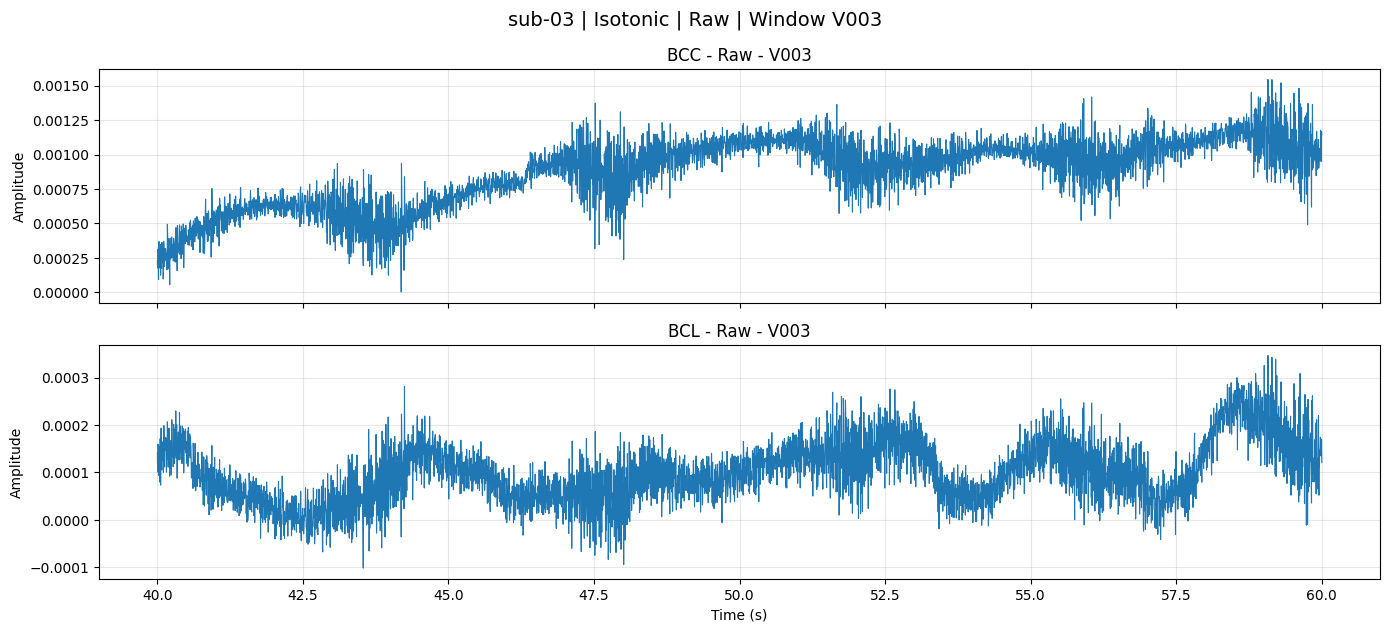

,Subject_ID,Condition,Channel,Window,Start_s,End_s,N_samples,Valid_samples,NaN_count,Mean,STD,Min,Max,RMS
0,sub-03,Isotonic,BCC,V003,40,60,40000,40000,0,0.000874,0.000245,-0.000083,0.001614,0.000907
1,sub-03,Isotonic,BCL,V003,40,60,40000,40000,0,0.000100,0.000064,-0.000141,0.000362,0.000118


In [62]:
graficar_ventana_emg(
    subject_id="sub-03",
    condition="Isotonic",
    numero_ventana=3
)

## 6. Signal conditioning

The sEMG conditioning pipeline includes:

1. Linear detrending.
2. 60 Hz notch filtering.
3. 20–450 Hz fourth-order Butterworth band-pass filtering.

Zero-phase forward–backward filtering is applied using `filtfilt` to avoid phase distortion.

In [6]:
def filtrar_emg(signal, fs=FS):
    """
    Apply the sEMG conditioning pipeline.

    Processing stages:
    1. Linear detrending.
    2. 60 Hz notch filtering.
    3. 20–450 Hz Butterworth band-pass filtering.

    Parameters
    ----------
    signal : array-like
        Raw sEMG signal.
    fs : int
        Sampling frequency in Hz.

    Returns
    -------
    np.ndarray
        Conditioned sEMG signal.
    """
    x = np.asarray(signal, dtype=float)

    if np.isnan(x).any():
        x = np.nan_to_num(x, nan=np.nanmedian(x))

    # 1. Linear detrending
    x = detrend(x)

    # 2. 60 Hz notch filter
    b_notch, a_notch = iirnotch(
        w0=NOTCH_FREQ,
        Q=NOTCH_Q,
        fs=fs
    )
    x = filtfilt(b_notch, a_notch, x)

    # 3. 20–450 Hz band-pass filter
    b_band, a_band = butter(
        BANDPASS_ORDER,
        [BANDPASS_LOW, BANDPASS_HIGH],
        btype="bandpass",
        fs=fs
    )
    x = filtfilt(b_band, a_band, x)

    return x

## 7. NeuroKit2-based envelope extraction

The conditioned sEMG signal is processed using NeuroKit2 to obtain the EMG amplitude envelope. The resulting envelope is then smoothed using a Savitzky–Golay filter with a 250 ms window and a third-order polynomial.

At a sampling frequency of 2 kHz, the 250 ms smoothing window corresponds to 500 samples. Since the Savitzky–Golay window length must be odd, the implementation automatically adjusts the value to the nearest valid odd number.

This reproduces the envelope extraction approach used for the inter-channel correlation analysis.

In [79]:
def extraer_envolvente_neurokit(signal_processed, fs=FS):
    """
    Extract a smoothed EMG envelope using NeuroKit2 and Savitzky-Golay filtering.

    Parameters
    ----------
    signal_processed : array-like
        Processed EMG signal.
    fs : int
        Sampling frequency.

    Returns
    -------
    np.ndarray
        Smoothed EMG envelope as a one-dimensional numeric array.
    """

    import numpy as np
    import neurokit2 as nk
    from scipy.signal import savgol_filter

    x = np.asarray(signal_processed, dtype=float)

    # Reemplazar NaN si existieran
    if np.isnan(x).any():
        x = np.nan_to_num(x, nan=np.nanmedian(x))

    # NeuroKit2 EMG processing
    signals, info = nk.emg_process(x, sampling_rate=fs)

    # Tomar únicamente la amplitud/envolvente
    envelope = signals["EMG_Amplitude"].to_numpy(dtype=float)

    # Ventana Savitzky-Golay de 250 ms
    window_length = int(0.25 * fs)

    # Debe ser impar
    if window_length % 2 == 0:
        window_length += 1

    # Evitar que la ventana sea más grande que la señal
    if window_length >= len(envelope):
        window_length = len(envelope) - 1

    if window_length % 2 == 0:
        window_length -= 1

    # Seguridad mínima
    if window_length < 5:
        return envelope

    envelope_smooth = savgol_filter(
        envelope,
        window_length=window_length,
        polyorder=3,
        mode="interp"
    )

    return np.asarray(envelope_smooth, dtype=float)

## 8. Helper functions for segment selection, plotting, and figure export

These helper functions are used to:

- Select a specific segment by subject, condition, and window.
- Preserve the real time axis of V002 and V003.
- Extract raw, processed, or envelope signals.
- Save figures in SVG, TIFF, and JPG formats.

In [8]:
def guardar_figura(fig, nombre_base):
    """
    Save a figure in SVG, TIFF, and JPG formats.
    """
    fig.savefig(RUTA_FIGURES / f"{nombre_base}.svg", bbox_inches="tight")
    fig.savefig(RUTA_FIGURES / f"{nombre_base}.tiff", dpi=600, bbox_inches="tight")
    fig.savefig(RUTA_FIGURES / f"{nombre_base}.jpg", dpi=600, bbox_inches="tight")


def obtener_segmento(segmentos_validos, subject_id, condition, window):
    """
    Retrieve one segment by subject, condition, and window.
    """
    for item in segmentos_validos:
        if (
            item["Subject_ID"] == subject_id and
            item["Condition"] == condition and
            item["Window"] == window
        ):
            return item

    raise ValueError(
        f"No segment found for {subject_id}, {condition}, V{window:03d}."
    )


def obtener_tiempo_segmento(item):
    """
    Generate a time vector preserving the original recording time.

    V002 = 20–40 s
    V003 = 40–60 s
    """
    start_s = item["Start_s"]
    n_samples = len(item["Data"])

    tiempo = start_s + np.arange(n_samples) / FS

    return tiempo


def obtener_senal(item, channel, processed=False):
    """
    Return raw or processed signal from a selected segment.
    """
    df = item["Data"]

    if channel not in df.columns:
        raise ValueError(
            f"Channel {channel} not found in {item['Original_File']}."
        )

    signal = df[channel].values

    if processed:
        signal = filtrar_emg(signal, fs=FS)

    return signal


def obtener_envolvente(item, channel):
    """
    Return NeuroKit2 + Savitzky–Golay smoothed envelope for one segment/channel.
    """
    processed_signal = obtener_senal(item, channel, processed=True)

    envelope_smooth, envelope_raw, signals, info = extraer_envolvente_neurokit(
        processed_signal,
        fs=FS
    )

    return envelope_smooth

## 9. Signal-quality metric calculation

The following signal-quality metrics are calculated for raw and processed recordings:

- Signal-to-noise ratio (SNR)
- Power-line interference ratio (PLI)
- Baseline drift ratio
- Root mean square (RMS)
- Median frequency (MDF)
- Spectral entropy
- Skewness
- Kurtosis

These metrics quantify signal clarity, residual electrical interference, baseline instability, amplitude behavior, spectral content, and distribution-related properties.

In [9]:
def calcular_metricas_emg(x, fs=FS):
    """
    Calculate sEMG signal-quality metrics.

    Parameters
    ----------
    x : array-like
        Input signal.
    fs : int
        Sampling frequency.

    Returns
    -------
    dict
        Dictionary containing signal-quality metrics.
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]

    if len(x) == 0:
        raise ValueError("Empty signal after NaN removal.")

    freqs, psd = welch(
        x,
        fs=fs,
        nperseg=WELCH_NPERSEG
    )

    total_power = np.trapezoid(psd, freqs)

    emg_band = (freqs >= BANDPASS_LOW) & (freqs <= BANDPASS_HIGH)
    emg_power = np.trapezoid(psd[emg_band], freqs[emg_band])

    noise_band = (freqs < BANDPASS_LOW) | (freqs > BANDPASS_HIGH)
    noise_power = np.trapezoid(psd[noise_band], frequs[noise_band]) if False else np.trapezoid(psd[noise_band], freqs[noise_band])

    snr = 10 * np.log10((emg_power + 1e-12) / (noise_power + 1e-12))

    pli_band = (freqs >= 58) & (freqs <= 62)
    pli_power = np.trapezoid(psd[pli_band], freqs[pli_band])
    pli_ratio = pli_power / (total_power + 1e-12)

    baseline_band = freqs < BANDPASS_LOW
    baseline_power = np.trapezoid(psd[baseline_band], freqs[baseline_band])
    baseline_ratio = baseline_power / (total_power + 1e-12)

    rms = np.sqrt(np.mean(x ** 2))

    cumulative_power = np.cumsum(psd)
    cumulative_power = cumulative_power / cumulative_power[-1]
    mdf = freqs[np.where(cumulative_power >= 0.5)[0][0]]

    psd_norm = psd / (np.sum(psd) + 1e-12)
    spectral_entropy = entropy(psd_norm)

    return {
        "SNR_dB": snr,
        "PLI_ratio": pli_ratio,
        "Baseline_ratio": baseline_ratio,
        "RMS": rms,
        "MDF_Hz": mdf,
        "Spectral_entropy": spectral_entropy,
        "Skewness": skew(x),
        "Kurtosis": kurtosis(x)
    }

## 10. Generate Raw vs Processed metric table

This section calculates all signal-quality metrics for each valid segment, channel, and processing stage.

The output is a long-format table suitable for paired statistical analysis.

In [10]:
def generar_tabla_metricas(segmentos_validos):
    """
    Generate a long-format table with Raw and Processed metrics.

    Pairing variables:
    - Subject
    - Condition
    - Channel
    - Window
    - Original file
    """
    resultados = []

    for item in segmentos_validos:

        for canal in CHANNELS:

            raw = obtener_senal(item, canal, processed=False)
            processed = obtener_senal(item, canal, processed=True)

            metricas_raw = calcular_metricas_emg(raw, fs=FS)
            metricas_processed = calcular_metricas_emg(processed, fs=FS)

            for stage, metricas in [
                ("Raw", metricas_raw),
                ("Processed", metricas_processed)
            ]:
                fila = {
                    "Subject": item["Subject"],
                    "Subject_ID": item["Subject_ID"],
                    "Condition": item["Condition"],
                    "Channel": canal,
                    "Stage": stage,
                    "Window": item["Window"],
                    "Start_s": item["Start_s"],
                    "End_s": item["End_s"],
                    "Original_File": item["Original_File"]
                }

                fila.update(metricas)
                resultados.append(fila)

    return pd.DataFrame(resultados)


df_metricas = generar_tabla_metricas(segmentos_validos)

display(df_metricas.head())

print("Subjects:", df_metricas["Subject_ID"].nunique())
print("Windows:", sorted(df_metricas["Window"].unique()))
print("Channels:", sorted(df_metricas["Channel"].unique()))
print("Stages:", sorted(df_metricas["Stage"].unique()))
print("Total rows:", len(df_metricas))

df_metricas.to_csv(
    RUTA_TABLES / "signal_quality_metrics_raw_vs_processed_V002_V003.csv",
    index=False
)

,Subject,Subject_ID,Condition,Channel,Stage,Window,Start_s,End_s,Original_File,SNR_dB,PLI_ratio,Baseline_ratio,RMS,MDF_Hz,Spectral_entropy,Skewness,Kurtosis
0,Subject 1,sub-01,Isometric,BCC,Raw,2,20,40,user1_isometrica.csv,-3.615776,0.161395,0.489754,0.000425,20.507812,3.391433,0.232305,-1.400050
1,Subject 1,sub-01,Isometric,BCC,Processed,2,20,40,user1_isometrica.csv,3.799154,0.011168,0.003439,0.000027,45.898438,4.395759,-0.029154,0.214732
2,Subject 1,sub-01,Isometric,BCL,Raw,2,20,40,user1_isometrica.csv,-6.485514,0.021292,0.735580,0.002471,1.953125,3.034916,0.392306,-0.486176
3,Subject 1,sub-01,Isometric,BCL,Processed,2,20,40,user1_isometrica.csv,4.006674,0.011437,0.003610,0.000010,70.312500,5.051994,0.388411,1.277917
4,Subject 1,sub-01,Isometric,BCC,Raw,3,40,60,user1_isometrica.csv,-6.850433,0.045622,0.771522,0.000733,0.976562,2.263166,0.867156,-0.742806


Subjects: 10
Windows: [np.int64(2), np.int64(3)]
Channels: ['BCC', 'BCL']
Stages: ['Processed', 'Raw']
Total rows: 160


## 11. Paired statistical analysis

Raw and processed metrics are compared using the Wilcoxon signed-rank test.

To reduce pseudoreplication, values are first averaged at the subject level before inferential testing. Effect size is reported using rank-biserial correlation.

Positive rank-biserial values indicate that the processed values are higher than the raw values. Negative values indicate that the processed values are lower than the raw values.

In [11]:
def rank_biserial_effect(raw, processed):
    """
    Calculate rank-biserial correlation for paired Wilcoxon comparisons.

    Positive value:
        Processed > Raw

    Negative value:
        Processed < Raw
    """
    raw = np.asarray(raw, dtype=float)
    processed = np.asarray(processed, dtype=float)

    diff = processed - raw
    diff = diff[diff != 0]

    if len(diff) == 0:
        return np.nan

    ranks = rankdata(np.abs(diff))

    w_pos = np.sum(ranks[diff > 0])
    w_neg = np.sum(ranks[diff < 0])

    return (w_pos - w_neg) / (w_pos + w_neg)


def interpretar_efecto_rank_biserial(r):
    """
    Approximate interpretation of rank-biserial effect size.
    """
    if pd.isna(r):
        return "Not available"

    abs_r = abs(r)

    if abs_r < 0.10:
        return "Negligible"
    elif abs_r < 0.30:
        return "Small"
    elif abs_r < 0.50:
        return "Moderate"
    else:
        return "Large"


def analizar_estadistica_pareada(df_metricas):
    """
    Compare Raw vs Processed metrics using Wilcoxon signed-rank test.

    Values are averaged at participant level before statistical testing
    to reduce pseudoreplication.
    """
    metricas = [
        "SNR_dB",
        "PLI_ratio",
        "Baseline_ratio",
        "RMS",
        "MDF_Hz",
        "Spectral_entropy",
        "Skewness",
        "Kurtosis"
    ]

    id_cols = [
        "Subject_ID",
        "Subject",
        "Condition",
        "Channel",
        "Window",
        "Original_File"
    ]

    resultados = []

    for metrica in metricas:

        tabla = df_metricas.pivot_table(
            index=id_cols,
            columns="Stage",
            values=metrica,
            aggfunc="mean"
        ).reset_index()

        tabla = tabla.dropna(subset=["Raw", "Processed"])

        por_sujeto = tabla.groupby("Subject_ID")[["Raw", "Processed"]].mean()

        raw = por_sujeto["Raw"].values
        processed = por_sujeto["Processed"].values
        diff = processed - raw

        n = len(por_sujeto)

        if n >= 3:
            _, shapiro_p = shapiro(diff)
        else:
            shapiro_p = np.nan

        try:
            w_stat, p_value = wilcoxon(
                processed,
                raw,
                zero_method="wilcox",
                alternative="two-sided"
            )
        except ValueError:
            w_stat, p_value = np.nan, np.nan

        effect_size = rank_biserial_effect(raw, processed)
        mean_diff = np.mean(diff)

        if mean_diff > 0:
            direction = "Processed > Raw"
        elif mean_diff < 0:
            direction = "Processed < Raw"
        else:
            direction = "No change"

        resultados.append({
            "Metric": metrica,
            "N_subjects": n,
            "Raw Mean": np.mean(raw),
            "Raw SD": np.std(raw, ddof=1),
            "Processed Mean": np.mean(processed),
            "Processed SD": np.std(processed, ddof=1),
            "Raw Median": np.median(raw),
            "Processed Median": np.median(processed),
            "Mean Difference": mean_diff,
            "Shapiro p": shapiro_p,
            "Statistical test": "Wilcoxon signed-rank",
            "Wilcoxon W": w_stat,
            "p-value": p_value,
            "Effect size": effect_size,
            "Effect size type": "Rank-biserial correlation",
            "Effect magnitude": interpretar_efecto_rank_biserial(effect_size),
            "Direction": direction
        })

    return pd.DataFrame(resultados)


tabla_estadistica = analizar_estadistica_pareada(df_metricas)

display(tabla_estadistica)

tabla_estadistica.to_csv(
    RUTA_TABLES / "paired_statistical_analysis_raw_vs_processed_V002_V003.csv",
    index=False
)

,Metric,N_subjects,Raw Mean,Raw SD,Processed Mean,Processed SD,Raw Median,Processed Median,Mean Difference,Shapiro p,Statistical test,Wilcoxon W,p-value,Effect size,Effect size type,Effect magnitude,Direction
0,SNR_dB,10,-3.999034,1.899108,3.122472,1.550350,-4.874042,2.651824,7.121506,0.024106,Wilcoxon signed-rank,0.0,0.001953,1.000000,Rank-biserial correlation,Large,Processed > Raw
1,PLI_ratio,10,0.099139,0.090335,0.009567,0.001537,0.047502,0.009724,-0.089572,0.011714,Wilcoxon signed-rank,0.0,0.001953,-1.000000,Rank-biserial correlation,Large,Processed < Raw
2,Baseline_ratio,10,0.341961,0.111400,0.004581,0.001947,0.354877,0.004365,-0.337379,0.278304,Wilcoxon signed-rank,0.0,0.001953,-1.000000,Rank-biserial correlation,Large,Processed < Raw
3,RMS,10,0.001737,0.000900,0.000054,0.000017,0.001462,0.000047,-0.001683,0.377213,Wilcoxon signed-rank,0.0,0.001953,-1.000000,Rank-biserial correlation,Large,Processed < Raw
4,MDF_Hz,10,36.413574,13.748084,54.711914,9.957160,32.592773,52.734375,18.298340,0.547229,Wilcoxon signed-rank,1.0,0.003906,0.963636,Rank-biserial correlation,Large,Processed > Raw
5,Spectral_entropy,10,4.022978,0.442649,4.638164,0.210995,4.171462,4.597364,0.615186,0.333755,Wilcoxon signed-rank,0.0,0.001953,1.000000,Rank-biserial correlation,Large,Processed > Raw
6,Skewness,10,-0.027275,0.195934,-0.075846,0.111179,-0.093948,-0.097049,-0.048572,0.527499,Wilcoxon signed-rank,22.0,0.625000,-0.200000,Rank-biserial correlation,Small,Processed < Raw
7,Kurtosis,10,0.062696,0.349888,2.152913,0.584624,0.049080,2.085577,2.090217,0.450960,Wilcoxon signed-rank,0.0,0.001953,1.000000,Rank-biserial correlation,Large,Processed > Raw


## 12. Format Table 2 for the manuscript

This section formats the statistical results into a compact table that can be used directly in the manuscript.

In [12]:
def formatear_tabla_para_paper(tabla_estadistica):
    """
    Format statistical results for manuscript Table 2.
    """
    filas = []

    for _, row in tabla_estadistica.iterrows():

        filas.append({
            "Metric": row["Metric"],
            "Raw Mean ± SD": f'{row["Raw Mean"]:.4g} ± {row["Raw SD"]:.4g}',
            "Processed Mean ± SD": f'{row["Processed Mean"]:.4g} ± {row["Processed SD"]:.4g}',
            "Median Raw / Processed": f'{row["Raw Median"]:.4g} / {row["Processed Median"]:.4g}',
            "Statistical test": row["Statistical test"],
            "p-value": f'{row["p-value"]:.4f}',
            "Effect size": f'{row["Effect size"]:.3f}',
            "Effect magnitude": row["Effect magnitude"],
            "Direction": row["Direction"]
        })

    return pd.DataFrame(filas)


tabla_2_paper = formatear_tabla_para_paper(tabla_estadistica)

display(tabla_2_paper)

tabla_2_paper.to_csv(
    RUTA_TABLES / "table_2_for_manuscript.csv",
    index=False
)

,Metric,Raw Mean ± SD,Processed Mean ± SD,Median Raw / Processed,Statistical test,p-value,Effect size,Effect magnitude,Direction
0,SNR_dB,-3.999 ± 1.899,3.122 ± 1.55,-4.874 / 2.652,Wilcoxon signed-rank,0.0020,1.000,Large,Processed > Raw
1,PLI_ratio,0.09914 ± 0.09033,0.009567 ± 0.001537,0.0475 / 0.009724,Wilcoxon signed-rank,0.0020,-1.000,Large,Processed < Raw
2,Baseline_ratio,0.342 ± 0.1114,0.004581 ± 0.001947,0.3549 / 0.004365,Wilcoxon signed-rank,0.0020,-1.000,Large,Processed < Raw
3,RMS,0.001737 ± 0.0009003,5.399e-05 ± 1.702e-05,0.001462 / 4.739e-05,Wilcoxon signed-rank,0.0020,-1.000,Large,Processed < Raw
4,MDF_Hz,36.41 ± 13.75,54.71 ± 9.957,32.59 / 52.73,Wilcoxon signed-rank,0.0039,0.964,Large,Processed > Raw
5,Spectral_entropy,4.023 ± 0.4426,4.638 ± 0.211,4.171 / 4.597,Wilcoxon signed-rank,0.0020,1.000,Large,Processed > Raw
6,Skewness,-0.02727 ± 0.1959,-0.07585 ± 0.1112,-0.09395 / -0.09705,Wilcoxon signed-rank,0.6250,-0.200,Small,Processed < Raw
7,Kurtosis,0.0627 ± 0.3499,2.153 ± 0.5846,0.04908 / 2.086,Wilcoxon signed-rank,0.0020,1.000,Large,Processed > Raw


## 13. Generate NeuroKit2 envelope records

This section generates smoothed BCC and BCL envelopes for each valid segment.

The envelopes are obtained from the conditioned sEMG signals using NeuroKit2 and then smoothed using Savitzky–Golay filtering.

In [71]:
def generar_registros_envolventes(segmentos_validos):
    """
    Generate smoothed BCC and BCL envelopes for each valid segment.
    """
    registros = []

    for item in segmentos_validos:

        bcc_env = obtener_envolvente(item, "BCC")
        bcl_env = obtener_envolvente(item, "BCL")

        registros.append({
            "Subject": item["Subject"],
            "Subject_ID": item["Subject_ID"],
            "Condition": item["Condition"],
            "Window": item["Window"],
            "Start_s": item["Start_s"],
            "End_s": item["End_s"],
            "Original_File": item["Original_File"],
            "BCC_Envelope": bcc_env,
            "BCL_Envelope": bcl_env
        })

    return registros


registros_envolventes = generar_registros_envolventes(segmentos_validos)

print("Envelope records:", len(registros_envolventes))

Envelope records: 40


## 14. Inter-channel Spearman correlation

Spearman correlation is calculated between the smoothed BCC and BCL envelopes for each subject, condition, and valid window.

The correlation analysis uses temporally aligned samples from the same acquisition window.

In [72]:
def calcular_correlacion_bcc_bcl(registros_envolventes):
    """
    Calculate Spearman correlation between BCC and BCL smoothed envelopes.
    """
    resultados = []

    for item in registros_envolventes:

        bcc_env = item["BCC_Envelope"]
        bcl_env = item["BCL_Envelope"]

        rho, p_value = spearmanr(bcc_env, bcl_env)

        resultados.append({
            "Subject": item["Subject"],
            "Subject_ID": item["Subject_ID"],
            "Condition": item["Condition"],
            "Window": item["Window"],
            "Start_s": item["Start_s"],
            "End_s": item["End_s"],
            "Original_File": item["Original_File"],
            "Spearman_rho": rho,
            "p-value": p_value
        })

    return pd.DataFrame(resultados)


df_correlacion = calcular_correlacion_bcc_bcl(registros_envolventes)

display(df_correlacion.head())

df_correlacion.to_csv(
    RUTA_TABLES / "bcc_bcl_spearman_correlation_V002_V003.csv",
    index=False
)

,Subject,Subject_ID,Condition,Window,Start_s,End_s,Original_File,Spearman_rho,p-value
0,Subject 1,sub-01,Isometric,2,20,40,user1_isometrica.csv,0.232472,0.0
1,Subject 1,sub-01,Isometric,3,40,60,user1_isometrica.csv,0.415872,0.0
2,Subject 1,sub-01,Isotonic,2,20,40,user1_isotonica.csv,0.820307,0.0
3,Subject 1,sub-01,Isotonic,3,40,60,user1_isotonica.csv,0.759131,0.0
4,Subject 2,sub-02,Isometric,2,20,40,user2_isometrica.csv,0.599427,0.0


## 15. Figure generation helper

The following function generates 10-subject grids for raw signals, processed signals, or smoothed envelopes.

The x-axis preserves the original time interval:

- V002 is displayed from 20 to 40 s.
- V003 is displayed from 40 to 60 s.

In [73]:
def convertir_canal_a_numerico(serie):
    """
    Convierte una columna EMG a valores numéricos.
    Corrige comas decimales, espacios y valores no numéricos.
    """
    import pandas as pd

    return pd.to_numeric(
        serie.astype(str)
             .str.replace(",", ".", regex=False)
             .str.strip(),
        errors="coerce"
    ).to_numpy(dtype=float)

In [74]:
def graficar_grid_senales(
    segmentos_validos,
    channel="BCC",
    stage="Raw",
    window=3,
    max_points=3000,
    save=False
):
    """
    Grafica señales sEMG por sujeto y condición usando downsampling solo para visualización.
    Esta versión convierte BCC/BCL a numérico antes de graficar.
    """

    import numpy as np
    import matplotlib.pyplot as plt

    plt.close("all")

    channel = channel.upper()
    stage = stage.lower()

    segmentos_plot = [
        item for item in segmentos_validos
        if item.get("Window") == window
    ]

    if len(segmentos_plot) == 0:
        print(f"No se encontraron segmentos para window={window}")
        return

    segmentos_plot = sorted(
        segmentos_plot,
        key=lambda x: (x.get("Subject_Number", 0), x.get("Condition", ""))
    )

    n = len(segmentos_plot)
    ncols = 2
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(14, 2.4 * nrows),
        sharex=False
    )

    axes = np.array(axes).reshape(-1)

    print(f"Graficando {n} segmentos | Canal: {channel} | Etapa: {stage} | Ventana: V00{window}")

    for ax, item in zip(axes, segmentos_plot):

        subject = item.get("Subject_ID", "Unknown")
        condition = item.get("Condition", "Unknown")
        df = item["Data"]

        if channel not in df.columns:
            print(f"El canal {channel} no existe en {subject} - {condition}")
            print("Columnas disponibles:", df.columns.tolist())
            ax.axis("off")
            continue

        # Conversión correcta a número
        y_raw = convertir_canal_a_numerico(df[channel])

        if stage == "raw":
            y = y_raw

        elif stage == "processed":
            y = filtrar_emg(y_raw, fs=FS)

        elif stage == "envelope":
            y_processed = filtrar_emg(y_raw, fs=FS)
            y = extraer_envolvente_neurokit(y_processed, fs=FS)

        else:
            raise ValueError("stage debe ser: Raw, Processed o Envelope")

        y = np.asarray(y, dtype=float)

        # Si hay demasiados NaN, marcar la ventana
        nan_count = np.isnan(y).sum()
        valid_count = np.sum(~np.isnan(y))

        if valid_count == 0:
            ax.set_title(f"{subject} - {condition} | SIN DATOS NUMÉRICOS", fontsize=9)
            ax.axis("off")
            continue

        start_s = item["Start_s"]
        end_s = item["End_s"]

        # endpoint=False evita repetir exactamente el límite final
        t = np.linspace(start_s, end_s, len(y), endpoint=False)

        # Downsampling solo para visualización
        if len(y) > max_points:
            idx = np.linspace(0, len(y) - 1, max_points).astype(int)
            t_plot = t[idx]
            y_plot = y[idx]
        else:
            t_plot = t
            y_plot = y

        ax.plot(t_plot, y_plot, linewidth=0.7)
        ax.set_title(
            f"{subject} - {condition} | NaN={nan_count}",
            fontsize=9
        )
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Amplitude")
        ax.grid(True, alpha=0.3)

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(
        f"{stage.capitalize()} sEMG signals - {channel} - Window V00{window}",
        fontsize=14
    )

    plt.tight_layout()

    if save:
        nombre = f"grid_{stage}_{channel}_V00{window}.png"
        plt.savefig(nombre, dpi=200, bbox_inches="tight")
        print(f"Figura guardada como: {nombre}")

    plt.show()
    plt.close(fig)

In [75]:
def graficar_grid_senales(
    segmentos_validos,
    channel="BCC",
    stage="Raw",
    window=3,
    max_points=3000,
    save=False
):
    """
    Grafica señales sEMG por sujeto y condición usando downsampling solo para visualización.
    Esta versión convierte BCC/BCL a numérico antes de graficar.
    """

    import numpy as np
    import matplotlib.pyplot as plt

    plt.close("all")

    channel = channel.upper()
    stage = stage.lower()

    segmentos_plot = [
        item for item in segmentos_validos
        if item.get("Window") == window
    ]

    if len(segmentos_plot) == 0:
        print(f"No se encontraron segmentos para window={window}")
        return

    segmentos_plot = sorted(
        segmentos_plot,
        key=lambda x: (x.get("Subject_Number", 0), x.get("Condition", ""))
    )

    n = len(segmentos_plot)
    ncols = 2
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(14, 2.4 * nrows),
        sharex=False
    )

    axes = np.array(axes).reshape(-1)

    print(f"Graficando {n} segmentos | Canal: {channel} | Etapa: {stage} | Ventana: V00{window}")

    for ax, item in zip(axes, segmentos_plot):

        subject = item.get("Subject_ID", "Unknown")
        condition = item.get("Condition", "Unknown")
        df = item["Data"]

        if channel not in df.columns:
            print(f"El canal {channel} no existe en {subject} - {condition}")
            print("Columnas disponibles:", df.columns.tolist())
            ax.axis("off")
            continue

        # Conversión correcta a número
        y_raw = convertir_canal_a_numerico(df[channel])

        if stage == "raw":
            y = y_raw

        elif stage == "processed":
            y = filtrar_emg(y_raw, fs=FS)

        elif stage == "envelope":
            y_processed = filtrar_emg(y_raw, fs=FS)
            y = extraer_envolvente_neurokit(y_processed, fs=FS)

        else:
            raise ValueError("stage debe ser: Raw, Processed o Envelope")

        y = np.asarray(y, dtype=float)

        # Si hay demasiados NaN, marcar la ventana
        nan_count = np.isnan(y).sum()
        valid_count = np.sum(~np.isnan(y))

        if valid_count == 0:
            ax.set_title(f"{subject} - {condition} | SIN DATOS NUMÉRICOS", fontsize=9)
            ax.axis("off")
            continue

        start_s = item["Start_s"]
        end_s = item["End_s"]

        # endpoint=False evita repetir exactamente el límite final
        t = np.linspace(start_s, end_s, len(y), endpoint=False)

        # Downsampling solo para visualización
        if len(y) > max_points:
            idx = np.linspace(0, len(y) - 1, max_points).astype(int)
            t_plot = t[idx]
            y_plot = y[idx]
        else:
            t_plot = t
            y_plot = y

        ax.plot(t_plot, y_plot, linewidth=0.7)
        ax.set_title(
            f"{subject} - {condition} | NaN={nan_count}",
            fontsize=9
        )
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Amplitude")
        ax.grid(True, alpha=0.3)

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(
        f"{stage.capitalize()} sEMG signals - {channel} - Window V00{window}",
        fontsize=14
    )

    plt.tight_layout()

    if save:
        nombre = f"grid_{stage}_{channel}_V00{window}.png"
        plt.savefig(nombre, dpi=200, bbox_inches="tight")
        print(f"Figura guardada como: {nombre}")

    plt.show()
    plt.close(fig)

Graficando 20 segmentos | Canal: BCL | Etapa: raw | Ventana: V003


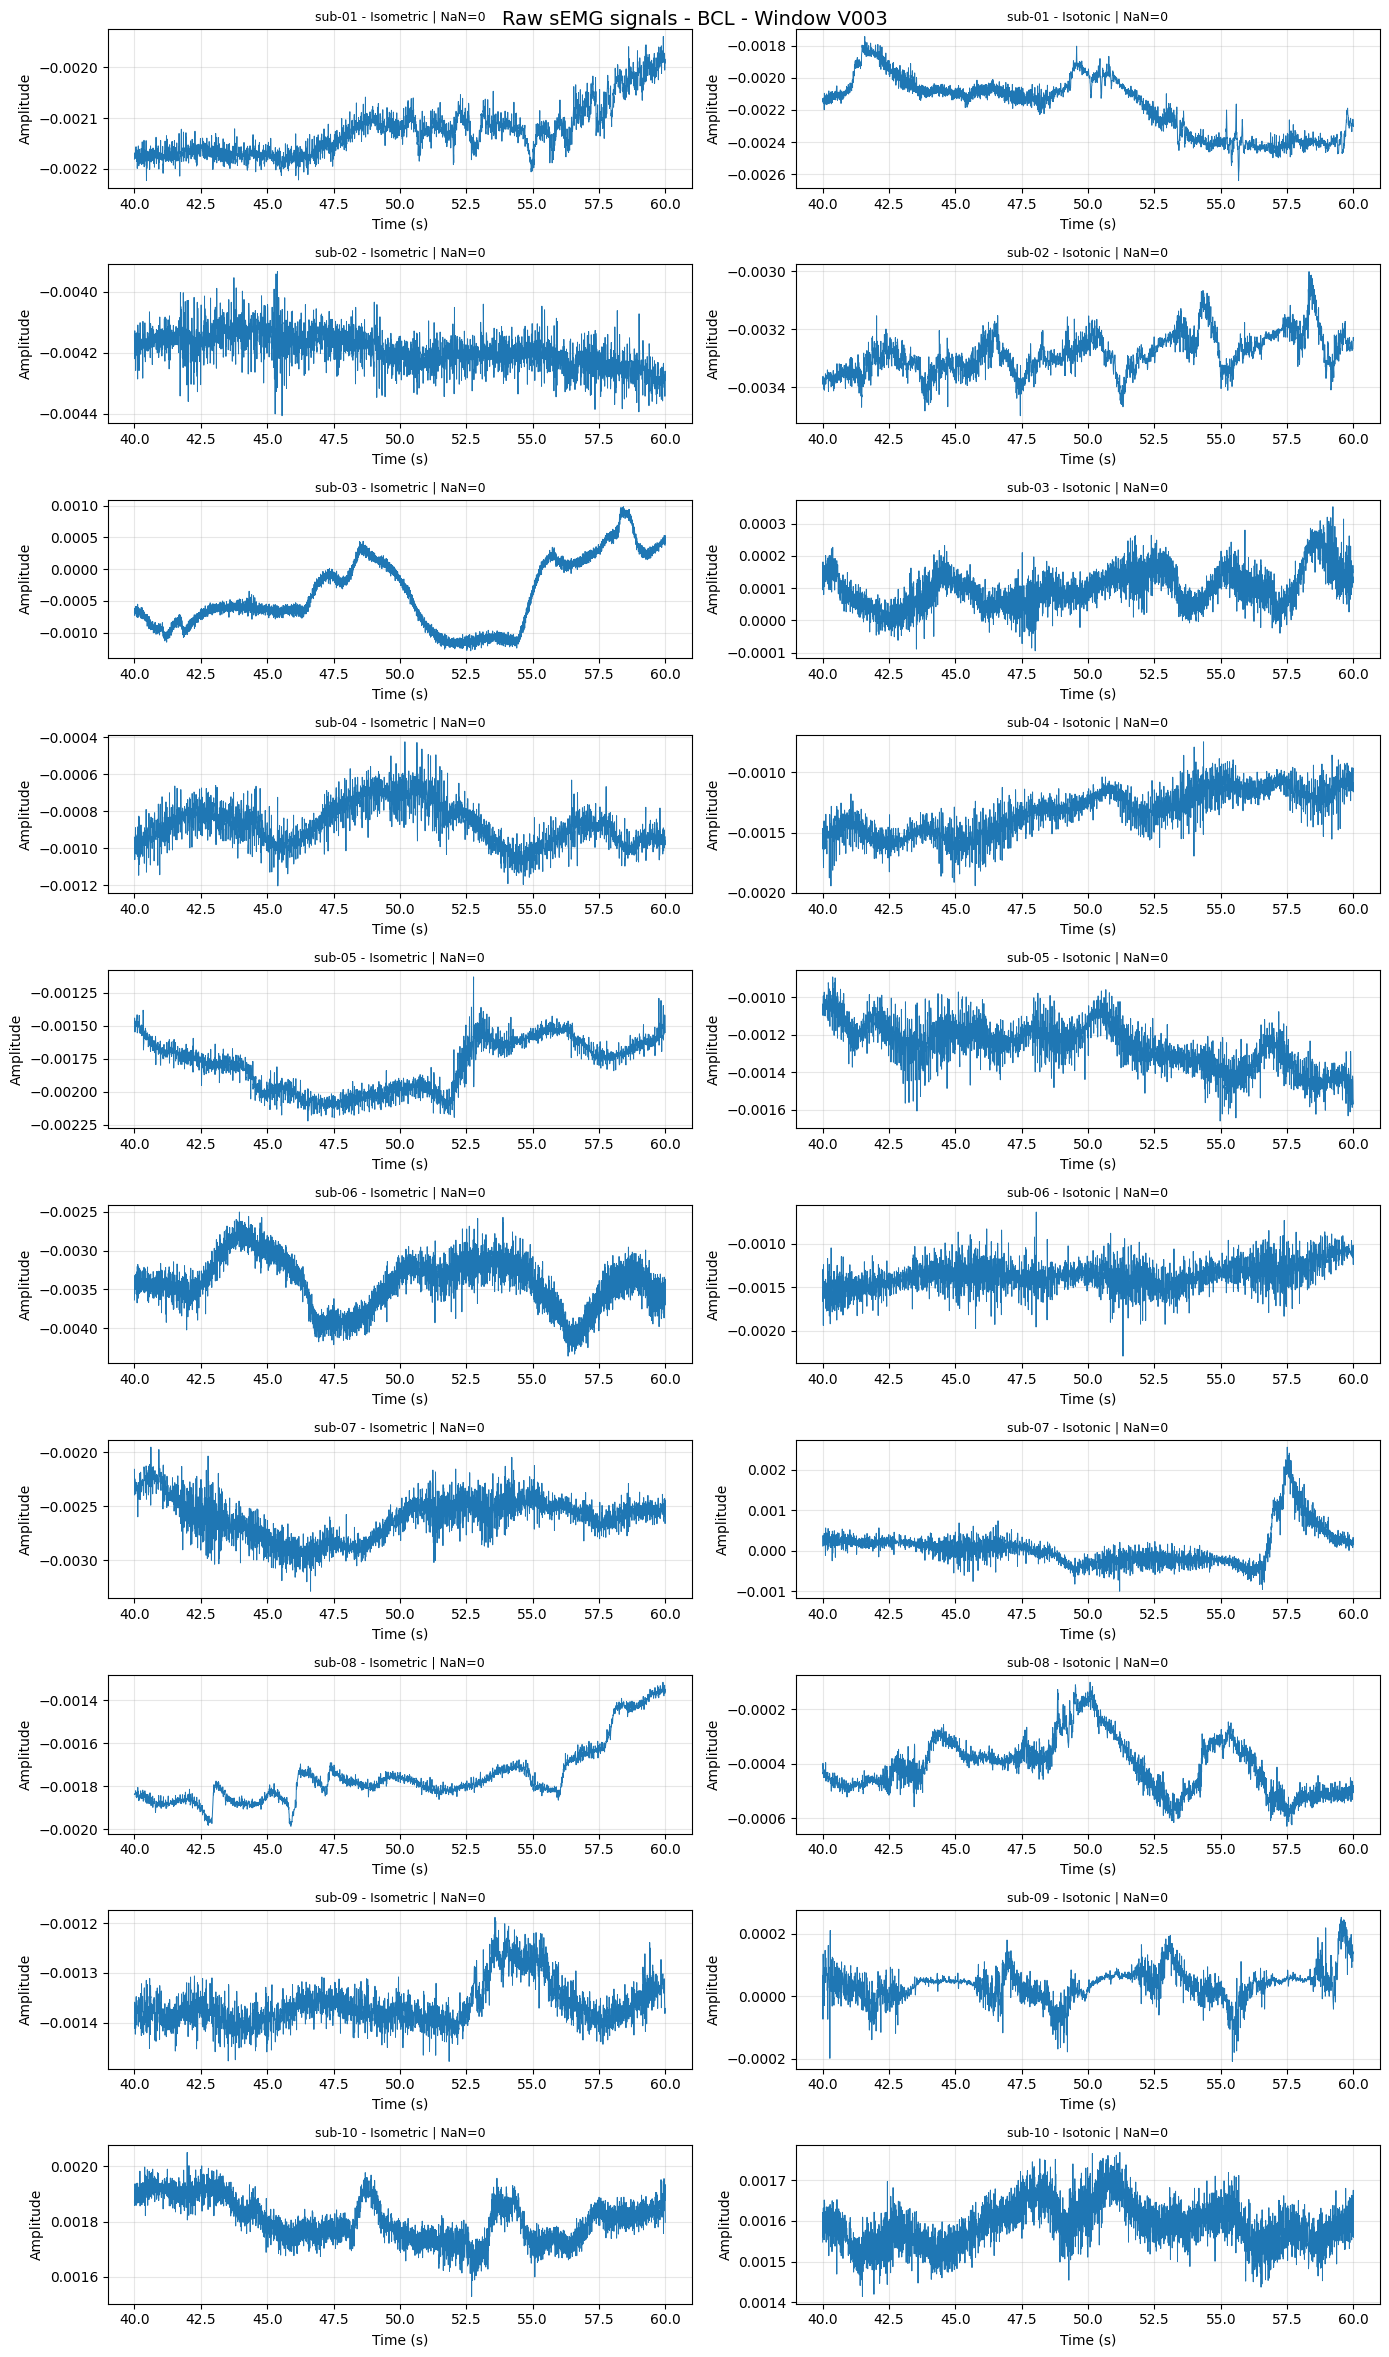

In [76]:
graficar_grid_senales(
    segmentos_validos,
    channel="BCL",
    stage="Raw",
    window=3,
    max_points=3000,
    save=False
)

## 16. Figure 6: Representative raw sEMG recordings

This section generates representative raw sEMG recordings for BCC and BCL using V002, corresponding to the 20–40 s interval.

## 17. Figure 7: Representative conditioned sEMG recordings

This section generates a 2 × 2 representative figure with conditioned sEMG signals.

Panels:

- (a) BCC during isometric contraction.
- (b) BCC during isotonic contraction.
- (c) BCL during isometric contraction.
- (d) BCL during isotonic contraction.

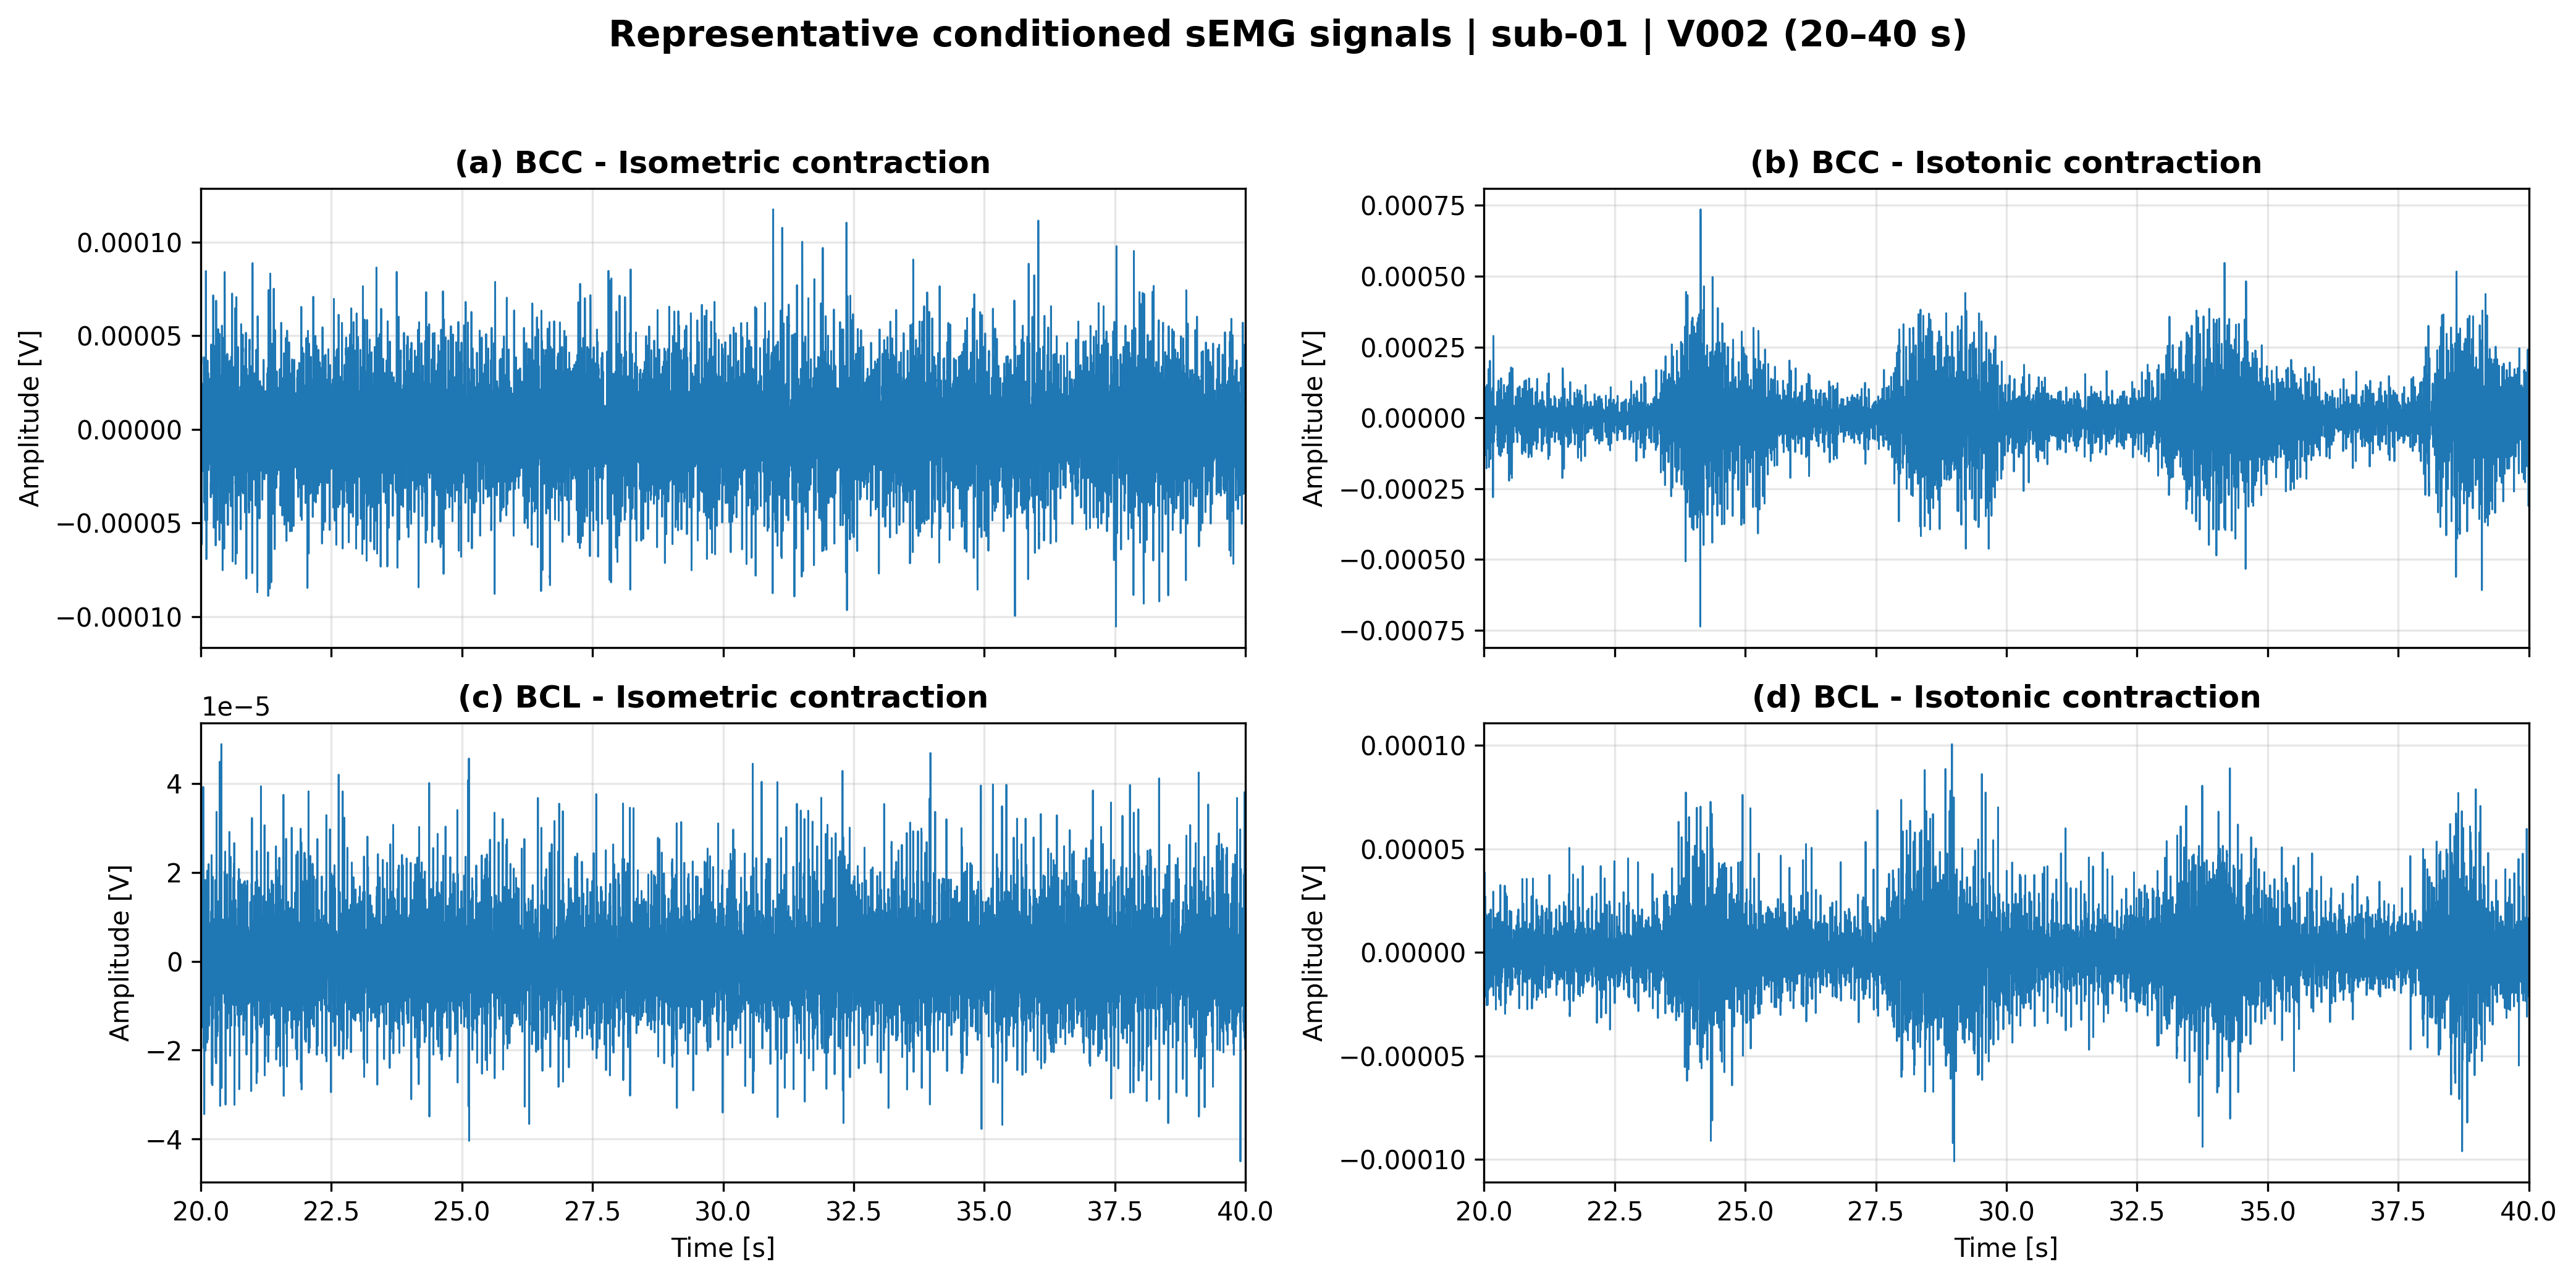

In [77]:
def graficar_figura7_senales_procesadas(
    segmentos_validos,
    subject_id="sub-01",
    window=2
):
    """
    Generate a 2x2 representative processed sEMG figure.

    Panels:
    (a) BCC Isometric
    (b) BCC Isotonic
    (c) BCL Isometric
    (d) BCL Isotonic
    """
    if window not in VALID_WINDOWS:
        raise ValueError(f"Window V{window:03d} is not valid. Use {VALID_WINDOWS}.")

    fig, axs = plt.subplots(
        2,
        2,
        figsize=(14, 7),
        dpi=300,
        sharex=True
    )

    paneles = [
        ("BCC", "Isometric", "(a) BCC - Isometric contraction", axs[0, 0]),
        ("BCC", "Isotonic", "(b) BCC - Isotonic contraction", axs[0, 1]),
        ("BCL", "Isometric", "(c) BCL - Isometric contraction", axs[1, 0]),
        ("BCL", "Isotonic", "(d) BCL - Isotonic contraction", axs[1, 1]),
    ]

    for channel, condition, title, ax in paneles:

        item = obtener_segmento(
            segmentos_validos,
            subject_id=subject_id,
            condition=condition,
            window=window
        )

        tiempo = obtener_tiempo_segmento(item)
        signal = obtener_senal(item, channel, processed=True)

        ax.plot(tiempo, signal, linewidth=0.7)
        ax.set_title(title, fontweight="bold")
        ax.set_ylabel("Amplitude [V]")
        ax.set_xlim(item["Start_s"], item["End_s"])
        ax.grid(True, alpha=0.3)

        if ax in [axs[1, 0], axs[1, 1]]:
            ax.set_xlabel("Time [s]")

    fig.suptitle(
        f"Representative conditioned sEMG signals | {subject_id} | "
        f"V{window:03d} ({(window - 1) * WINDOW_DURATION_S}–{window * WINDOW_DURATION_S} s)",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    nombre_base = f"figure7_conditioned_sEMG_{subject_id}_V{window:03d}"

    guardar_figura(fig, nombre_base)

    plt.show()


graficar_figura7_senales_procesadas(
    segmentos_validos,
    subject_id="sub-01",
    window=2
)

## 18. Figure 8: NeuroKit2 + Savitzky–Golay smoothed envelopes

This section generates smoothed envelope representations for BCC and BCL.

The envelopes are obtained using NeuroKit2 `emg_process()` and the `EMG_Amplitude` output. They are then smoothed using a Savitzky–Golay filter with a 250 ms window and third-order polynomial.

In [80]:
item = segmentos_validos[0]
df = item["Data"]

y_raw = convertir_canal_a_numerico(df["BCC"])
y_processed = filtrar_emg(y_raw, fs=FS)

resultado = extraer_envolvente_neurokit(y_processed, fs=FS)

print(type(resultado))

try:
    print("Longitud:", len(resultado))
except:
    print("No tiene len")

print(resultado)

C:\Users\david\anaconda3\Lib\site-packages\neurokit2\events\events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(


<class 'numpy.ndarray'>
Longitud: 40000
[5.95227762e-12 6.12256524e-12 6.29150231e-12 ... 1.41420769e-11
 1.42224946e-11 1.43035915e-11]


Graficando 20 segmentos | Canal: BCC | Etapa: envelope | Ventana: V002


C:\Users\david\anaconda3\Lib\site-packages\neurokit2\events\events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(
C:\Users\david\anaconda3\Lib\site-packages\neurokit2\events\events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(
C:\Users\david\anaconda3\Lib\site-packages\neurokit2\events\events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(


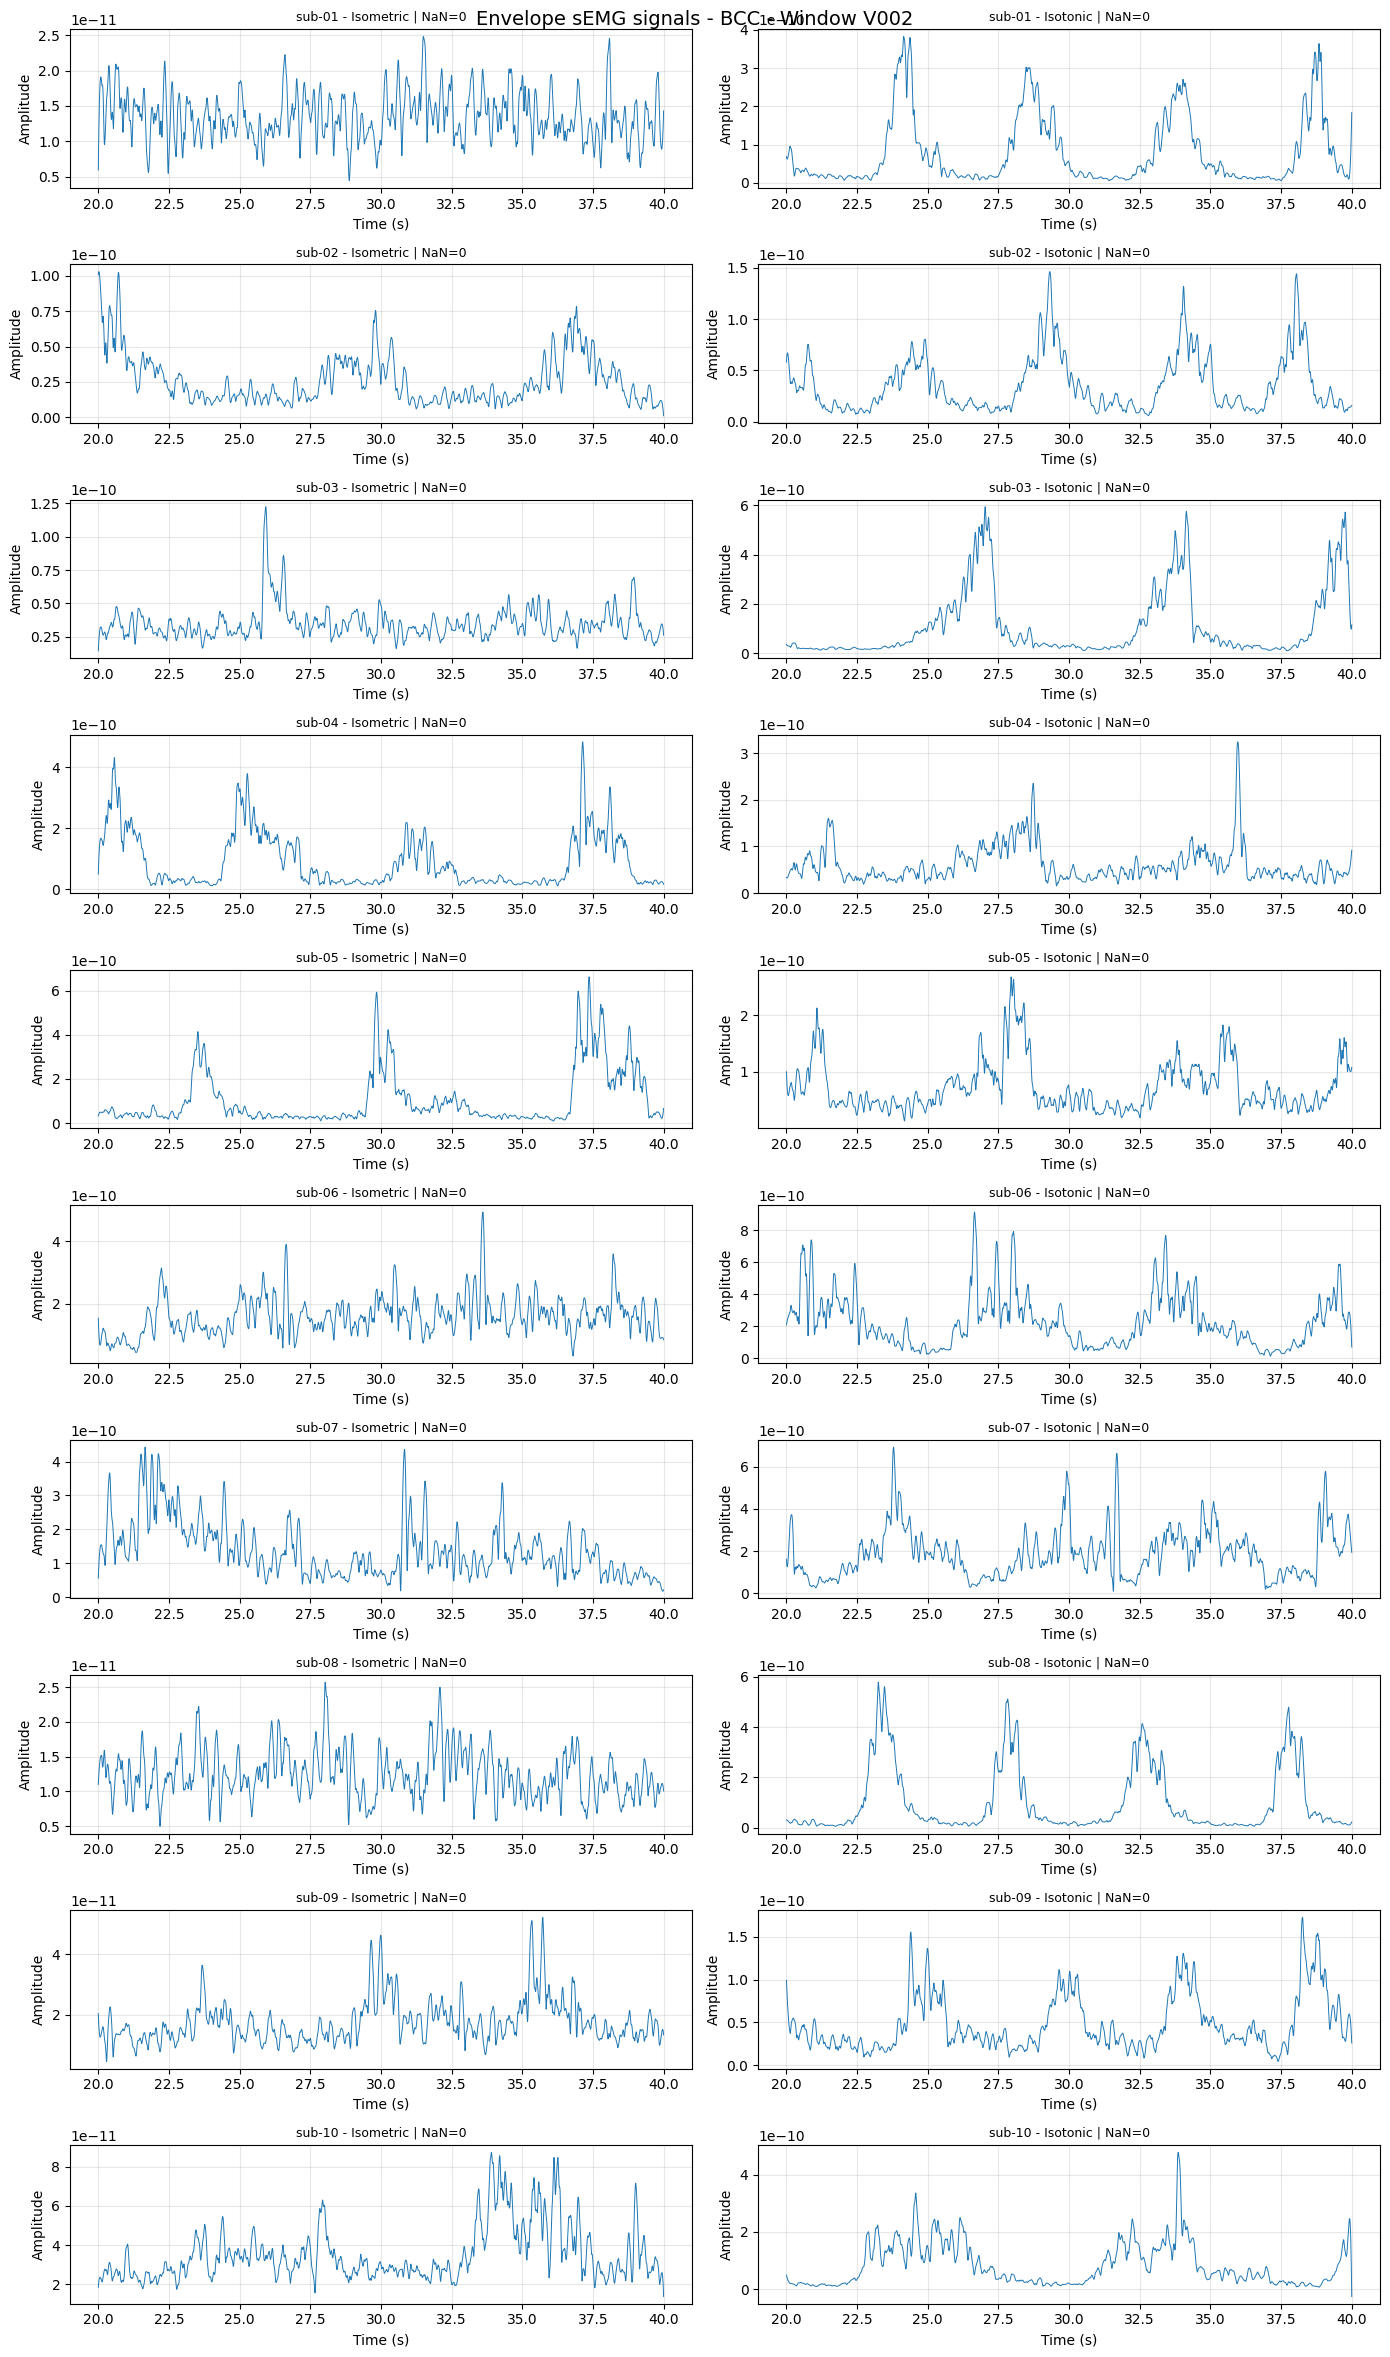

Graficando 20 segmentos | Canal: BCL | Etapa: envelope | Ventana: V002


C:\Users\david\anaconda3\Lib\site-packages\neurokit2\events\events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(
C:\Users\david\anaconda3\Lib\site-packages\neurokit2\events\events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(
C:\Users\david\anaconda3\Lib\site-packages\neurokit2\events\events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(


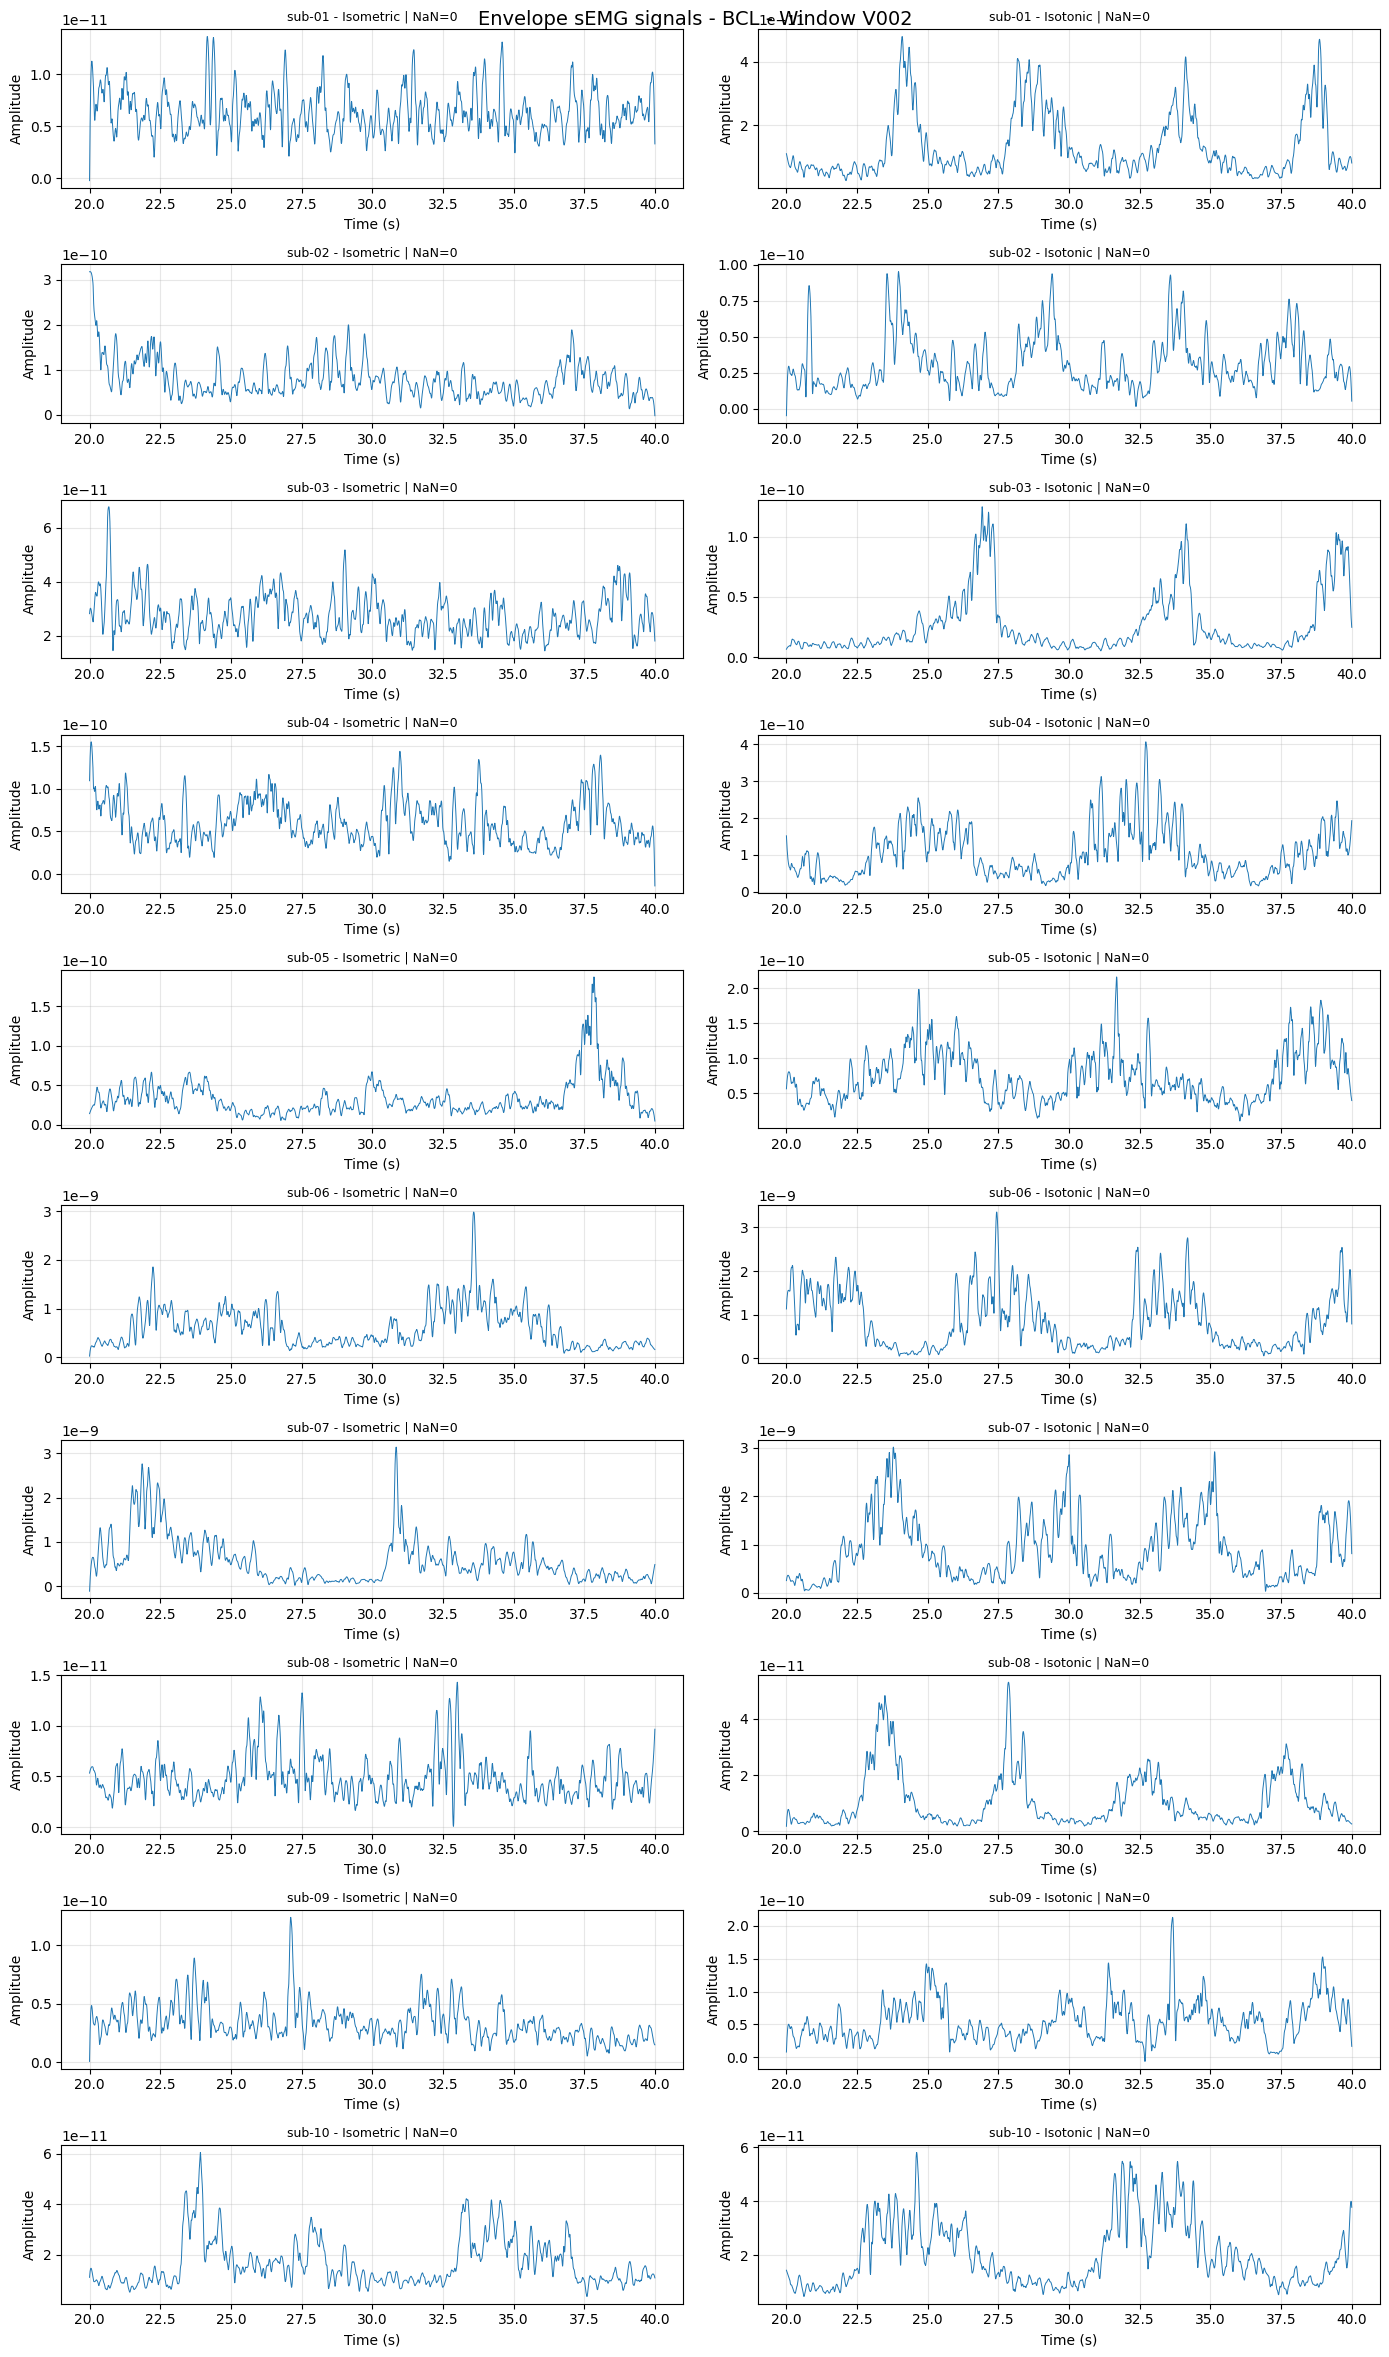

In [81]:
graficar_grid_senales(
    segmentos_validos,
    channel="BCC",
    stage="Envelope",
    window=2
)

graficar_grid_senales(
    segmentos_validos,
    channel="BCL",
    stage="Envelope",
    window=2
)

## 19. Figure 9: Spearman correlation matrices

The correlation matrices are generated using the smoothed envelopes from:

- BCC_V002
- BCL_V002
- BCC_V003
- BCL_V003

This allows the comparison of inter-channel relationships across valid windows.

In [83]:
from scipy.stats import spearmanr
import numpy as np
import matplotlib.pyplot as plt

In [84]:
def obtener_segmento_corregido(segmentos_validos, subject_id, condition, window):
    """
    Obtiene un segmento específico por sujeto, condición y ventana.
    """
    subject_id = str(subject_id).lower().strip()
    condition = str(condition).lower().strip()

    for item in segmentos_validos:
        if (
            str(item["Subject_ID"]).lower().strip() == subject_id and
            str(item["Condition"]).lower().strip() == condition and
            int(item["Window"]) == int(window)
        ):
            return item

    disponibles = [
        (item["Subject_ID"], item["Condition"], item["Window"])
        for item in segmentos_validos
    ]

    raise ValueError(
        f"No se encontró segmento para {subject_id}, {condition}, V00{window}. "
        f"Ejemplos disponibles: {disponibles[:10]}"
    )

In [85]:
def obtener_envolvente_corregida(item, channel):
    """
    Obtiene la envolvente suavizada desde item['Data'] usando el canal solicitado.
    """

    channel = channel.upper()
    df = item["Data"]

    if channel not in df.columns:
        raise ValueError(
            f"El canal {channel} no existe. Columnas disponibles: {df.columns.tolist()}"
        )

    y_raw = convertir_canal_a_numerico(df[channel])

    if np.all(np.isnan(y_raw)):
        raise ValueError(f"El canal {channel} no contiene datos numéricos válidos.")

    y_raw = np.nan_to_num(y_raw, nan=np.nanmedian(y_raw))

    y_processed = filtrar_emg(y_raw, fs=FS)

    envelope = extraer_envolvente_neurokit(y_processed, fs=FS)

    envelope = np.asarray(envelope, dtype=float)

    return envelope

In [86]:
def construir_matriz_correlacion_sujeto(
    segmentos_validos,
    subject_id,
    condition,
    windows=None
):
    """
    Build a Spearman correlation matrix using smoothed envelopes.

    Variables:
    BCC_V001, BCL_V001, BCC_V002, BCL_V002, BCC_V003, BCL_V003
    según las ventanas definidas.
    """

    if windows is None:
        windows = VALID_WINDOWS

    senales = {}
    labels = []

    for window in windows:

        item = obtener_segmento_corregido(
            segmentos_validos,
            subject_id=subject_id,
            condition=condition,
            window=window
        )

        for channel in CHANNELS:

            label = f"{channel}_V{window:03d}"

            envelope = obtener_envolvente_corregida(item, channel)

            senales[label] = envelope
            labels.append(label)

    n = len(labels)
    matriz = np.zeros((n, n))

    for i, label_i in enumerate(labels):
        for j, label_j in enumerate(labels):

            x = np.asarray(senales[label_i], dtype=float)
            y = np.asarray(senales[label_j], dtype=float)

            valid = np.isfinite(x) & np.isfinite(y)

            if np.sum(valid) < 10:
                rho = np.nan
            else:
                rho, _ = spearmanr(x[valid], y[valid])

            matriz[i, j] = rho

    return matriz, labels

In [87]:
def graficar_figura9_matrices_correlacion(
    segmentos_validos,
    condition="Isometric",
    windows=None
):
    """
    Generate Spearman correlation matrices for all subjects under one condition.
    """

    if windows is None:
        windows = VALID_WINDOWS

    sujetos = sorted(
        set([item["Subject_ID"] for item in segmentos_validos])
    )

    n_cols = 5
    n_rows = int(np.ceil(len(sujetos) / n_cols))

    fig, axs = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18, 7),
        dpi=300
    )

    axs = np.array(axs).reshape(-1)

    imagen = None

    print(f"Condición: {condition}")
    print(f"Ventanas usadas: {windows}")
    print(f"Sujetos detectados: {sujetos}")

    for idx, subject_id in enumerate(sujetos):

        ax = axs[idx]

        try:
            matriz, labels = construir_matriz_correlacion_sujeto(
                segmentos_validos,
                subject_id=subject_id,
                condition=condition,
                windows=windows
            )

            imagen = ax.imshow(
                matriz,
                vmin=-1,
                vmax=1,
                cmap="coolwarm"
            )

            ax.set_title(subject_id, fontsize=9, fontweight="bold")
            ax.set_xticks(range(len(labels)))
            ax.set_yticks(range(len(labels)))
            ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=6)
            ax.set_yticklabels(labels, fontsize=6)

            for i in range(len(labels)):
                for j in range(len(labels)):
                    valor = matriz[i, j]
                    texto = "NaN" if np.isnan(valor) else f"{valor:.2f}"

                    ax.text(
                        j,
                        i,
                        texto,
                        ha="center",
                        va="center",
                        fontsize=5
                    )

        except Exception as e:
            print(f"Error en {subject_id} - {condition}: {type(e).__name__}: {e}")
            ax.set_title(f"{subject_id}\nError", fontsize=8)
            ax.axis("off")

    for idx in range(len(sujetos), len(axs)):
        axs[idx].axis("off")

    fig.suptitle(
        f"Spearman correlation matrices - {condition}",
        fontsize=14,
        fontweight="bold"
    )

    if imagen is not None:
        cbar = fig.colorbar(
            imagen,
            ax=axs.tolist(),
            shrink=0.75
        )
        cbar.set_label("Spearman rho")

    plt.tight_layout(rect=[0, 0, 1, 0.93])

    nombre_base = f"figure9_spearman_correlation_matrices_{condition}"

    guardar_figura(fig, nombre_base)

    plt.show()

Condición: Isometric
Ventanas usadas: [2, 3]
Sujetos detectados: ['sub-01', 'sub-02', 'sub-03', 'sub-04', 'sub-05', 'sub-06', 'sub-07', 'sub-08', 'sub-09', 'sub-10']


C:\Users\david\anaconda3\Lib\site-packages\neurokit2\events\events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(
C:\Users\david\anaconda3\Lib\site-packages\neurokit2\events\events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(
C:\Users\david\anaconda3\Lib\site-packages\neurokit2\events\events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(
C:\Users\david\anaconda3\Lib\site-packages\neurokit2\events\events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(
C:\Users\david\anaconda3\Lib\site-packages\neurokit2\events\events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(
C:\Users\david\anaconda3\Lib\site-packages\neuroki

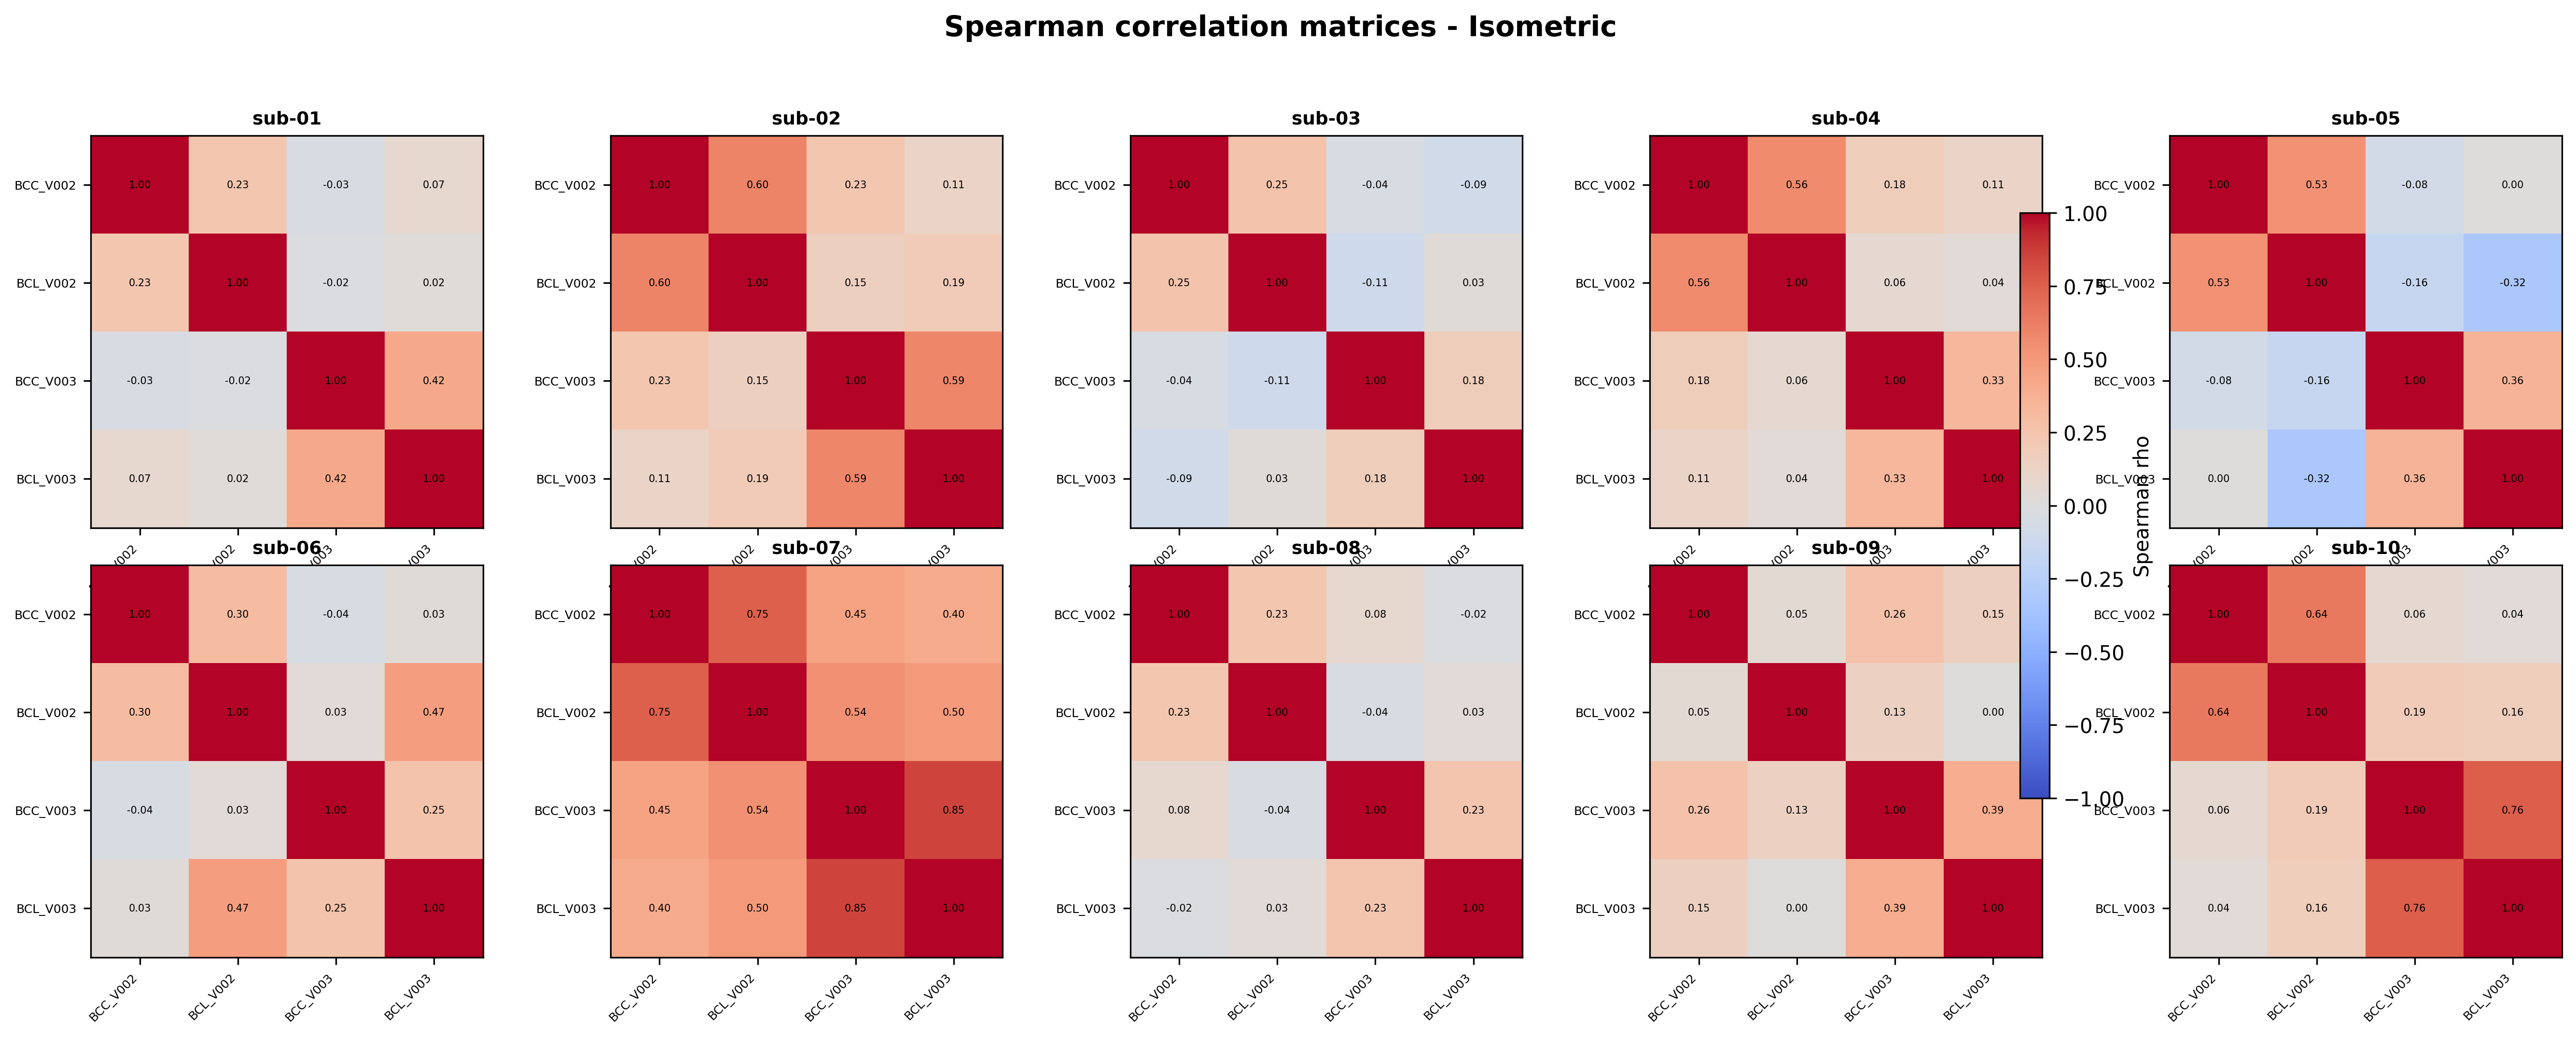

In [88]:
graficar_figura9_matrices_correlacion(
    segmentos_validos,
    condition="Isometric",
    windows=VALID_WINDOWS
)

Condición: Isotonic
Ventanas usadas: [2, 3]
Sujetos detectados: ['sub-01', 'sub-02', 'sub-03', 'sub-04', 'sub-05', 'sub-06', 'sub-07', 'sub-08', 'sub-09', 'sub-10']


C:\Users\david\anaconda3\Lib\site-packages\neurokit2\events\events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(
C:\Users\david\anaconda3\Lib\site-packages\neurokit2\events\events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(
C:\Users\david\AppData\Local\Temp\ipykernel_532\2897823087.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


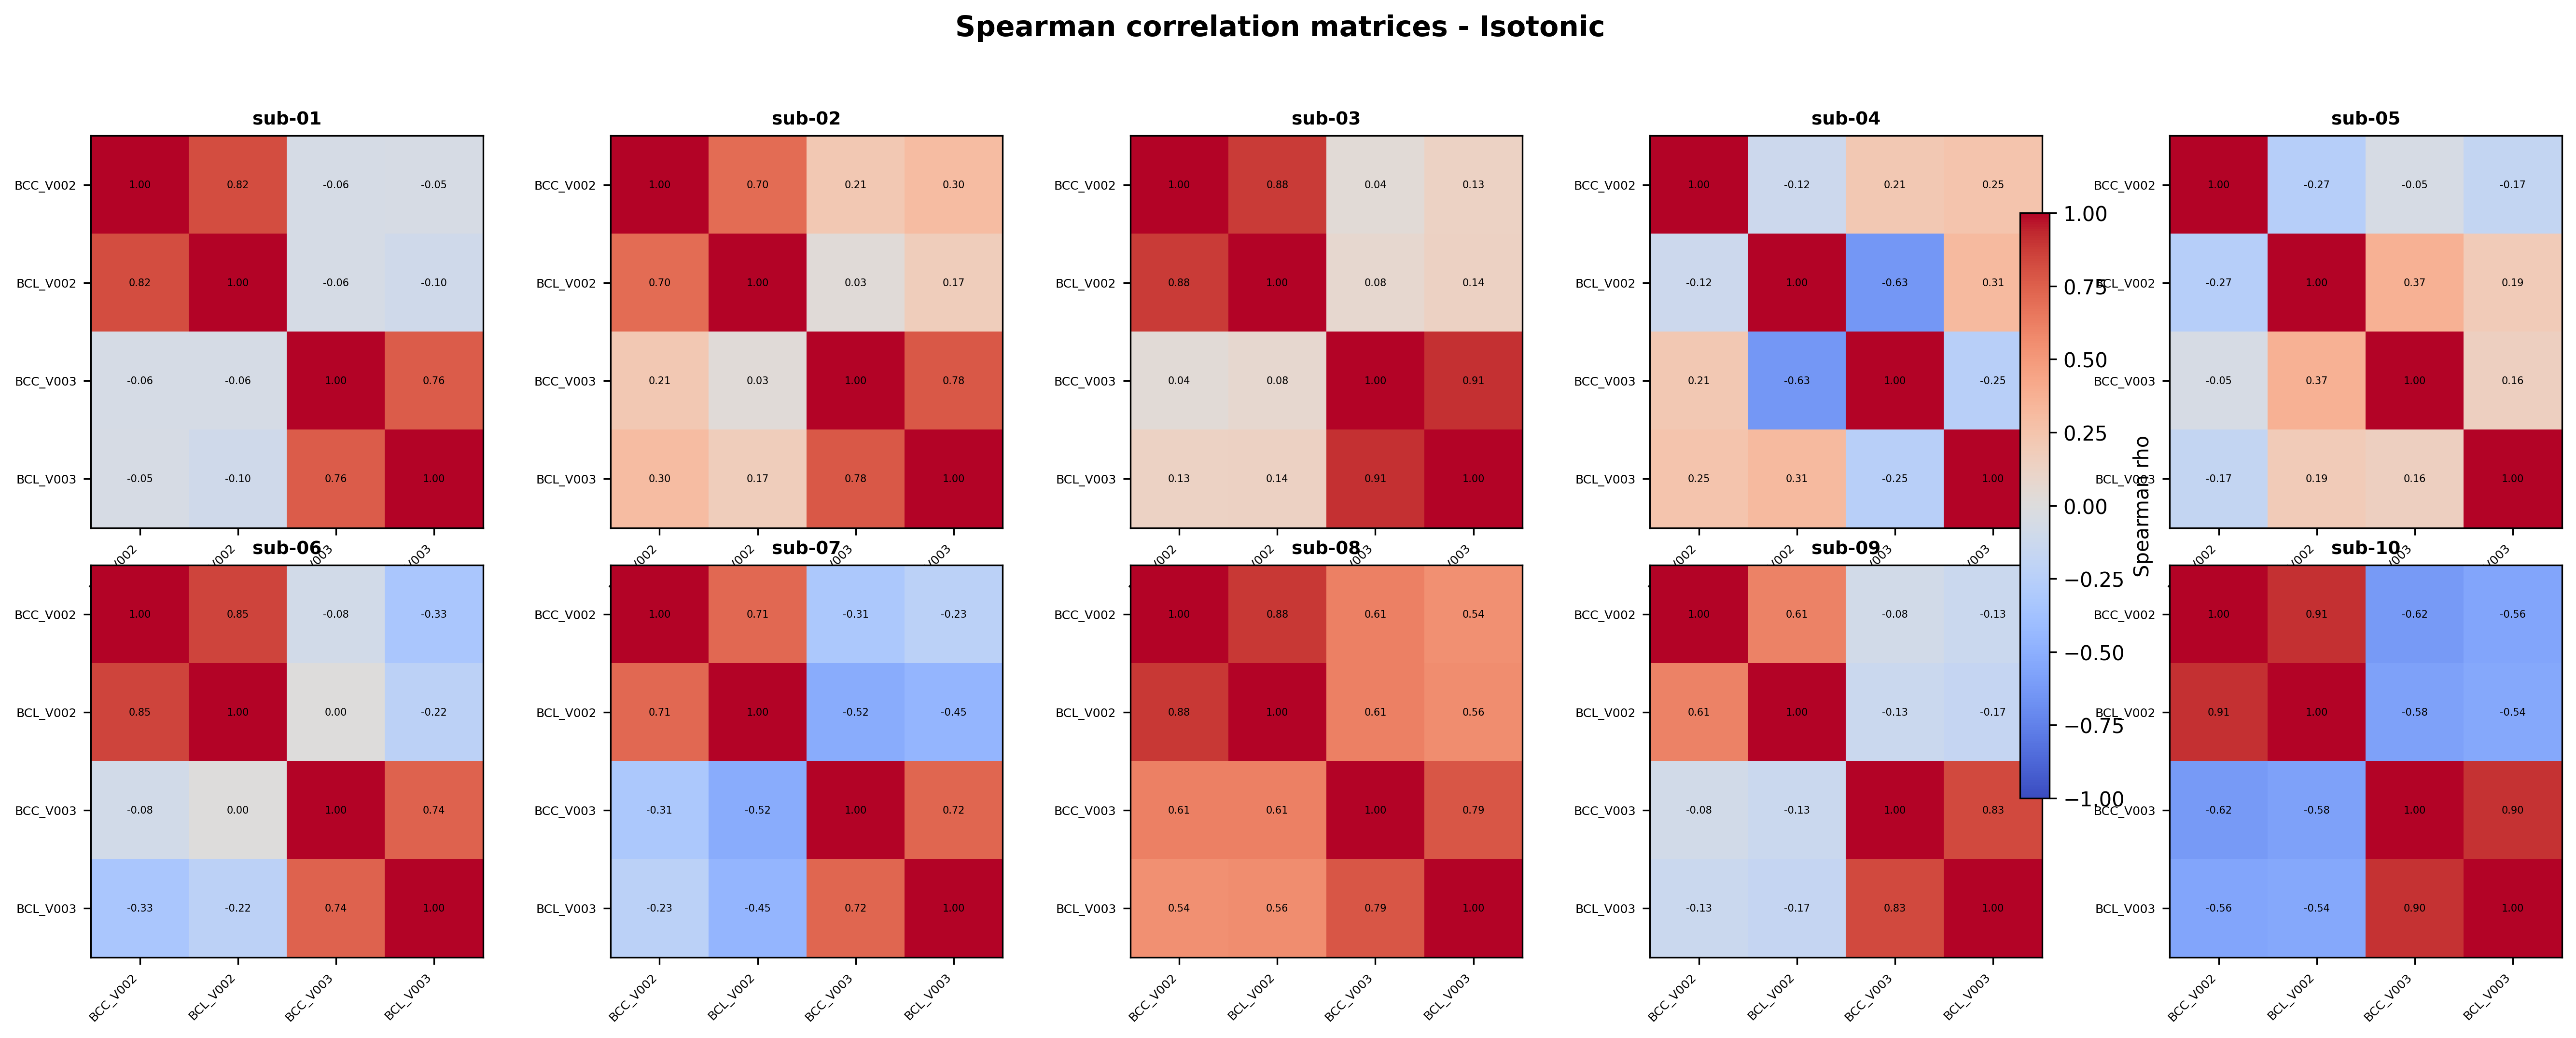

In [90]:
graficar_figura9_matrices_correlacion(
    segmentos_validos,
    condition="Isotonic",
    windows=VALID_WINDOWS
)

## 20. Figure 10: Violin plot of BCC-BCL Spearman correlations

This section summarizes the distribution of BCC-BCL Spearman correlation coefficients for isometric and isotonic contractions.

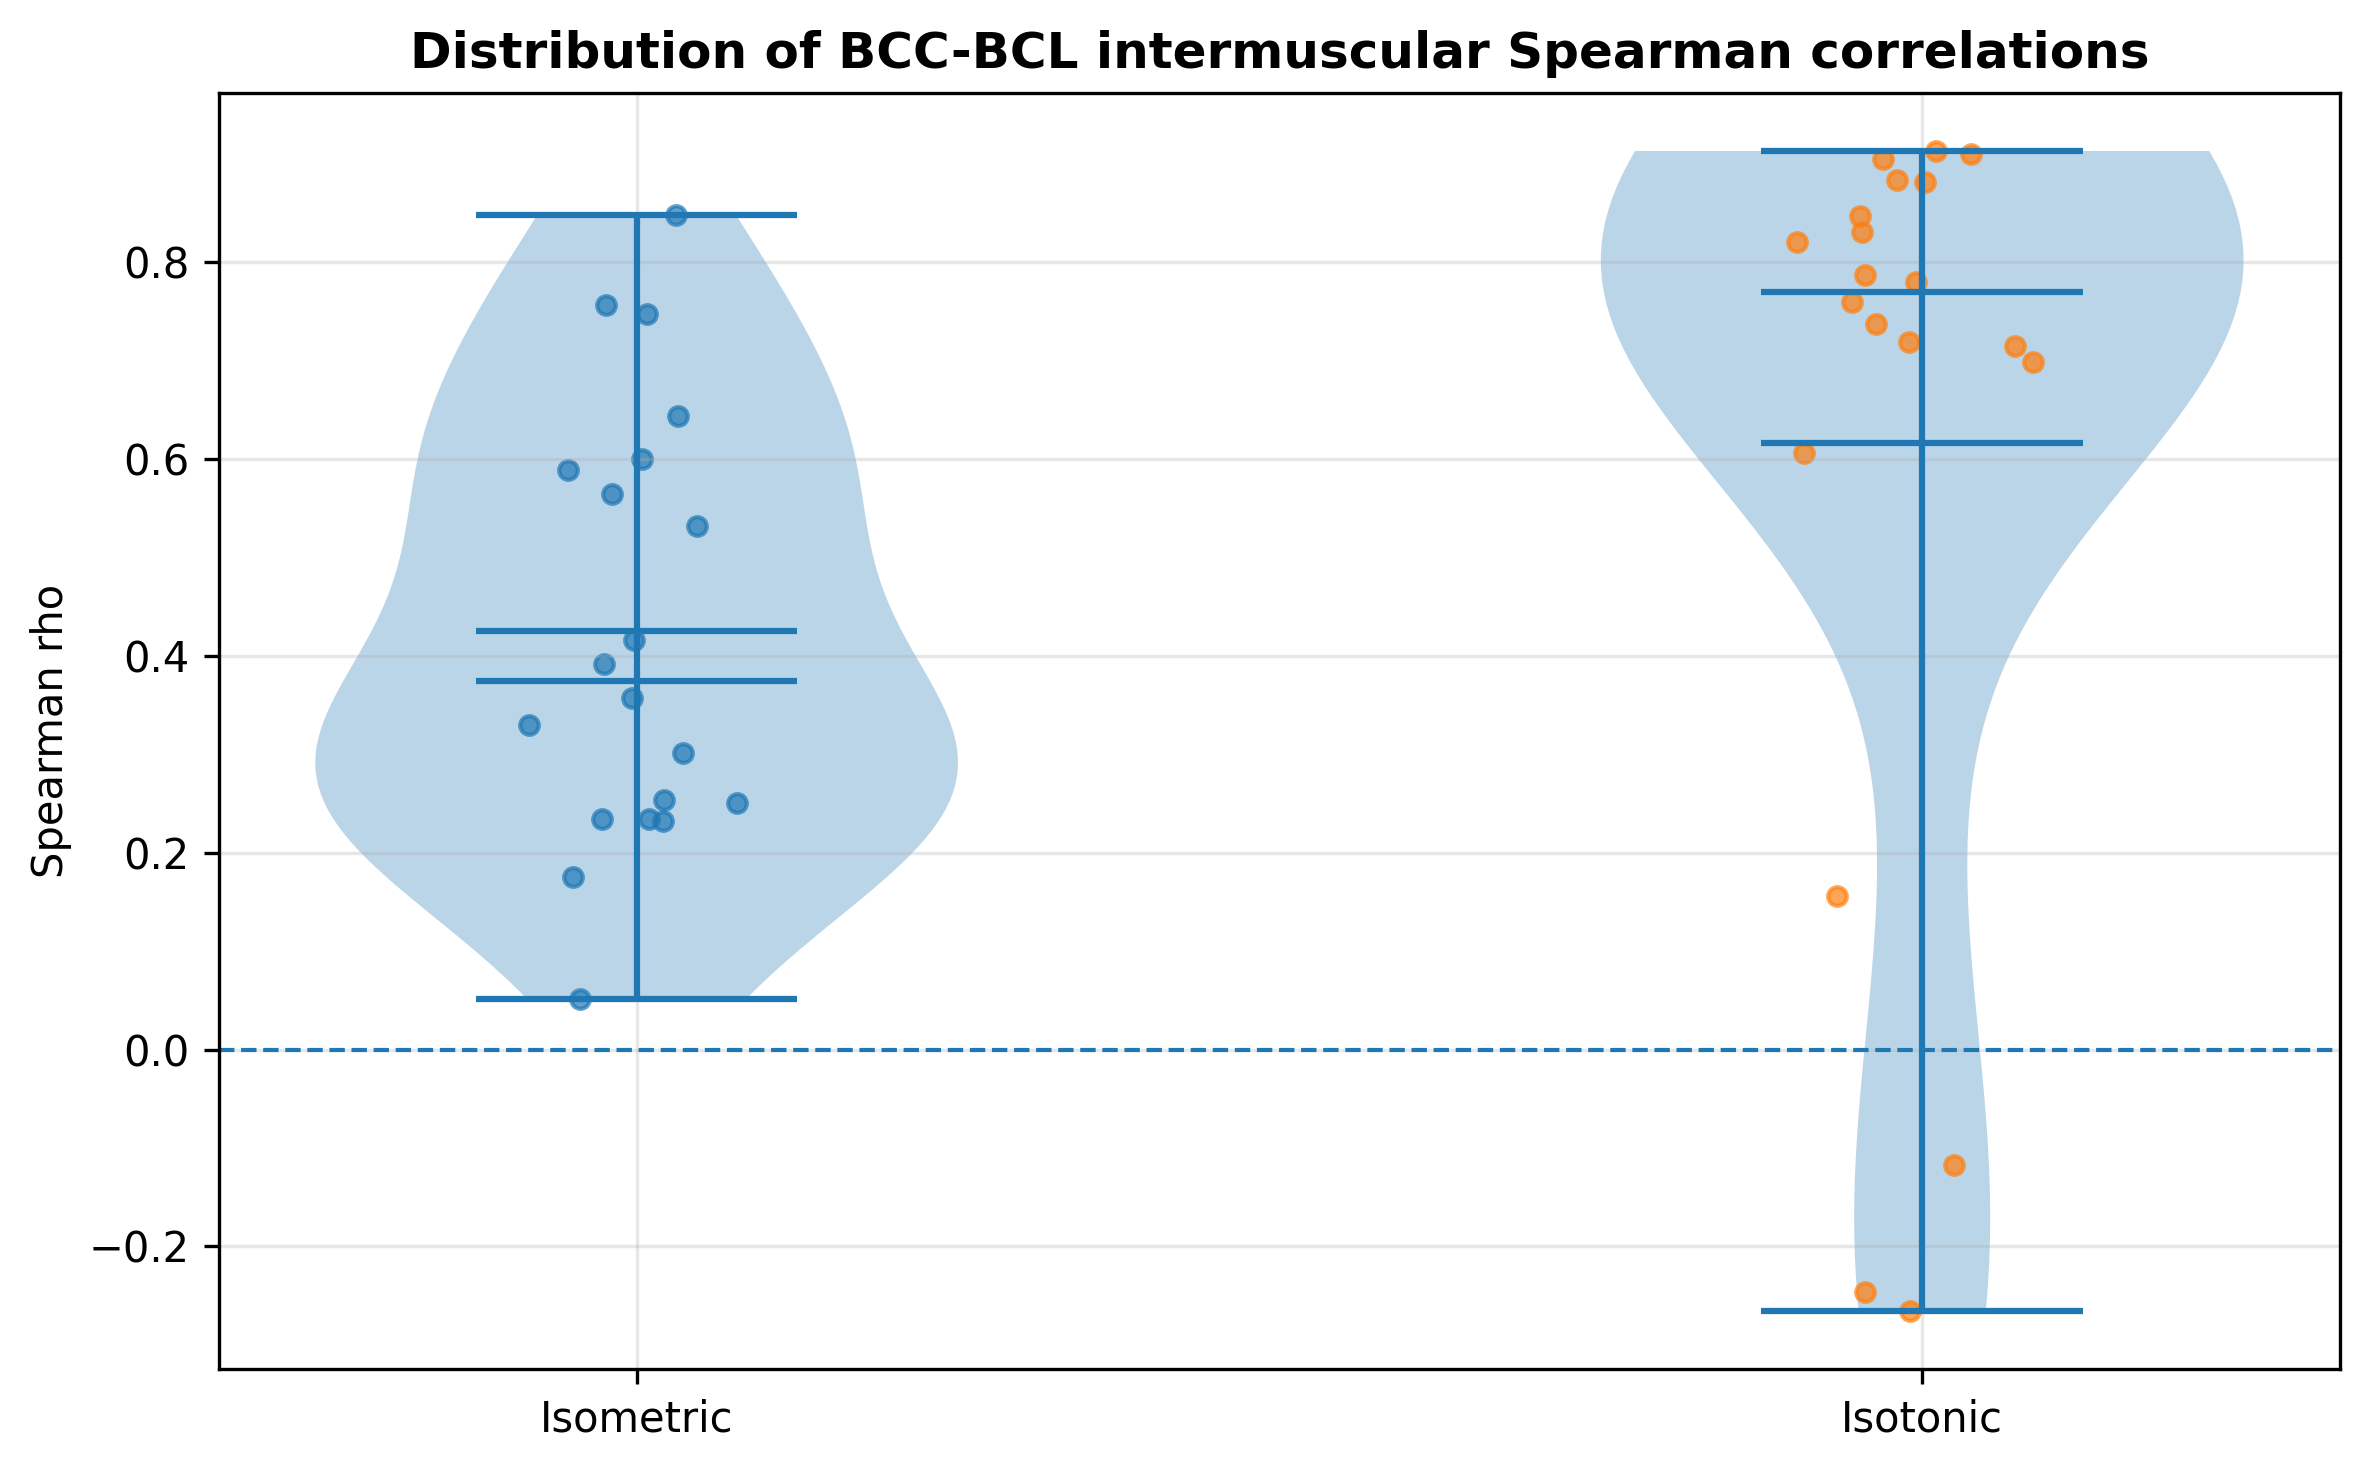

In [91]:
def graficar_figura10_violin_correlaciones(df_correlacion):
    """
    Generate violin plots of BCC-BCL Spearman correlation coefficients
    for isometric and isotonic contractions.
    """
    condiciones = ["Isometric", "Isotonic"]

    datos = [
        df_correlacion[
            df_correlacion["Condition"] == condicion
        ]["Spearman_rho"].dropna().values
        for condicion in condiciones
    ]

    fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

    ax.violinplot(
        datos,
        showmeans=True,
        showmedians=True,
        showextrema=True
    )

    ax.set_xticks([1, 2])
    ax.set_xticklabels(condiciones)
    ax.set_ylabel("Spearman rho")
    ax.set_title(
        "Distribution of BCC-BCL intermuscular Spearman correlations",
        fontsize=12,
        fontweight="bold"
    )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.3)

    for i, condicion in enumerate(condiciones, start=1):
        valores = datos[i - 1]
        x = np.random.normal(i, 0.04, size=len(valores))
        ax.scatter(x, valores, s=20, alpha=0.7)

    plt.tight_layout()

    nombre_base = "figure10_violin_spearman_correlation_BCC_BCL"

    guardar_figura(fig, nombre_base)

    plt.show()


graficar_figura10_violin_correlaciones(df_correlacion)

## 21. Supplementary boxplots for Raw vs Processed metrics

These figures are complementary to the manuscript table and can be used as supplementary material.

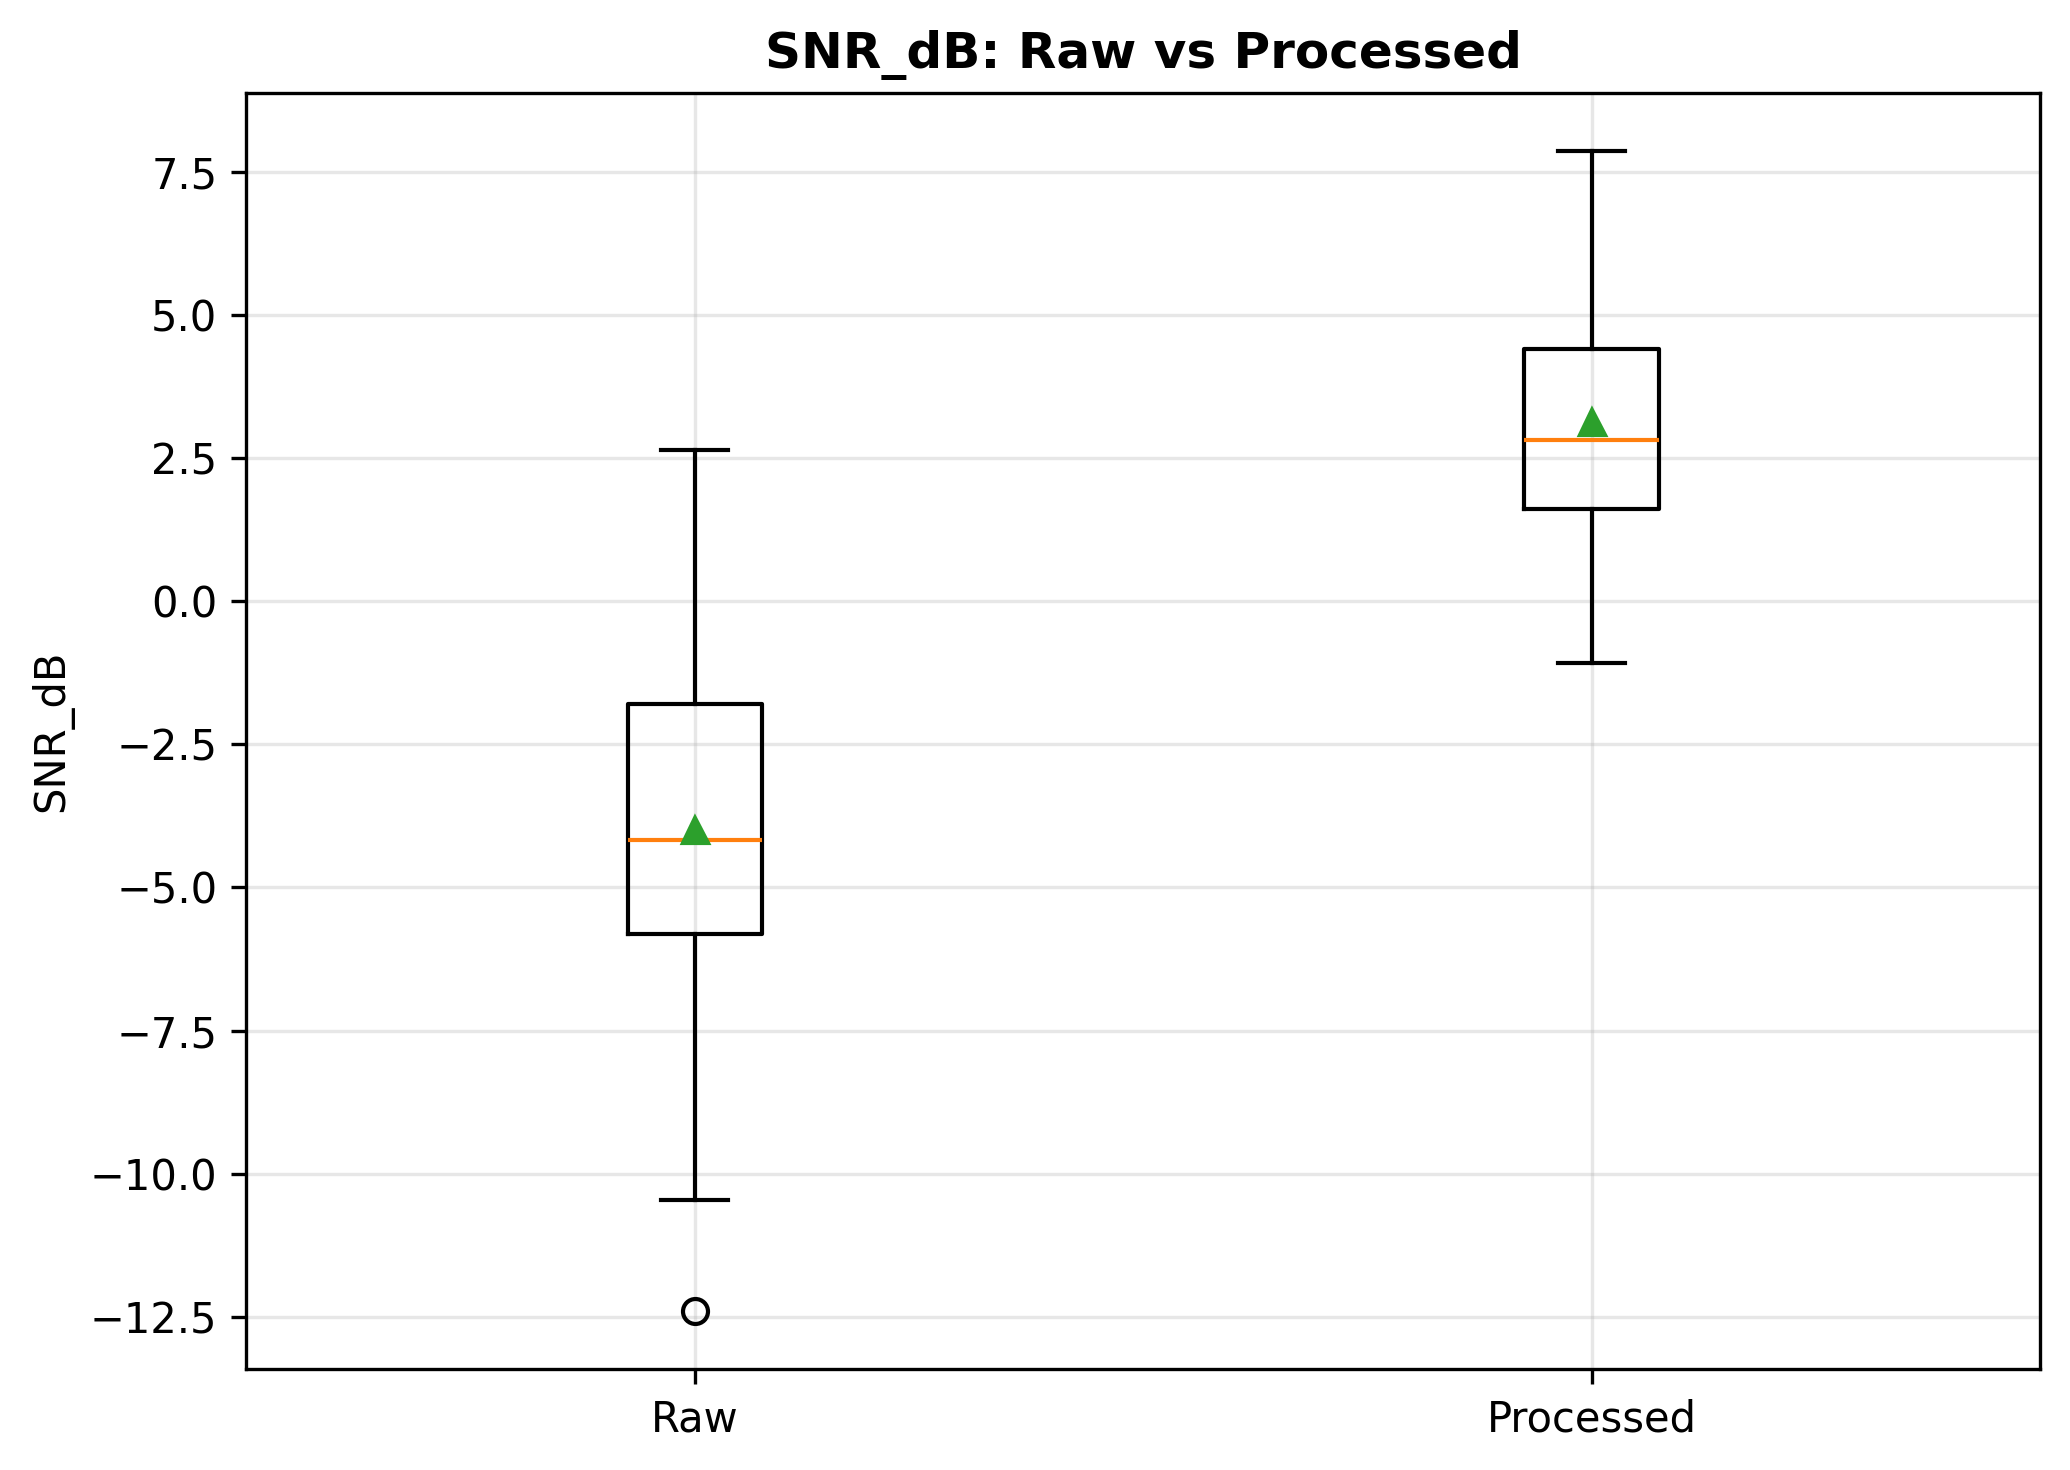

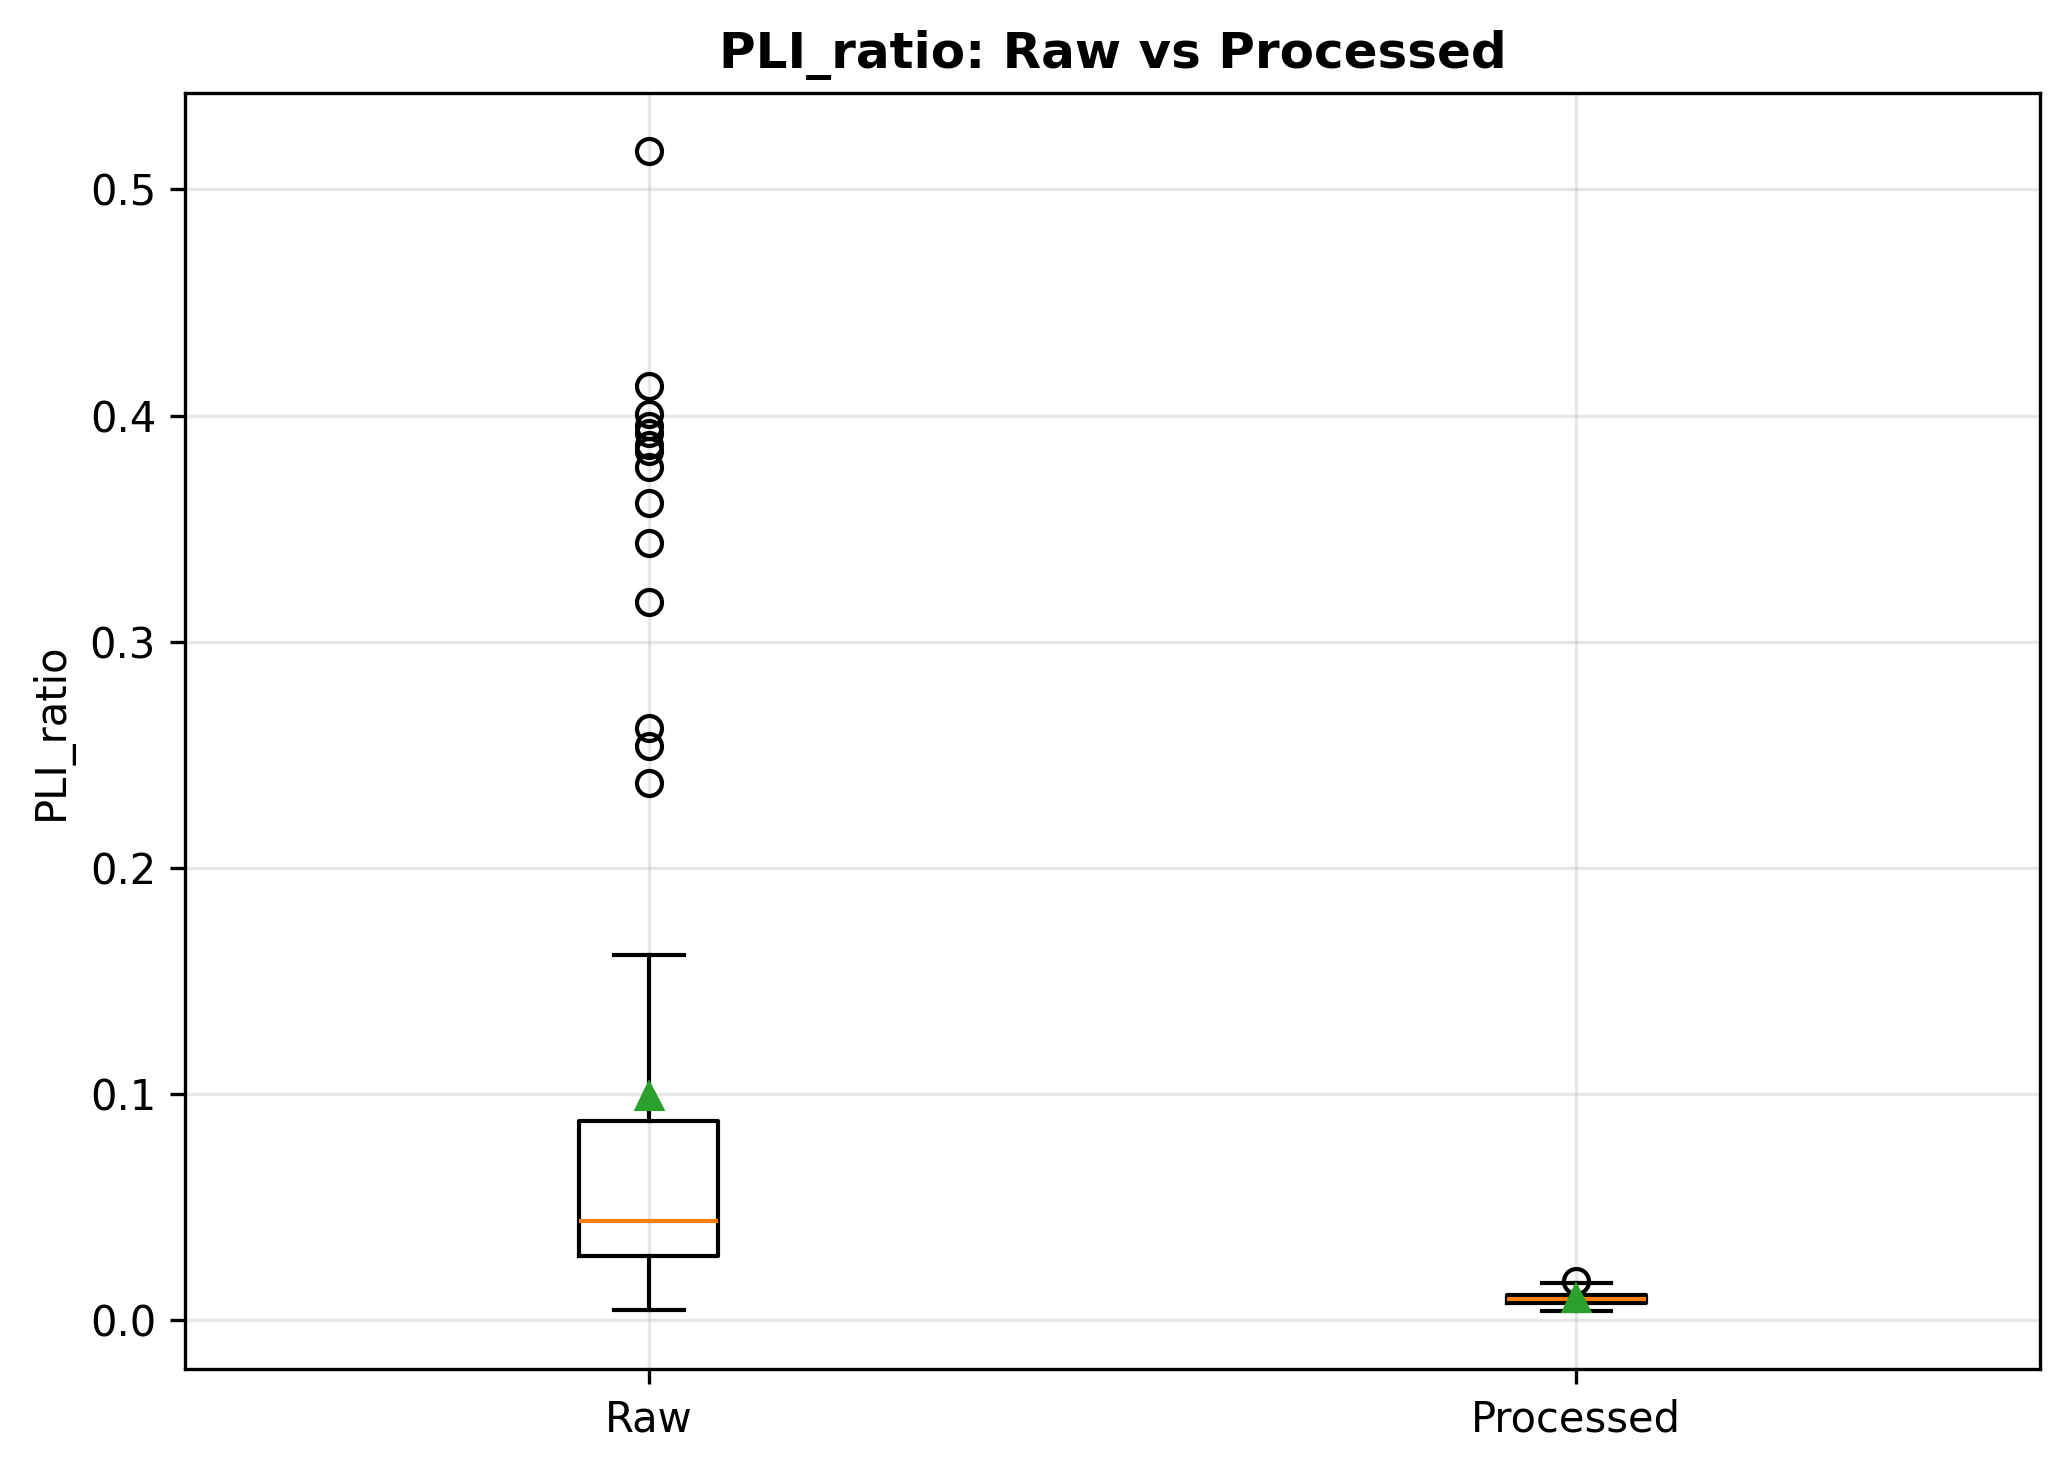

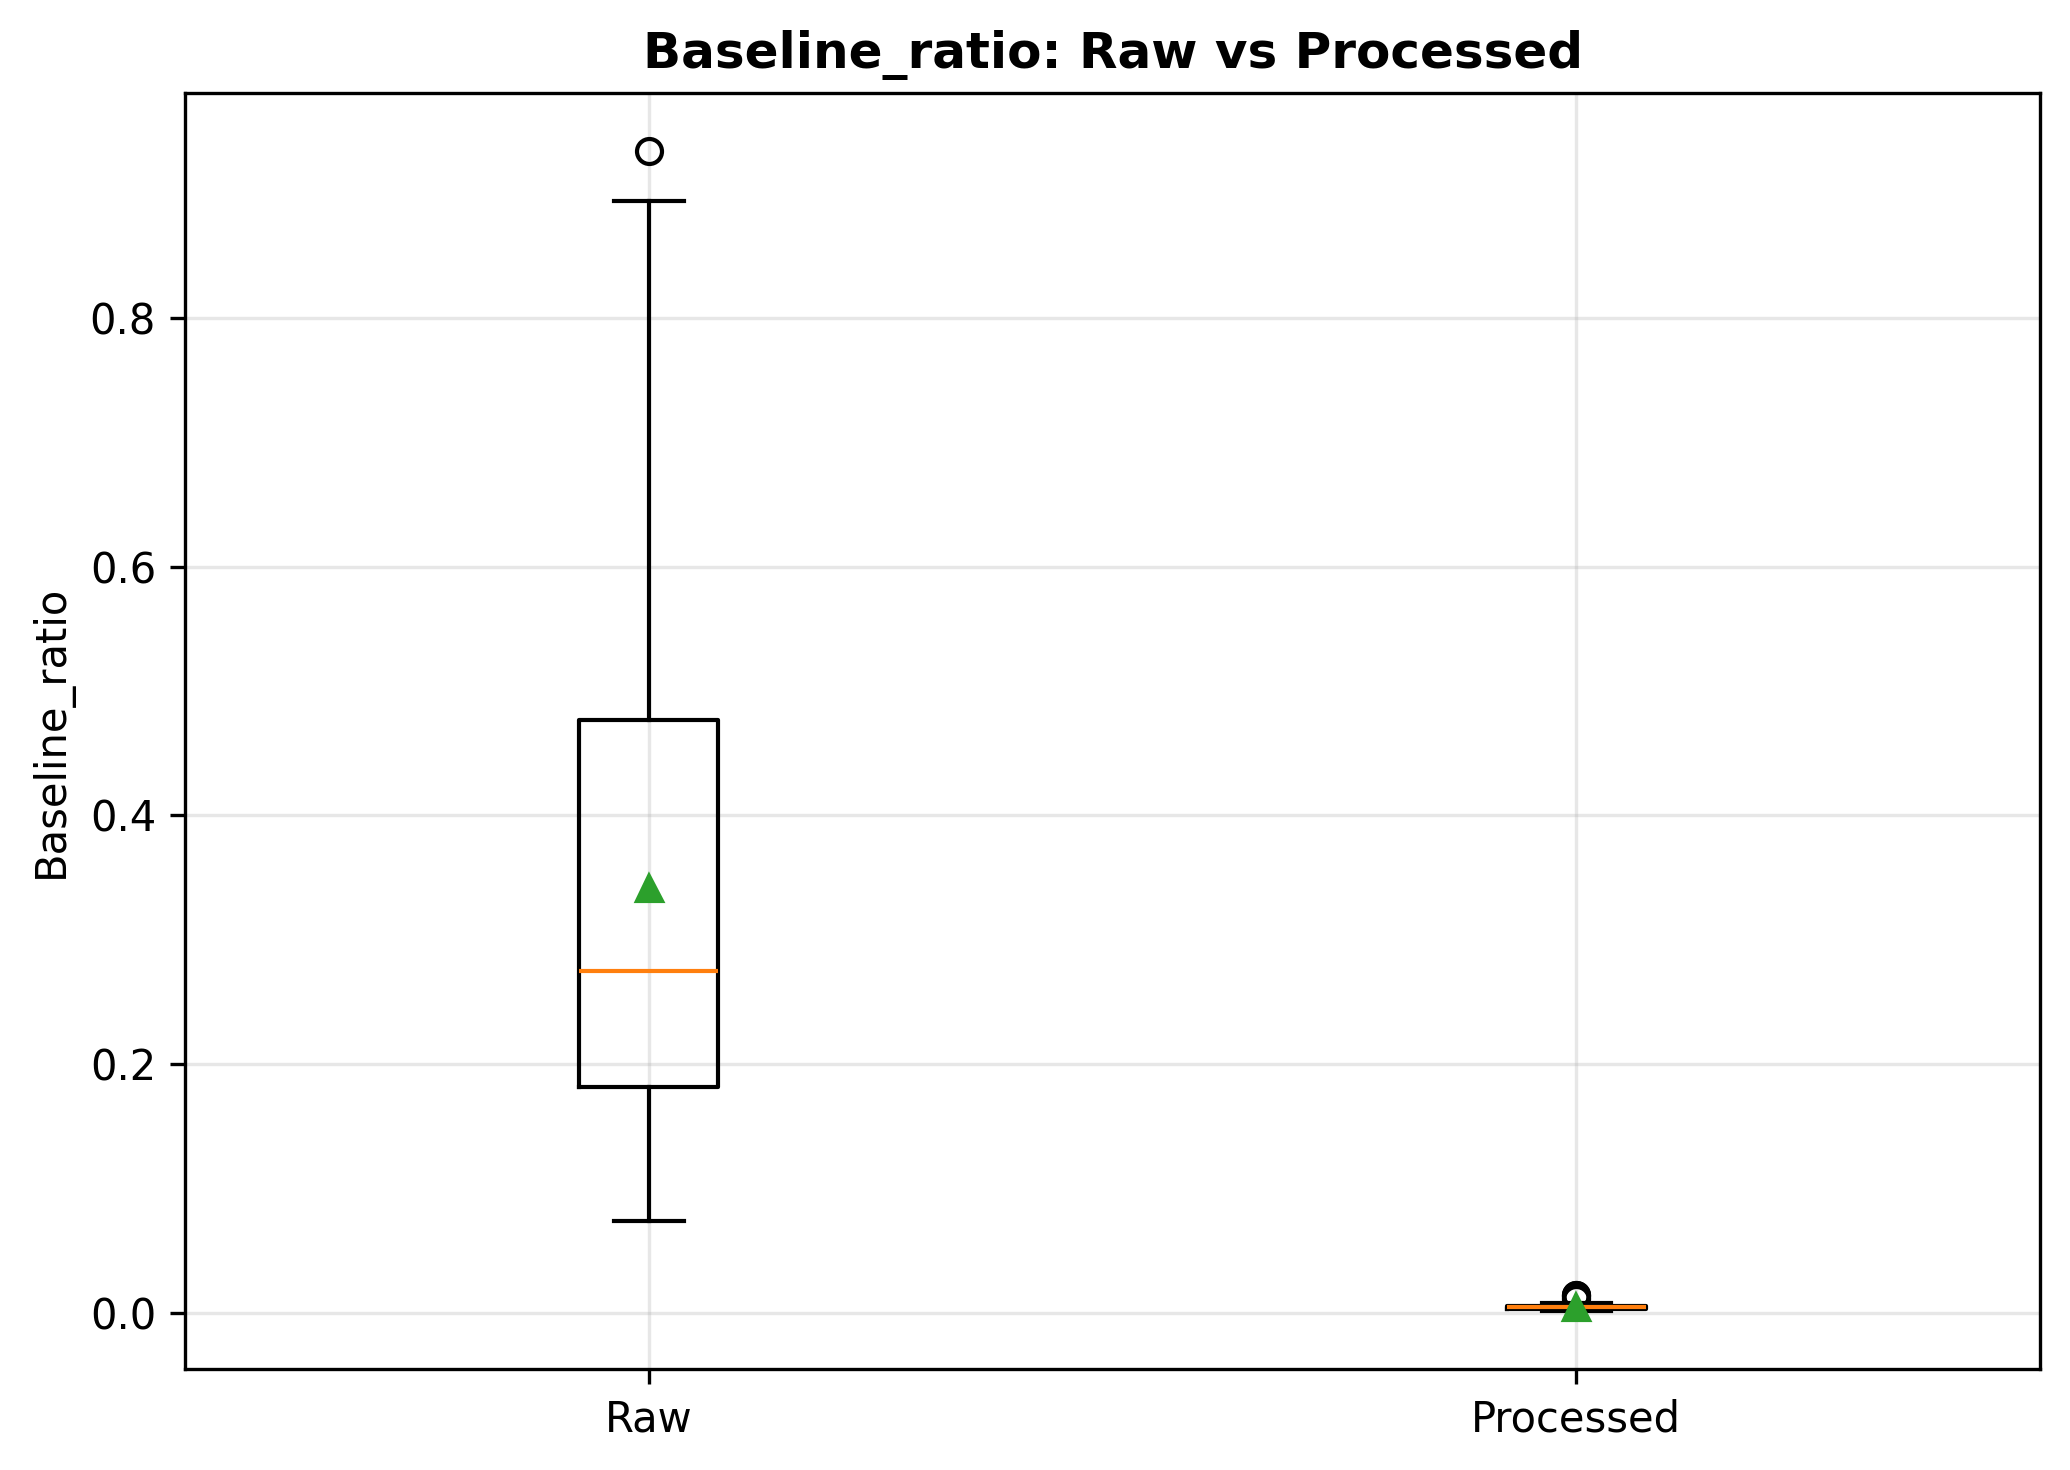

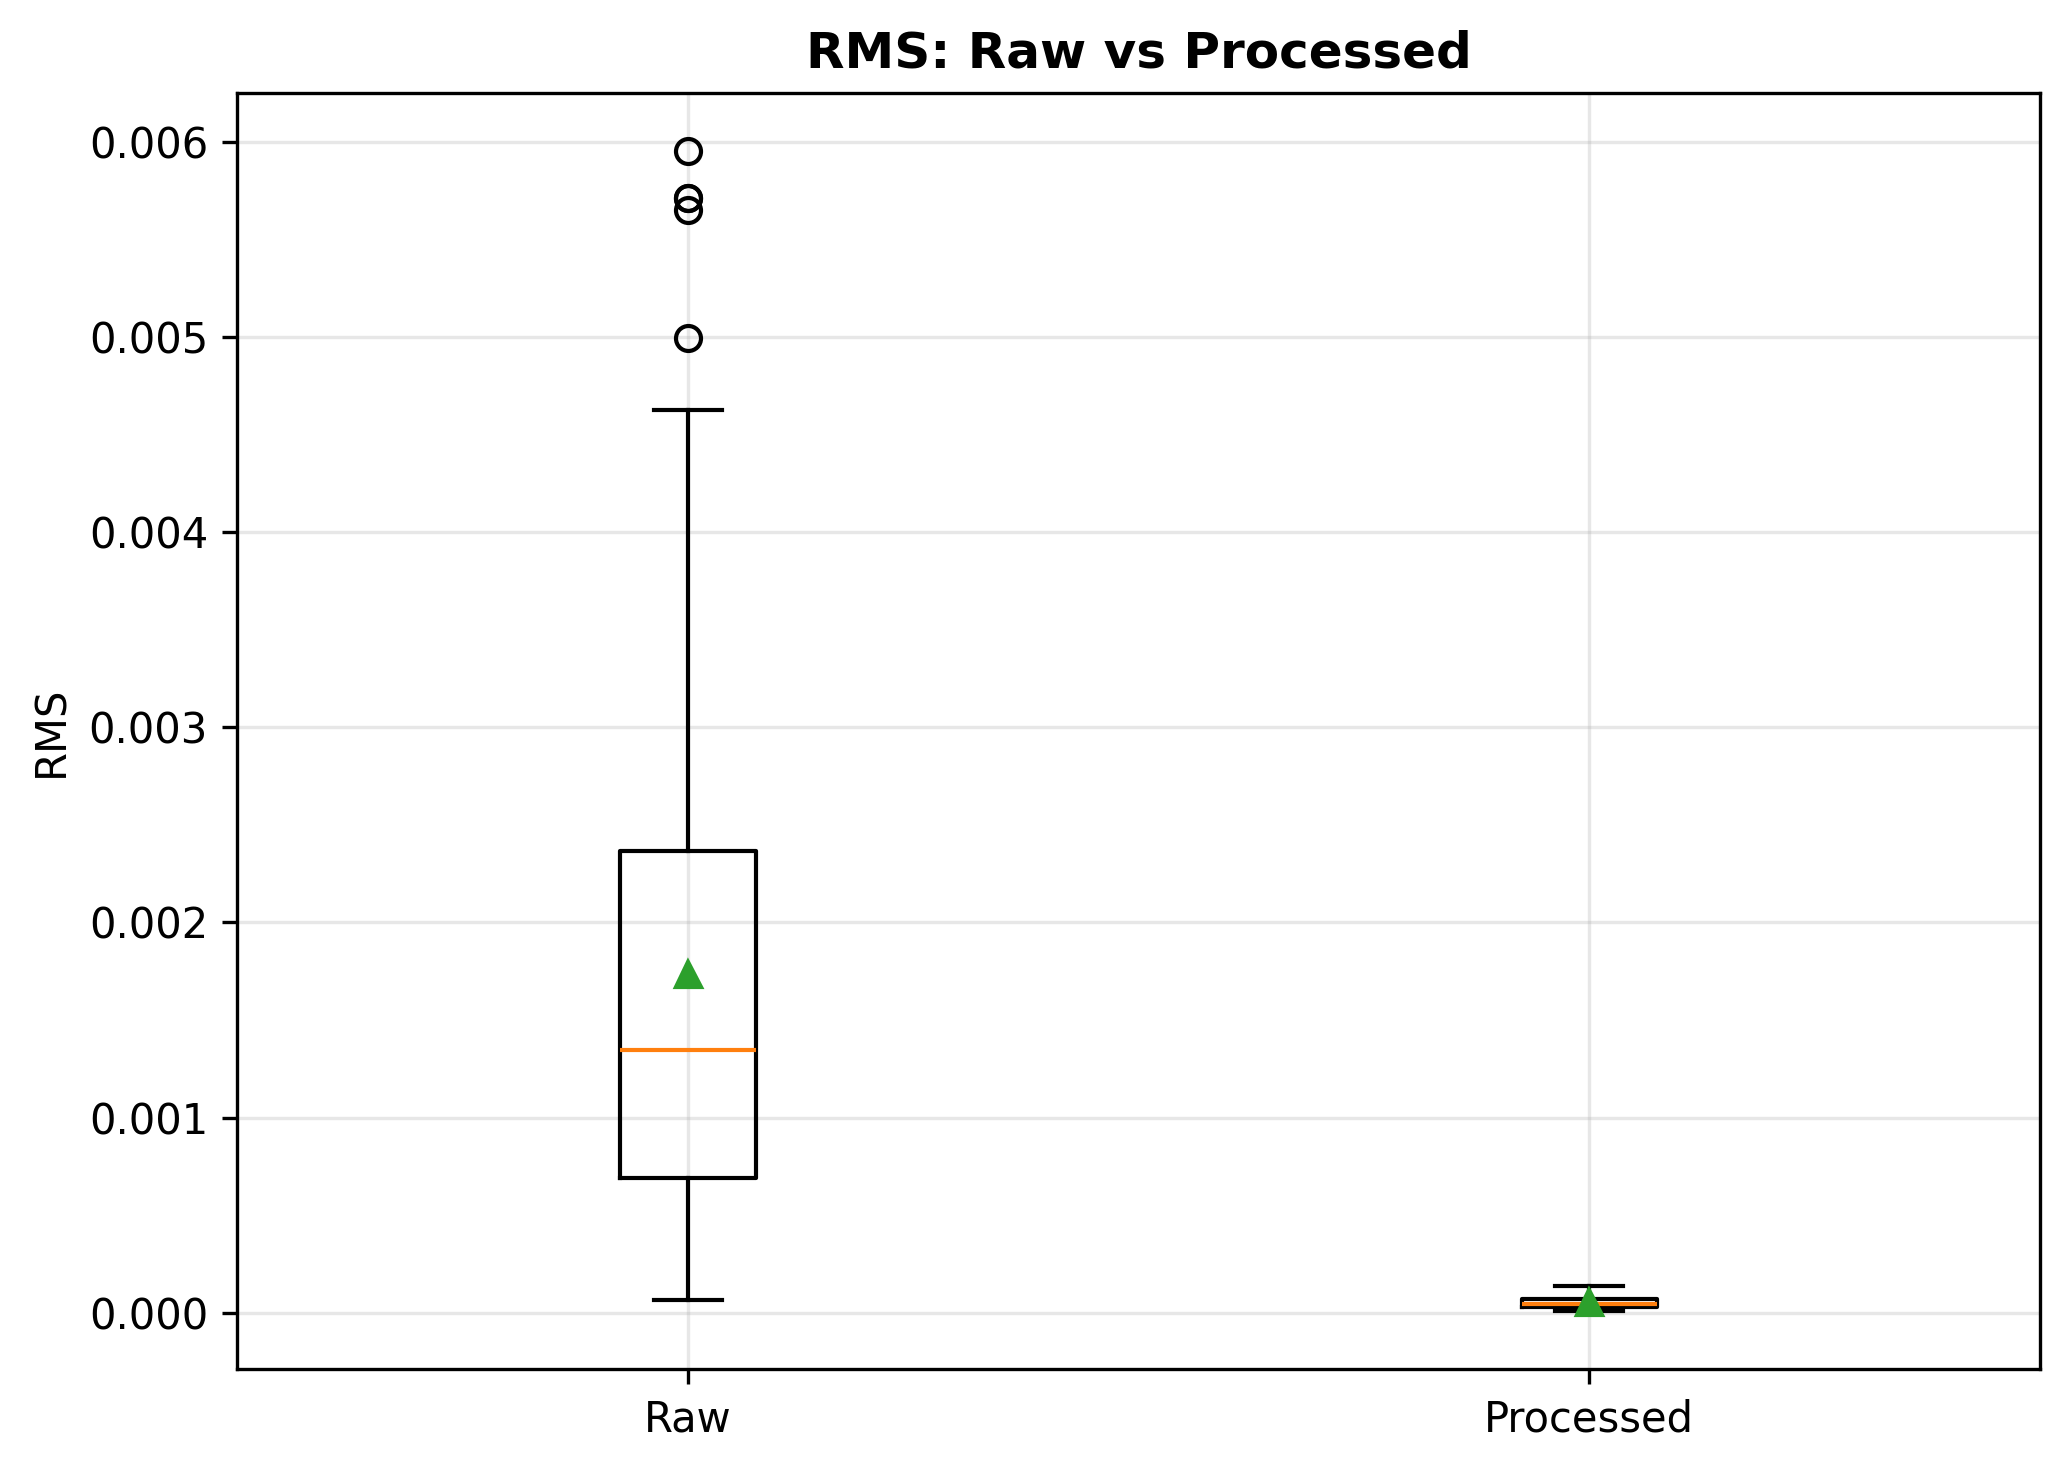

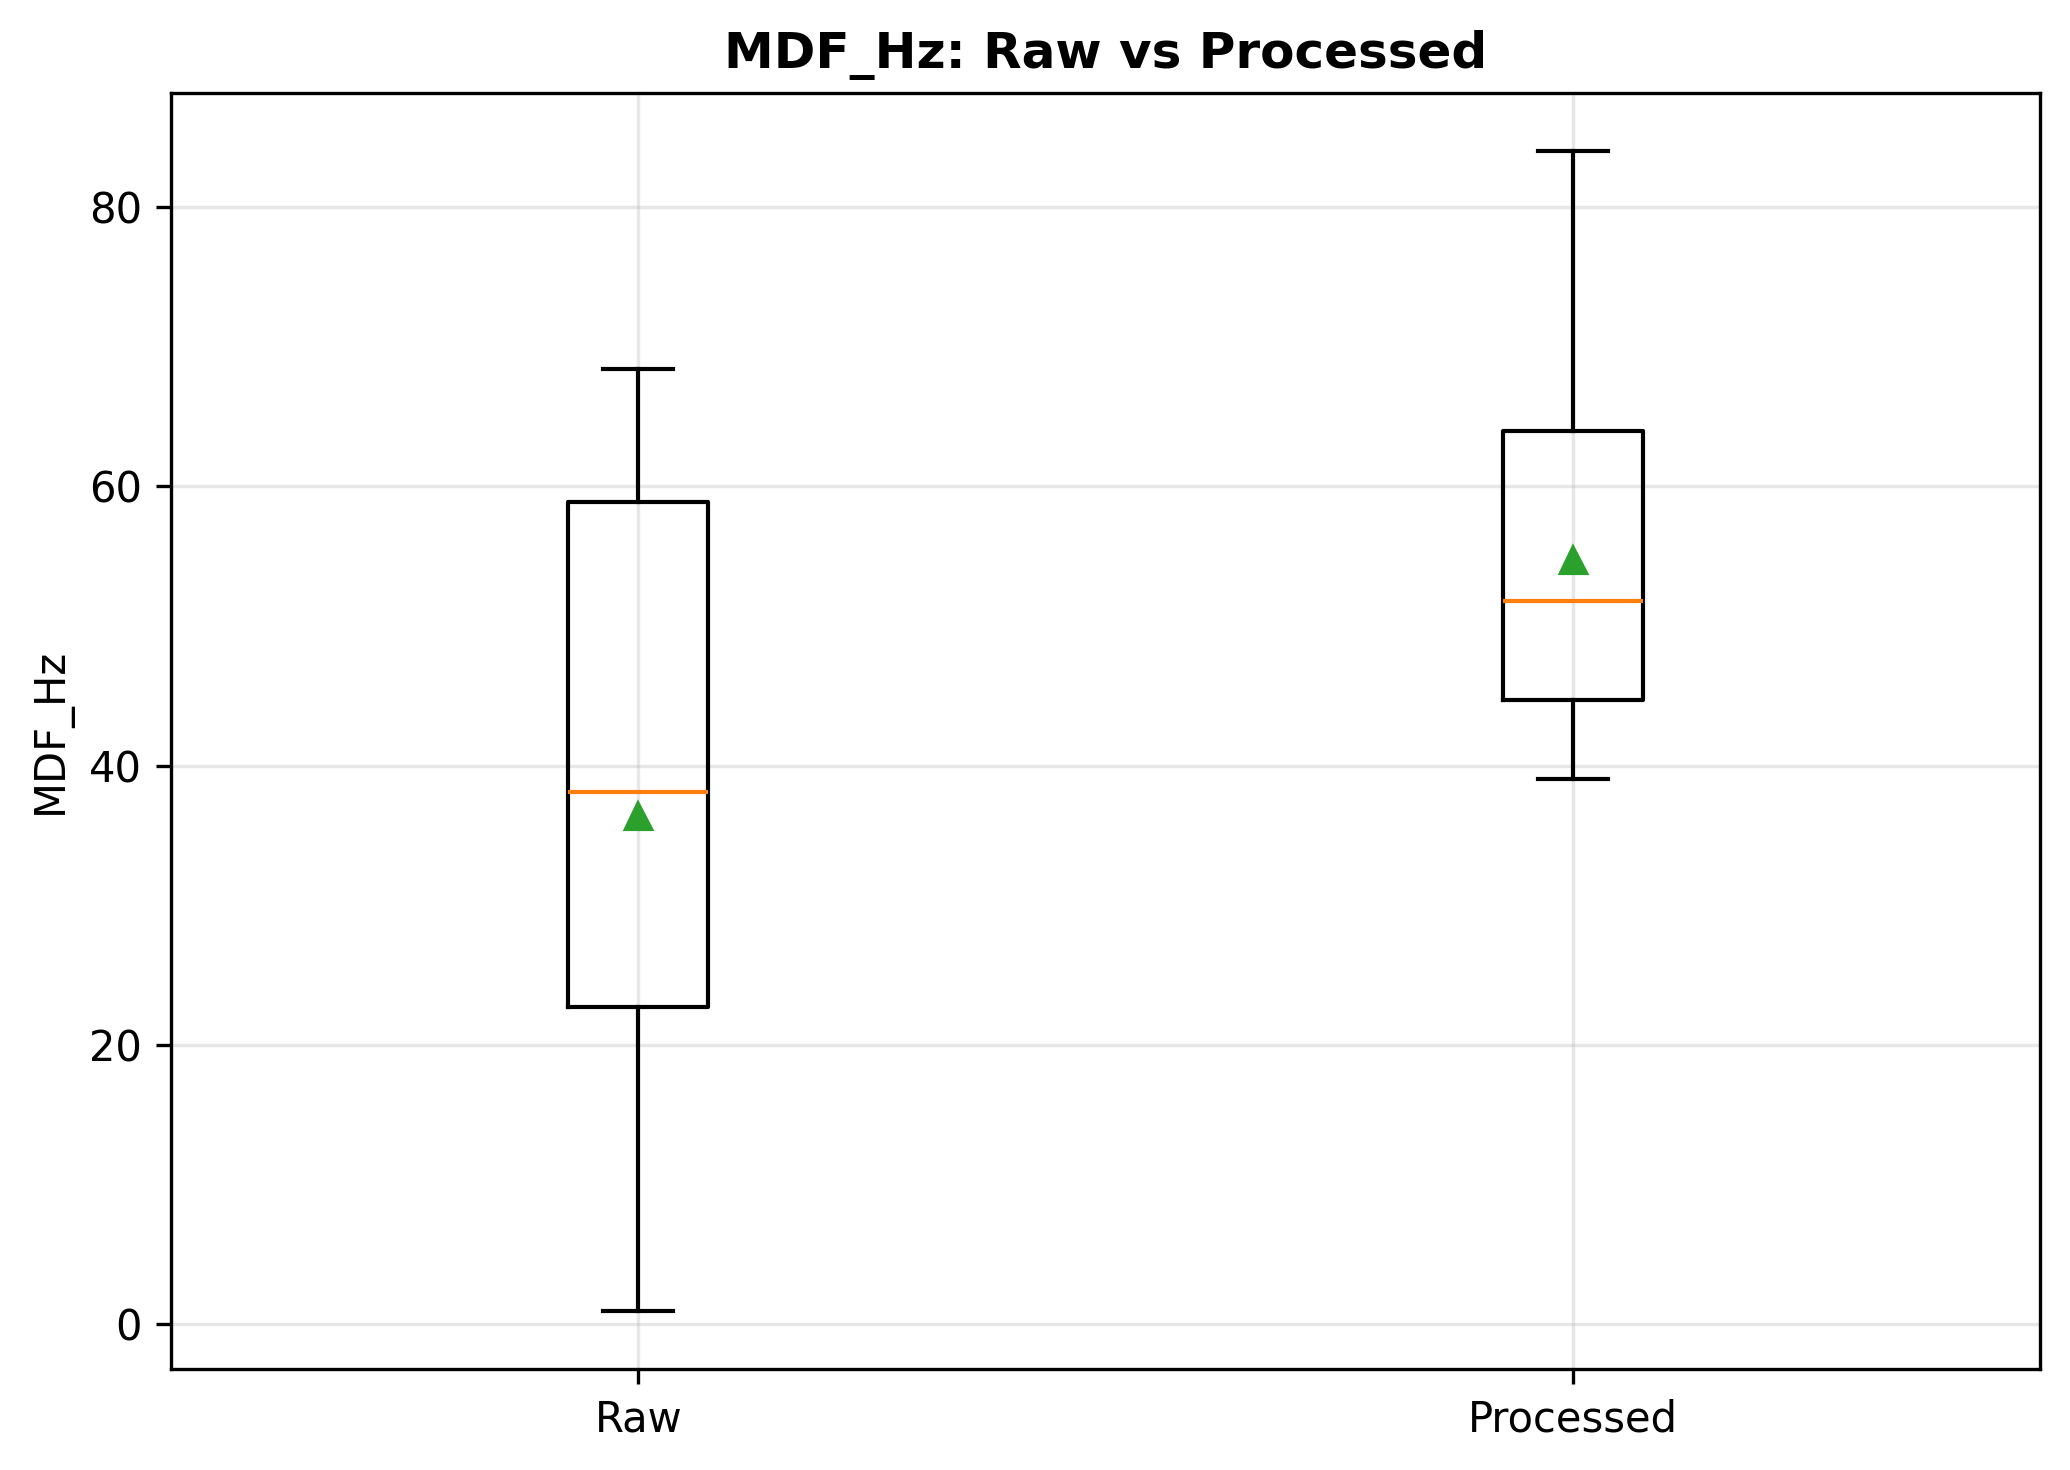

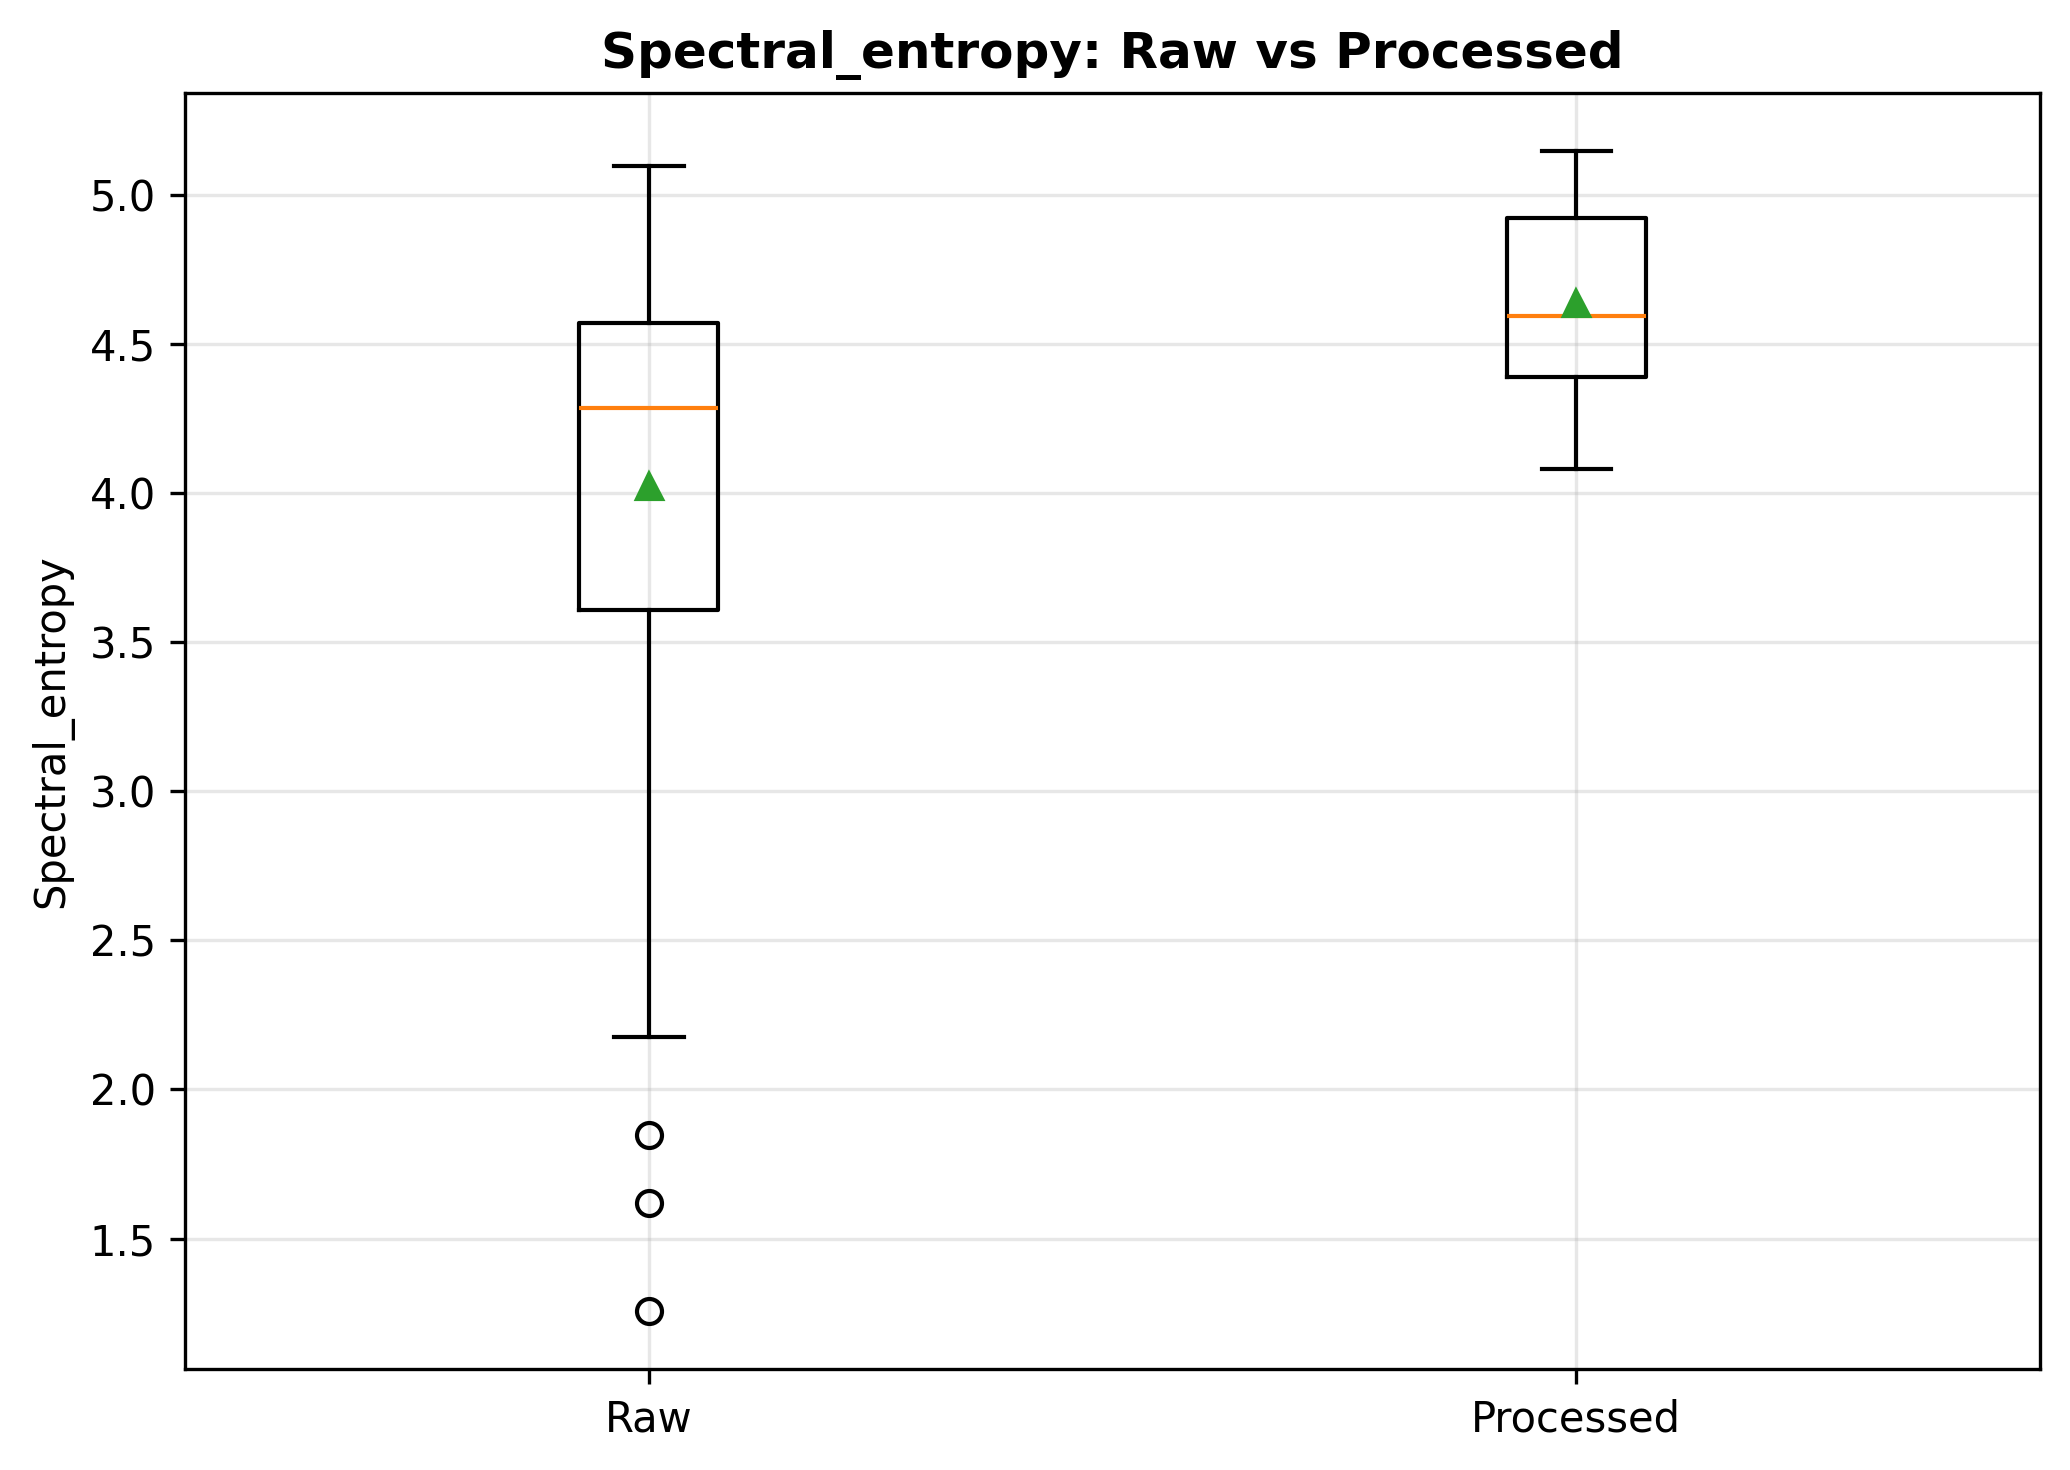

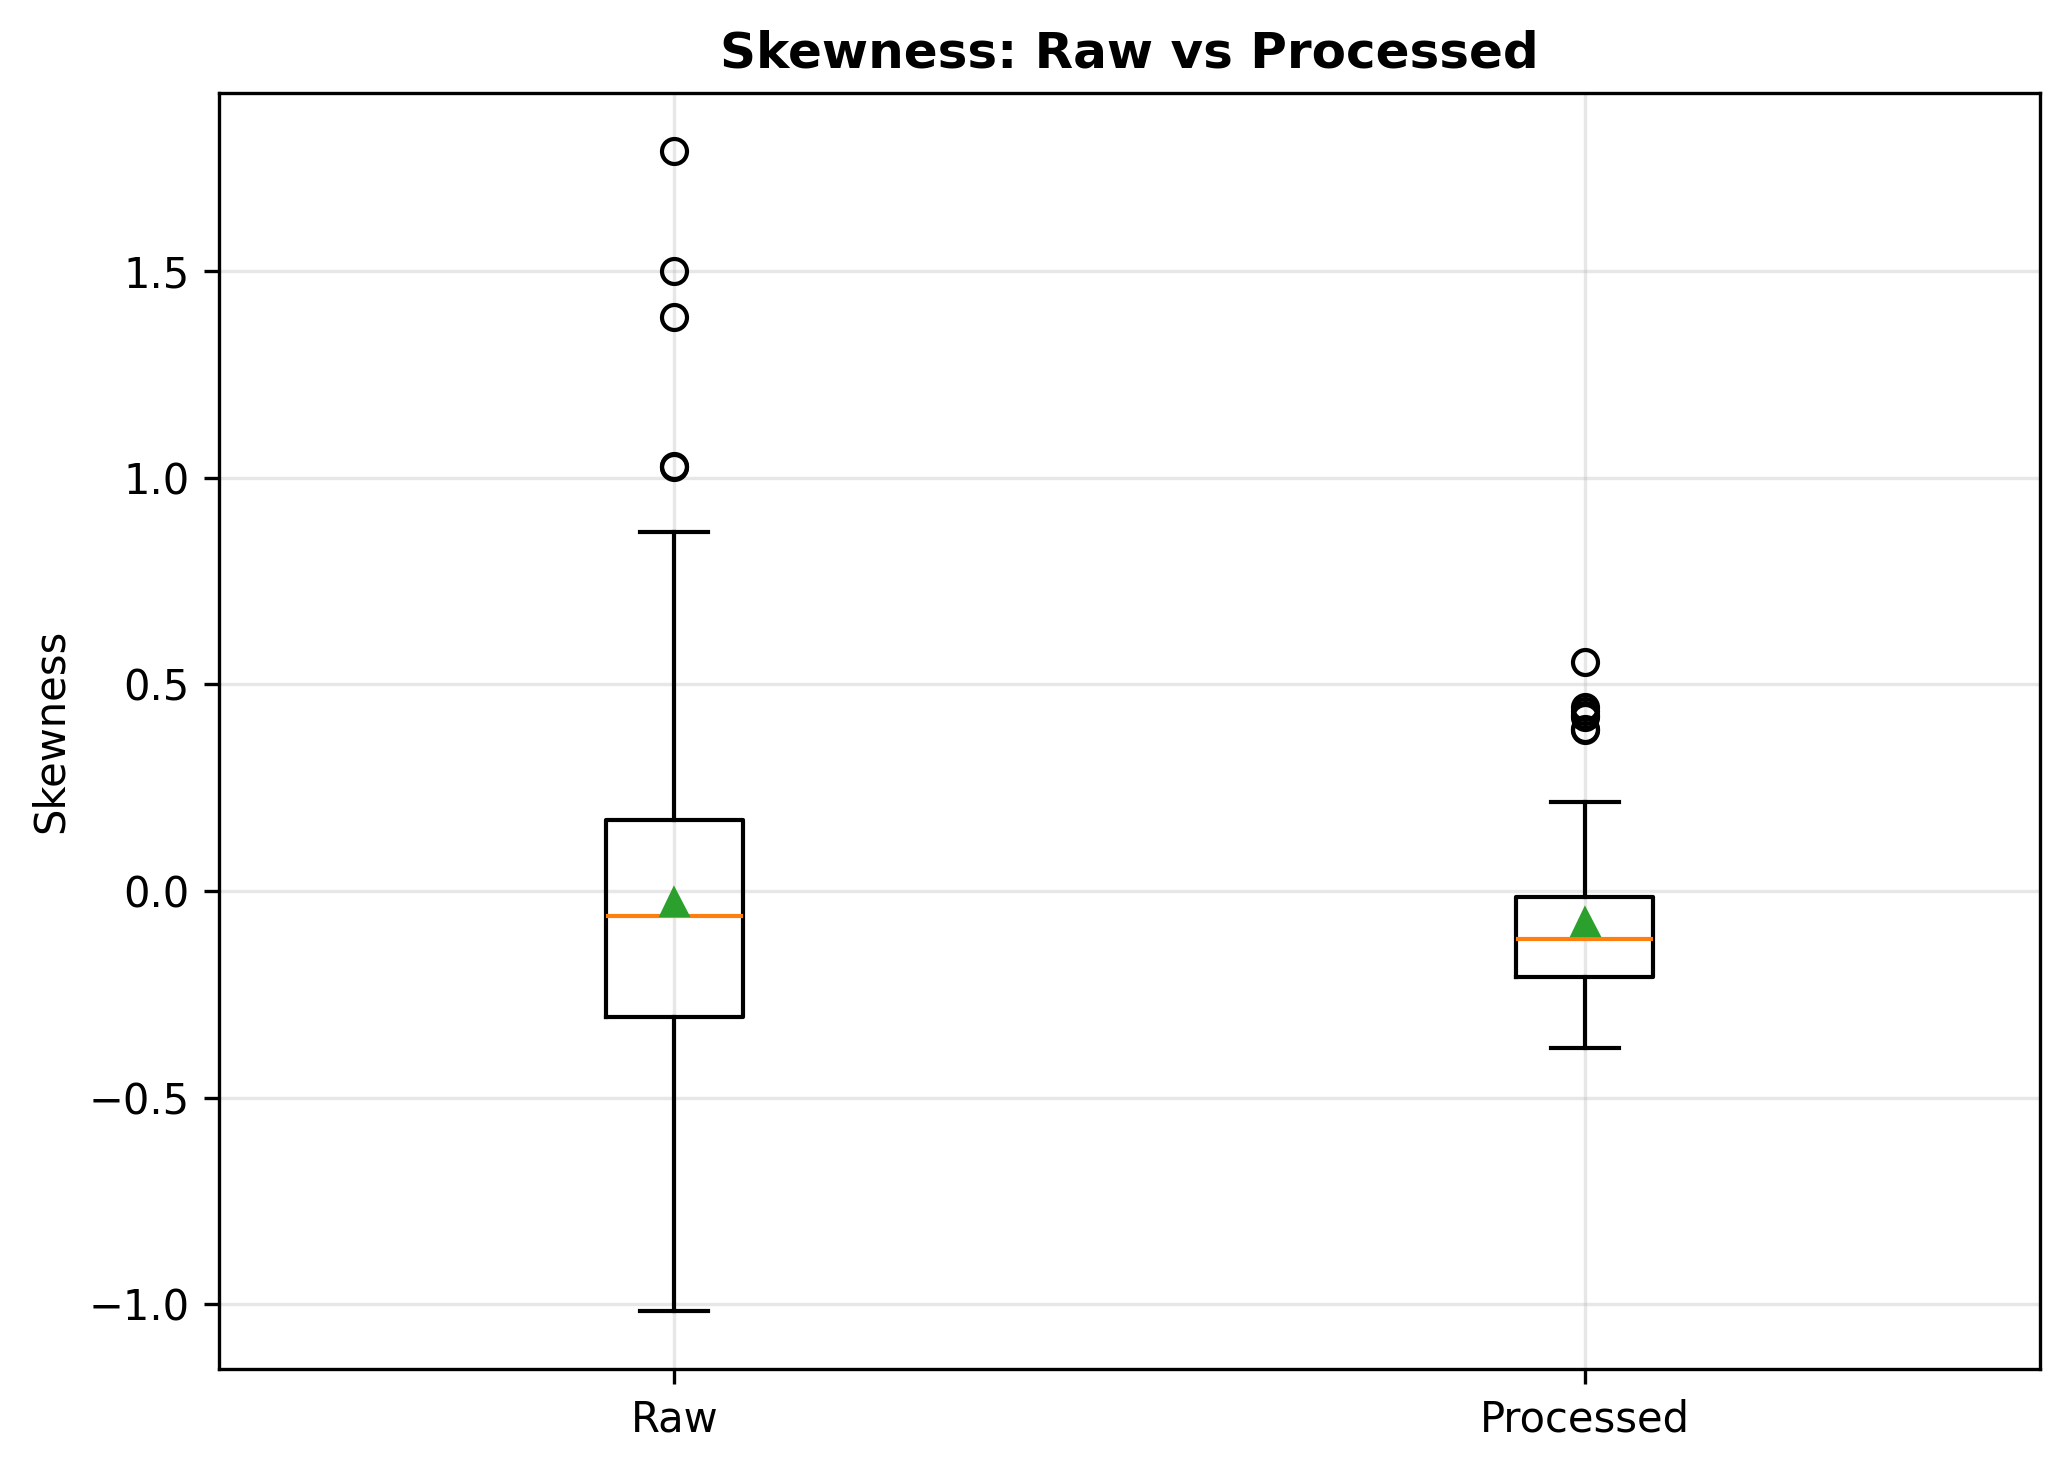

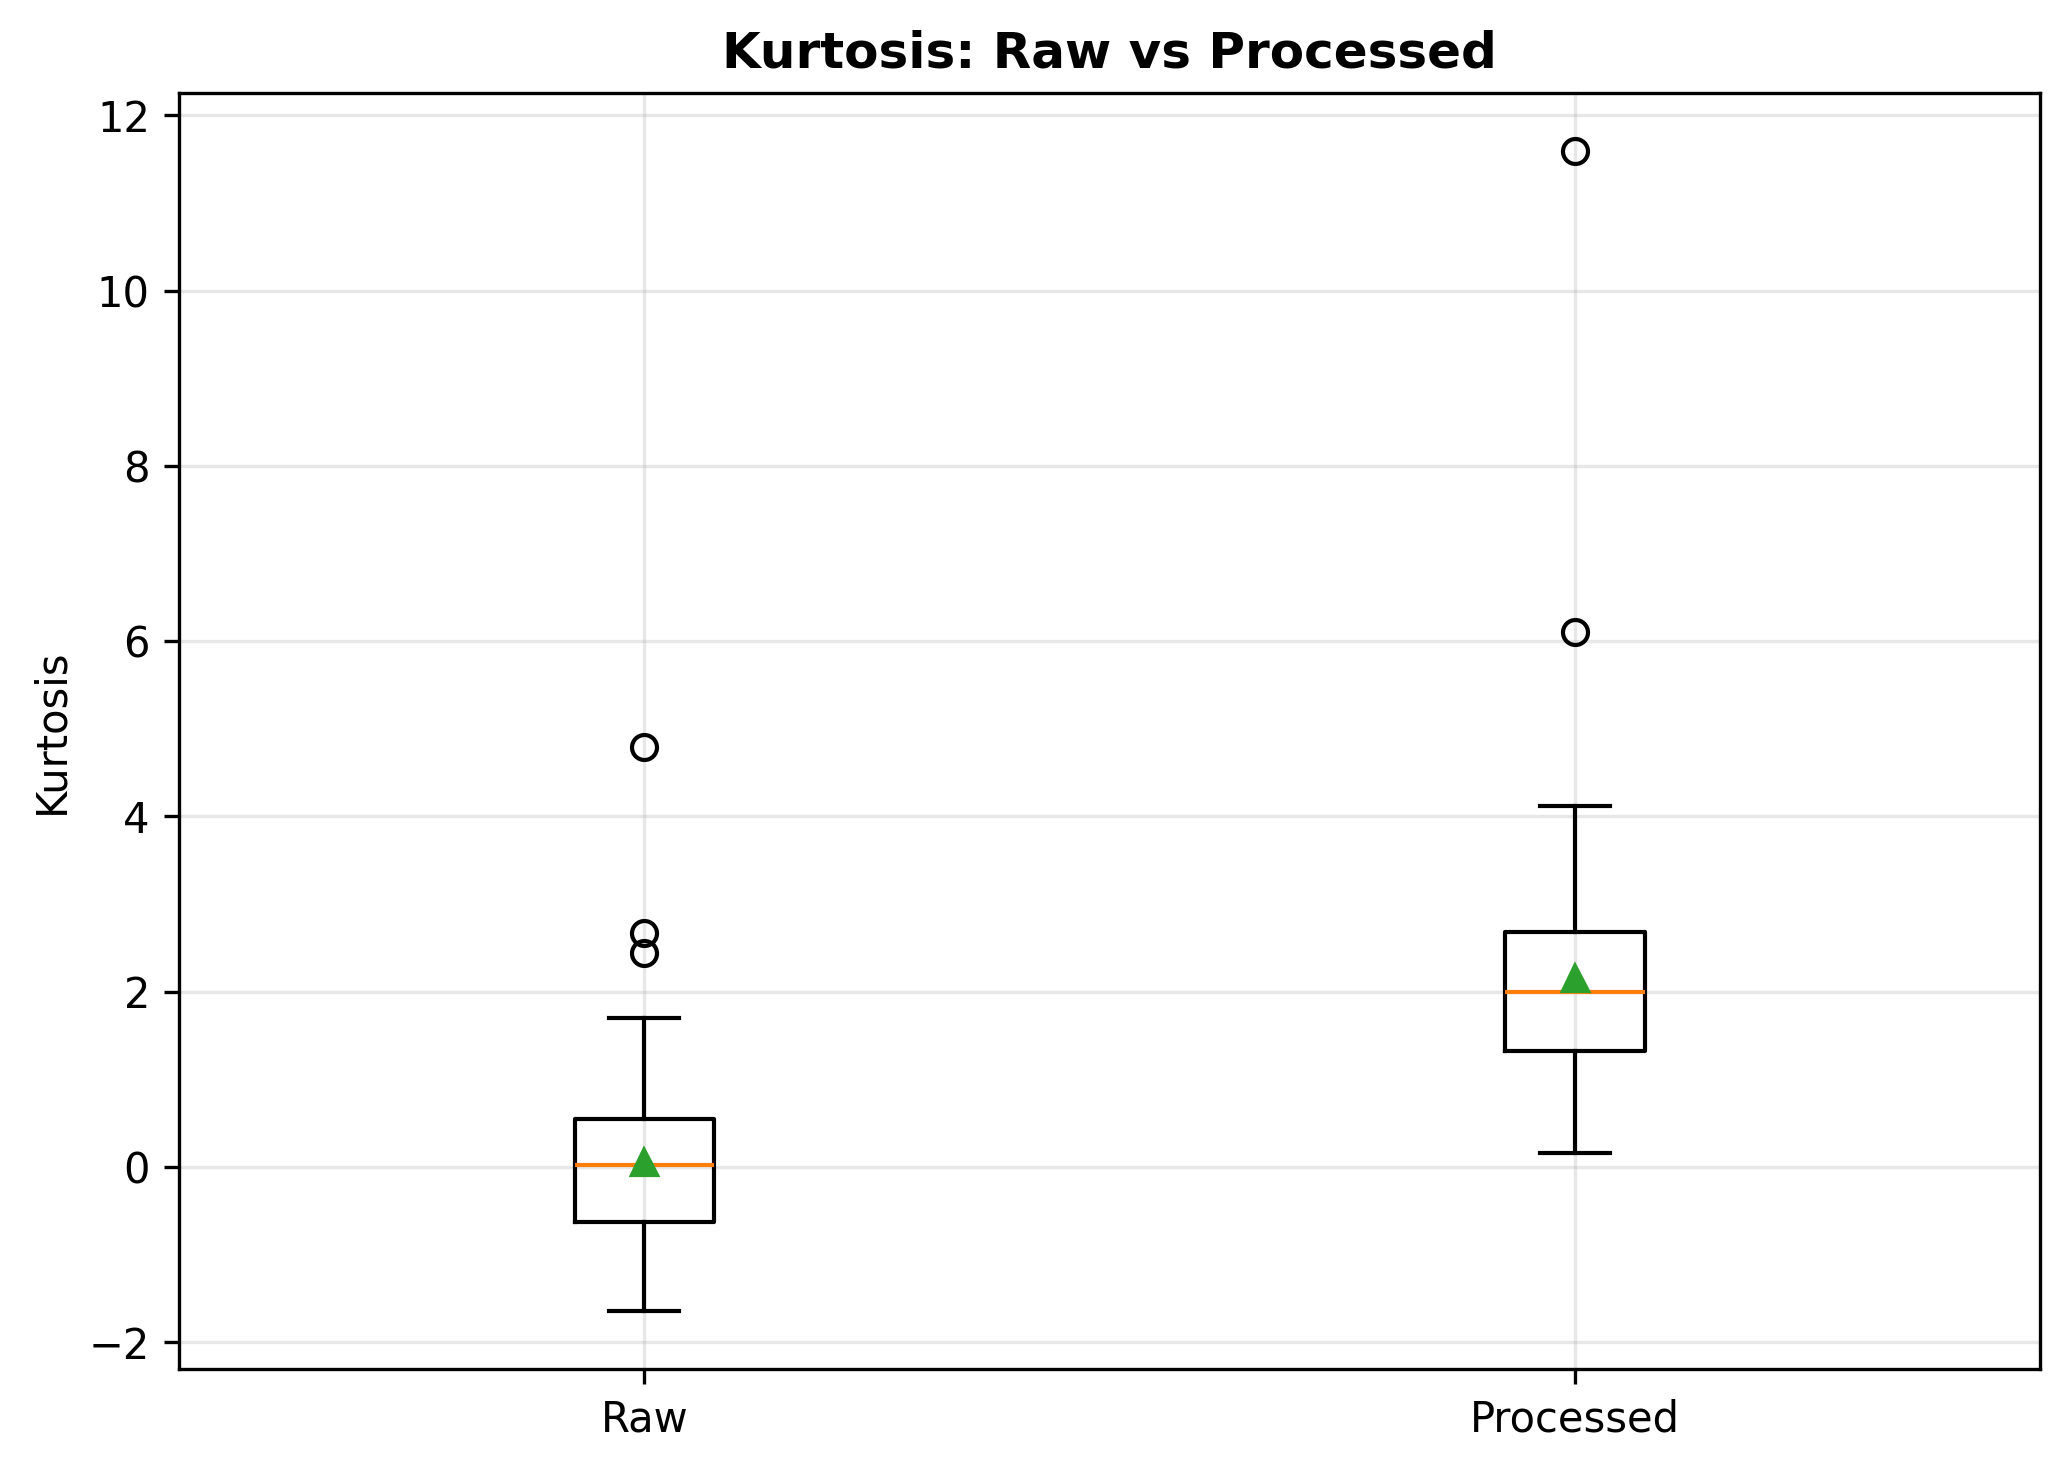

In [92]:
def guardar_boxplots_metricas(df_metricas):
    """
    Generate boxplots for Raw vs Processed signal-quality metrics.
    """
    metricas = [
        "SNR_dB",
        "PLI_ratio",
        "Baseline_ratio",
        "RMS",
        "MDF_Hz",
        "Spectral_entropy",
        "Skewness",
        "Kurtosis"
    ]

    for metrica in metricas:

        data_raw = df_metricas[df_metricas["Stage"] == "Raw"][metrica].dropna()
        data_processed = df_metricas[df_metricas["Stage"] == "Processed"][metrica].dropna()

        fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

        ax.boxplot(
            [data_raw, data_processed],
            tick_labels=["Raw", "Processed"],
            showmeans=True
        )

        ax.set_title(
            f"{metrica}: Raw vs Processed",
            fontsize=12,
            fontweight="bold"
        )
        ax.set_ylabel(metrica)
        ax.grid(True, alpha=0.3)

        plt.tight_layout()

        nombre_base = f"boxplot_{metrica}_raw_vs_processed"

        guardar_figura(fig, nombre_base)

        plt.show()


guardar_boxplots_metricas(df_metricas)

## 22. Processing parameter export

This file documents the main parameters used in the reproducible workflow.

In [ ]:
parametros = {
    "dataset_path_author_local": str(RUTA_DATASET_RAW),
    "sampling_frequency_Hz": FS,
    "recording_duration_s": RECORDING_DURATION_S,
    "window_duration_s": WINDOW_DURATION_S,
    "samples_per_window": SAMPLES_PER_WINDOW,
    "excluded_window": "V001, 0–20 s",
    "valid_windows": "V002 = 20–40 s; V003 = 40–60 s",
    "channels": CHANNELS,
    "notch_frequency_Hz": NOTCH_FREQ,
    "notch_Q": NOTCH_Q,
    "bandpass_low_Hz": BANDPASS_LOW,
    "bandpass_high_Hz": BANDPASS_HIGH,
    "bandpass_order": BANDPASS_ORDER,
    "filtering_method": "zero-phase filtfilt",
    "welch_nperseg": WELCH_NPERSEG,
    "envelope_method": "NeuroKit2 EMG_Amplitude + Savitzky–Golay smoothing",
    "savgol_window_s": SAVGOL_WINDOW_S,
    "savgol_window_samples": int(SAVGOL_WINDOW_S * FS),
    "savgol_polyorder": SAVGOL_POLYORDER,
    "statistical_test": "Wilcoxon signed-rank",
    "effect_size": "Rank-biserial correlation",
    "correlation_method": "Spearman correlation",
    "significance_level": ALPHA
}

df_parametros = pd.DataFrame(
    [{"Parameter": k, "Value": str(v)} for k, v in parametros.items()]
)

display(df_parametros)

df_parametros.to_csv(
    RUTA_TABLES / "processing_parameters.csv",
    index=False
)

## 23. Output summary

This final section prints the generated table files and figure files.

In [93]:
print("Processing finished.")

print("\nOutput folders:")
print("Figures:", RUTA_FIGURES.resolve())
print("Tables:", RUTA_TABLES.resolve())

print("\nGenerated table files:")
for archivo in sorted(RUTA_TABLES.glob("*.csv")):
    print(" -", archivo.name)

print("\nGenerated figure files:")
for archivo in sorted(RUTA_FIGURES.glob("*")):
    print(" -", archivo.name)

Processing finished.

Output folders:
Figures: C:\Users\david\curso_python\Lester_proyecto\outputs_repository\figures
Tables: C:\Users\david\curso_python\Lester_proyecto\outputs_repository\tables

Generated table files:
 - bcc_bcl_spearman_correlation_V002_V003.csv
 - dataset_file_summary.csv
 - paired_statistical_analysis_raw_vs_processed_V002_V003.csv
 - signal_quality_metrics_raw_vs_processed_V002_V003.csv
 - table_2_for_manuscript.csv

Generated figure files:
 - boxplot_Baseline_ratio_raw_vs_processed.jpg
 - boxplot_Baseline_ratio_raw_vs_processed.svg
 - boxplot_Baseline_ratio_raw_vs_processed.tiff
 - boxplot_Kurtosis_raw_vs_processed.jpg
 - boxplot_Kurtosis_raw_vs_processed.svg
 - boxplot_Kurtosis_raw_vs_processed.tiff
 - boxplot_MDF_Hz_raw_vs_processed.jpg
 - boxplot_MDF_Hz_raw_vs_processed.svg
 - boxplot_MDF_Hz_raw_vs_processed.tiff
 - boxplot_PLI_ratio_raw_vs_processed.jpg
 - boxplot_PLI_ratio_raw_vs_processed.svg
 - boxplot_PLI_ratio_raw_vs_processed.tiff
 - boxplot_RMS_raw_vs